# Export Endothelium fragment files to test ChromBPNet

In [1]:
# Allantois below

In [1]:
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(parallel))



                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
here::i_am("atac/archR/bigwig/create_1bp_bigwigs.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [3]:
ArchRProject = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [4]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/atac/chrombpnet"

In [5]:
outdir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet/'
dir.create(outdir, recursive = T)

Warning message in dir.create(outdir, recursive = T):
“'/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet' already exists”


In [6]:
meta = as.data.table(ArchRProject@cellColData, keep.rownames = T)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [7]:
endo_meta = meta[celltype.mapped == 'Endothelium']

In [8]:
table(endo_meta$sample)


       E7.5_rep1        E7.5_rep2        E8.0_rep1        E8.0_rep2 
               1                1              107               89 
E8.5_CRISPR_T_KO E8.5_CRISPR_T_WT        E8.5_rep1        E8.5_rep2 
              98               80              195              164 
      E8.75_rep1       E8.75_rep2 
              64               82 

In [28]:
chrs = c('chr1','chr10','chr11','chr12','chr13','chr14','chr15','chr16','chr17','chr18','chr19','chr2','chr3','chr4','chr5','chr6','chr7','chr8','chr9')
sample = c('E8.5_rep1', 'E8.5_rep2', 'E8.75_rep1', 'E8.75_rep2') 

# Export fragments of endo cells in subset of samples
mclapply(sample, function(x){
    tmp_cell = endo_meta[sample == x, rn] %>% 
        str_split('#') %>%  # get cell names without sample in front of it
        map_chr(2) 
    file = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/original/%s/atac_fragments.tsv.gz', x)
    fragment = fread(file)#,
                  #  tmpdir = '/rds/project/rds-SDzz0CATGms/users/bt392/software/tmp'))
    message('before filtering:')
    message(nrow(fragment))
    message(paste0('chrs: ', unique(fragment$chr)))
    
    fragment = fragment %>% 
        setnames(c('chr', 'start', 'end', 'cell', 'reads')) %>%
        # .[chr == 'chr1'] %>%
        .[cell %in% tmp_cell] %>% 
        .[chr %in% chrs]
    
    message('after filtering:')
    message(nrow(fragment))
    message(paste0('chrs: ', unique(fragment$chr)))
    
    fwrite(fragment, sprintf('%s/%s_endo.tsv.gz', outdir, x), sep = '\t')
}, mc.cores = 1)

Warning message in fread(file):
“Detected 1 column names but the data has 5 columns (i.e. invalid file). Added 4 extra default column names at the end.”
before filtering:

318295604

chrs: 

after filtering:

3801297

chrs: chr1chrs: chr10chrs: chr11chrs: chr12chrs: chr13chrs: chr14chrs: chr15chrs: chr16chrs: chr17chrs: chr18chrs: chr19chrs: chr2chrs: chr3chrs: chr4chrs: chr5chrs: chr6chrs: chr7chrs: chr8chrs: chr9

Warning message in fread(file):
“Detected 1 column names but the data has 5 columns (i.e. invalid file). Added 4 extra default column names at the end.”
before filtering:

286297072

chrs: 

after filtering:

3927141

chrs: chr1chrs: chr10chrs: chr11chrs: chr12chrs: chr13chrs: chr14chrs: chr15chrs: chr16chrs: chr17chrs: chr18chrs: chr19chrs: chr2chrs: chr3chrs: chr4chrs: chr5chrs: chr6chrs: chr7chrs: chr8chrs: chr9

Warning message in fread(file):
“Detected 1 column names but the data has 5 columns (i.e. invalid file). Added 4 extra default column names at the end.”
before 

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

In [170]:
tmp = lapply(sample, function(x){
    tmp_frag = fread(sprintf('%s/%s_endo.tsv.gz', outdir, x), sep = '\t')
}) %>% rbindlist() %>% 
    .[order(chr, start)]

fwrite(tmp, sprintf('%s/endo_fragments.tsv.gz', outdir), col.names = F, sep = '\t')
fwrite(tmp, sprintf('%s/endo_fragments.tsv', outdir), col.names = F, sep = '\t')

In [41]:
tmp = fread(sprintf('%s/endo_fragments.tsv.gz', outdir))

In [43]:
nrow(tmp)
unique(tmp$chr)

[1] 12423682

[1] "chr1"  "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17"
[10] "chr18" "chr19" "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8" 
[19] "chr9"

In [162]:
peaks = as.data.table(
    readRDS(
        '../../../data/processed/atac/archR/PeakCalls/Endothelium-reproduciblePeaks.gr.rds'
        )
    ) %>%
    .[, middle := start + (end - start) / 2] %>%
    .[,`:=`(start = middle - 1057, 
            end = middle + 1057,
            column4 = '.',
            column5 = '.',
            column6 = '.',
            column7 = '.',
            column8 = '.',
            column9 = '.',
            column10 = 1057)] %>% 
    .[,.(seqnames, 
         start, 
         end, 
         column4,
         column5,
         column6,
         column7,
         column8,
         column9,
         column10)] %>%
    .[seqnames != 'chrX']


head(peaks)

seqnames,start,end,column4,column5,column6,column7,column8,column9,column10
<fct>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
chr1,60179460,60181574,.,.,.,.,.,.,1057
chr1,75316443,75318557,.,.,.,.,.,.,1057
chr1,89069248,89071362,.,.,.,.,.,.,1057
chr1,165460065,165462179,.,.,.,.,.,.,1057
chr1,177795595,177797709,.,.,.,.,.,.,1057
chr2,154435270,154437384,.,.,.,.,.,.,1057


In [163]:
peaks.gr = GenomicRanges::makeGRangesFromDataFrame(peaks, keep.extra.columns = T)
overlaps = GenomicRanges::findOverlaps(peaks.gr, ArchRProject@genomeAnnotation$blacklist)

peaks.gr = peaks.gr[-queryHits(overlaps)]

In [164]:
peaks = as.data.table(peaks.gr)[,`:=`(width=NULL, strand=NULL)]
fwrite(peaks, sprintf('%s/peaks.bed', outdir), col.names = F, sep = '\t')

In [165]:
nrow(peaks)
tail(peaks)

[1] 36674

seqnames,start,end,column4,column5,column6,column7,column8,column9,column10
<fct>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
chr12,100405212,100407326,.,.,.,.,.,.,1057
chr14,31639460,31641574,.,.,.,.,.,.,1057
chr15,58213516,58215630,.,.,.,.,.,.,1057
chr18,32559169,32561283,.,.,.,.,.,.,1057
chr19,3905091,3907205,.,.,.,.,.,.,1057
chr19,26851588,26853702,.,.,.,.,.,.,1057


In [166]:
chromSizes = as.data.table(ArchRProject@genomeAnnotation$chromSizes) %>%
    .[,.(seqnames, end)]
fwrite(chromSizes, sprintf('%s/mm10.chrom.sizes', outdir), col.names = F, sep = '\t')

In [167]:
fwrite(as.data.table(ArchRProject@genomeAnnotation$blacklist) %>%
           .[,.(seqnames, start, end)],
       sprintf('%s/blacklist.bed.gz', outdir), col.names = F, sep = '\t')

# Read ChromBPNet contribution files

In [542]:
# For all the top hits the explainability is precisely in the center of the peak, indicating pure overfitting if i'm interpretting it correctly
# But the ChromBPNet report looks perfect..?

# Actually it makes sense and is just because of the most determininstic factors being in the centre of the peak

In [173]:
library(rhdf5)

In [ ]:
atlasses/gastrulation_multiome/code/atac/crested/exp1/chrombpnet_filtered_2114bp/tfmodisco_results/Cardiomyocytes-TileSize-10-normMethod-ReadsInTSS-ArchR_modisco_results.h5

In [564]:
h5ls('../crested/exp1/chrombpnet_filtered_2114bp/contribution_scores/Allantois-TileSize-10-normMethod-ReadsInTSS-ArchR_oh.npz')


ERROR: Error in H5Fopen(file, flags = flags, fapl = fapl, native = native): HDF5. File accessibility. Unable to open file.


In [177]:
h5ls(sprintf("%s/chrombpnet_model/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir))


,group,name,otype,dclass,dim
,<chr>,<chr>,<chr>,<chr>,<chr>
0,/,projected_shap,H5I_GROUP,,
1,/projected_shap,seq,H5I_DATASET,FLOAT,2114 x 4 x 30000
2,/,raw,H5I_GROUP,,
3,/raw,seq,H5I_DATASET,INTEGER,2114 x 4 x 30000
4,/,shap,H5I_GROUP,,
5,/shap,seq,H5I_DATASET,FLOAT,2114 x 4 x 30000


In [179]:
mydata <- h5read(sprintf("%s/chrombpnet_model/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir), "/projected_shap/seq")


ERROR: Error in H5Lexists(loc$H5Identifier, name): HDF5. Links. Can't get value.


In [181]:
str(mydata)

 num [1:2114, 1:4, 1:30000] 0 0 0 0 0 0 0 0 0 0 ...


In [190]:
mydata <- h5read(sprintf("%s/chrombpnet_model/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir), "/raw/seq")


In [198]:
genome = data.table(A = test[1:2114],
           T = test[2115:2114+2114],
           C =  test[2114+2114+1:2114+2114+2114],
           G =  test[2114+2114+2114+1:2114+2114+2114+2114]
           )

In [7]:
mydata <- h5read(sprintf("%s/chrombpnet_model/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir), "/projected_shap/seq")


In [8]:
row = 10
test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]
2114 * (row*4) + 1 
2114 * (row * 4) + 2114*4

[1] 84561

[1] 93016

In [9]:
min(test)

[1] -0.01100159

In [10]:
max(test)

[1] 0.01695251

In [11]:
boom = mclapply(1:30000, function(x){
    test = mydata[(2114 * (x*4) + 1 ): (2114 * (x * 4) + 2114*4)]
    tmp = data.table(row = x,
                     max = mean(test))
                     
    return(tmp)
}, mc.cores = 24) %>% rbindlist() %>%
    .[order(-max)]
    
    

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Removed 1 rows containing non-finite values (`stat_bin()`).”


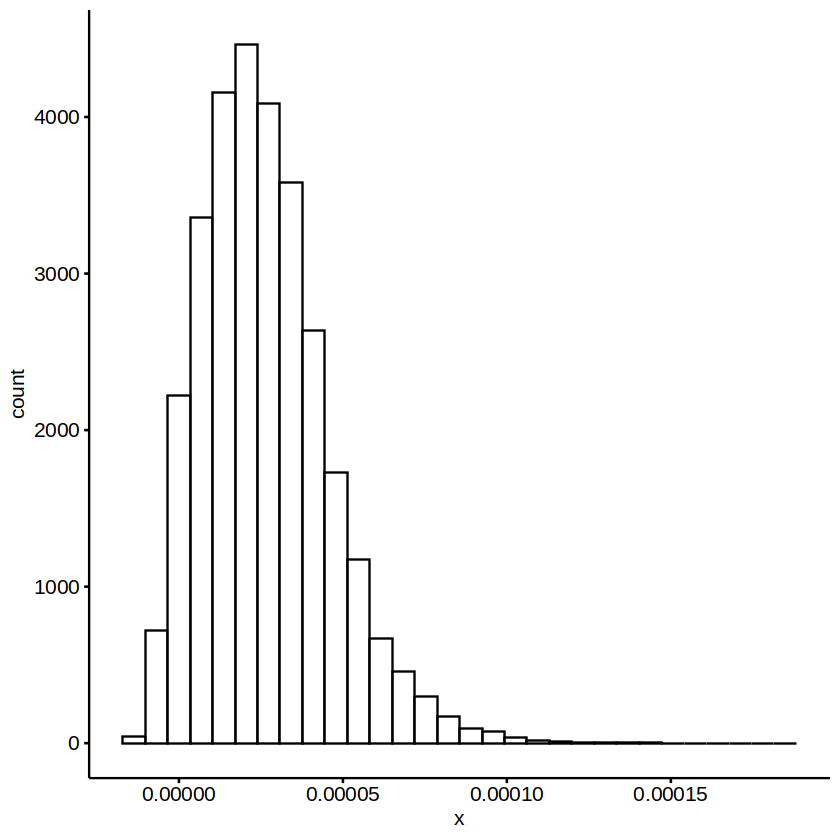

In [12]:
gghistogram(boom$max)

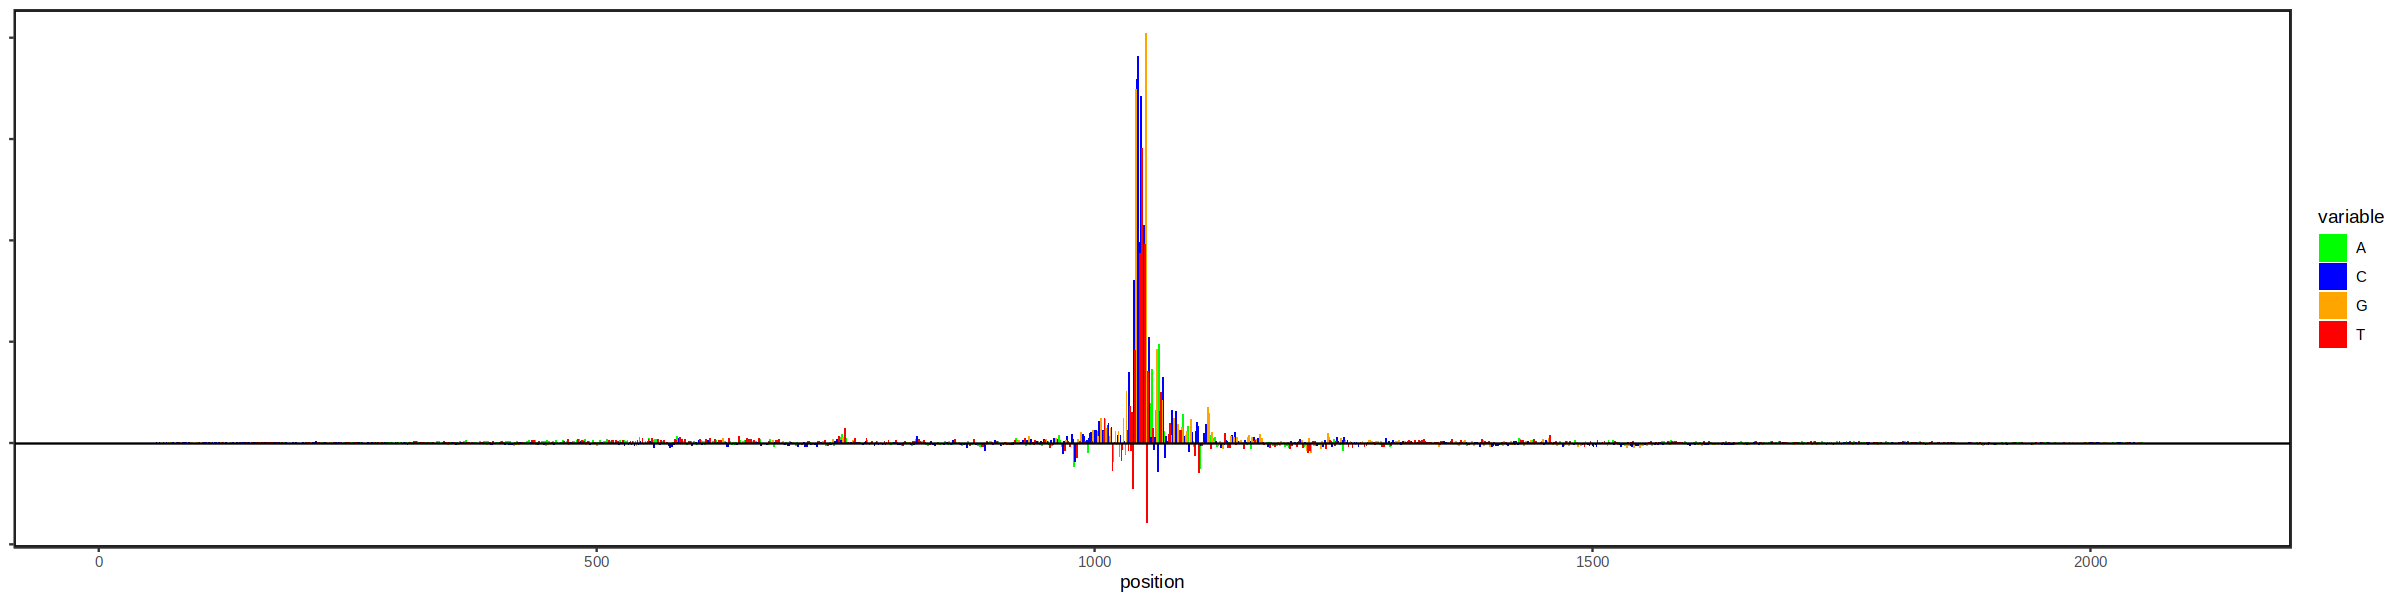

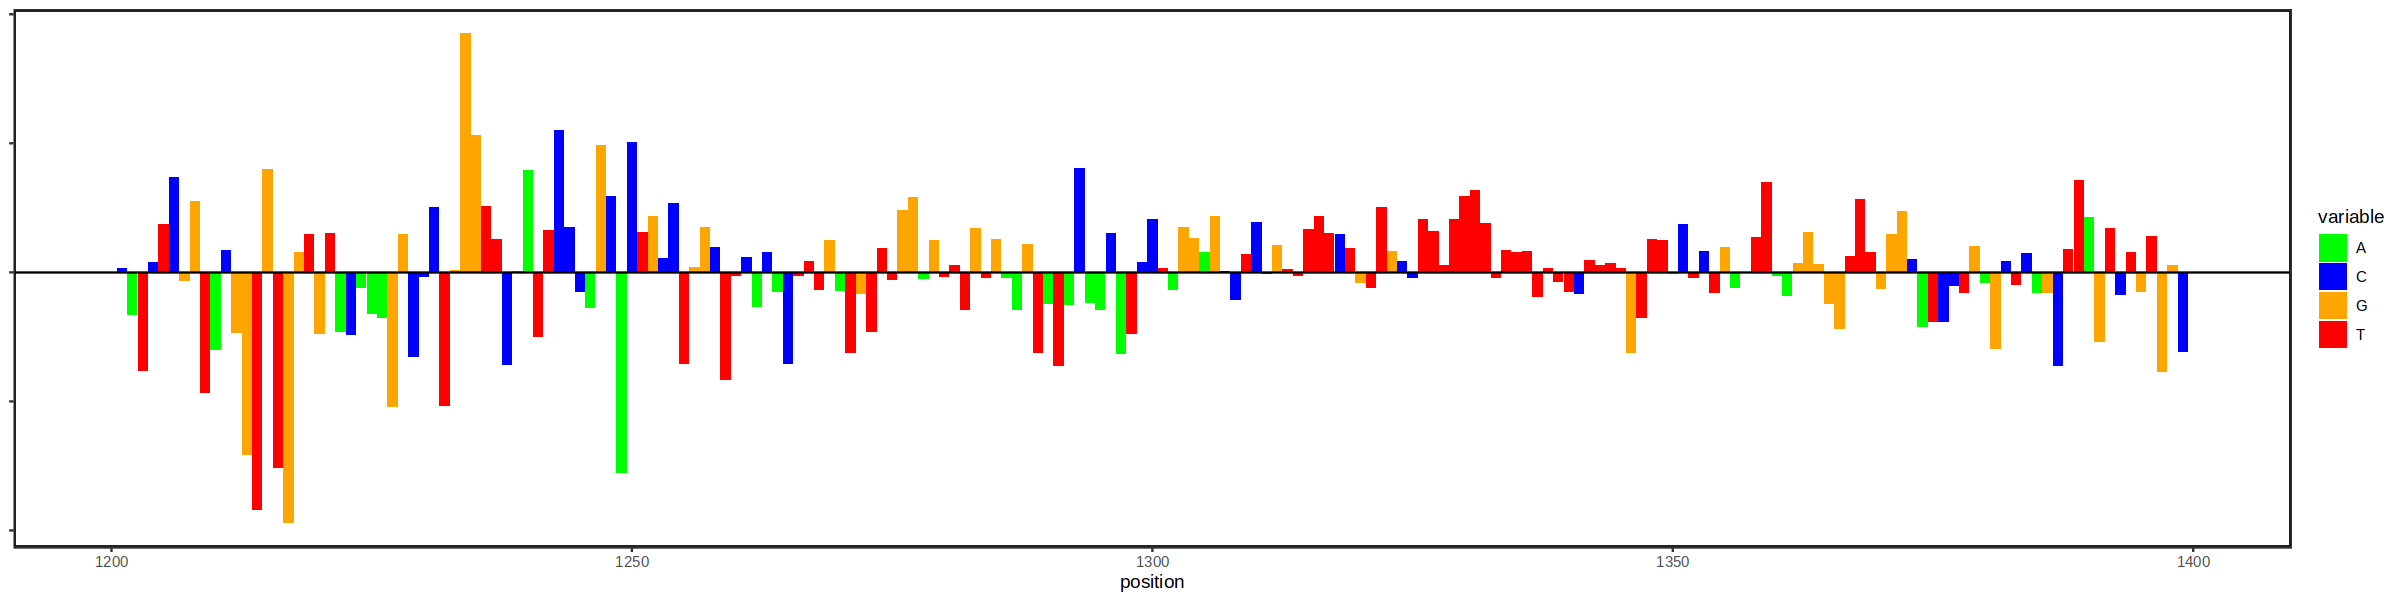

In [83]:
row = boom[18,]$row
test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]

genome = data.table(A = test[1:2114],
           C = test[2115:4228],
           G =  test[4229:6342],
           T =  test[6343:8456]
           ) %>%
    .[, position := .I] %>%
    melt(., id.vars = 'position') %>% 
    .[abs(value) > 0]

options(repr.plot.width = 20, repr.plot.height = 5)
ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_blank(),
         axis.title.y = element_blank())
options(repr.plot.width = 20, repr.plot.height = 5)
# genome = genome[position > 950 & position < 1150]
genome = genome[position > 1200 & position < 1400]

ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_blank(),
         axis.title.y = element_blank())

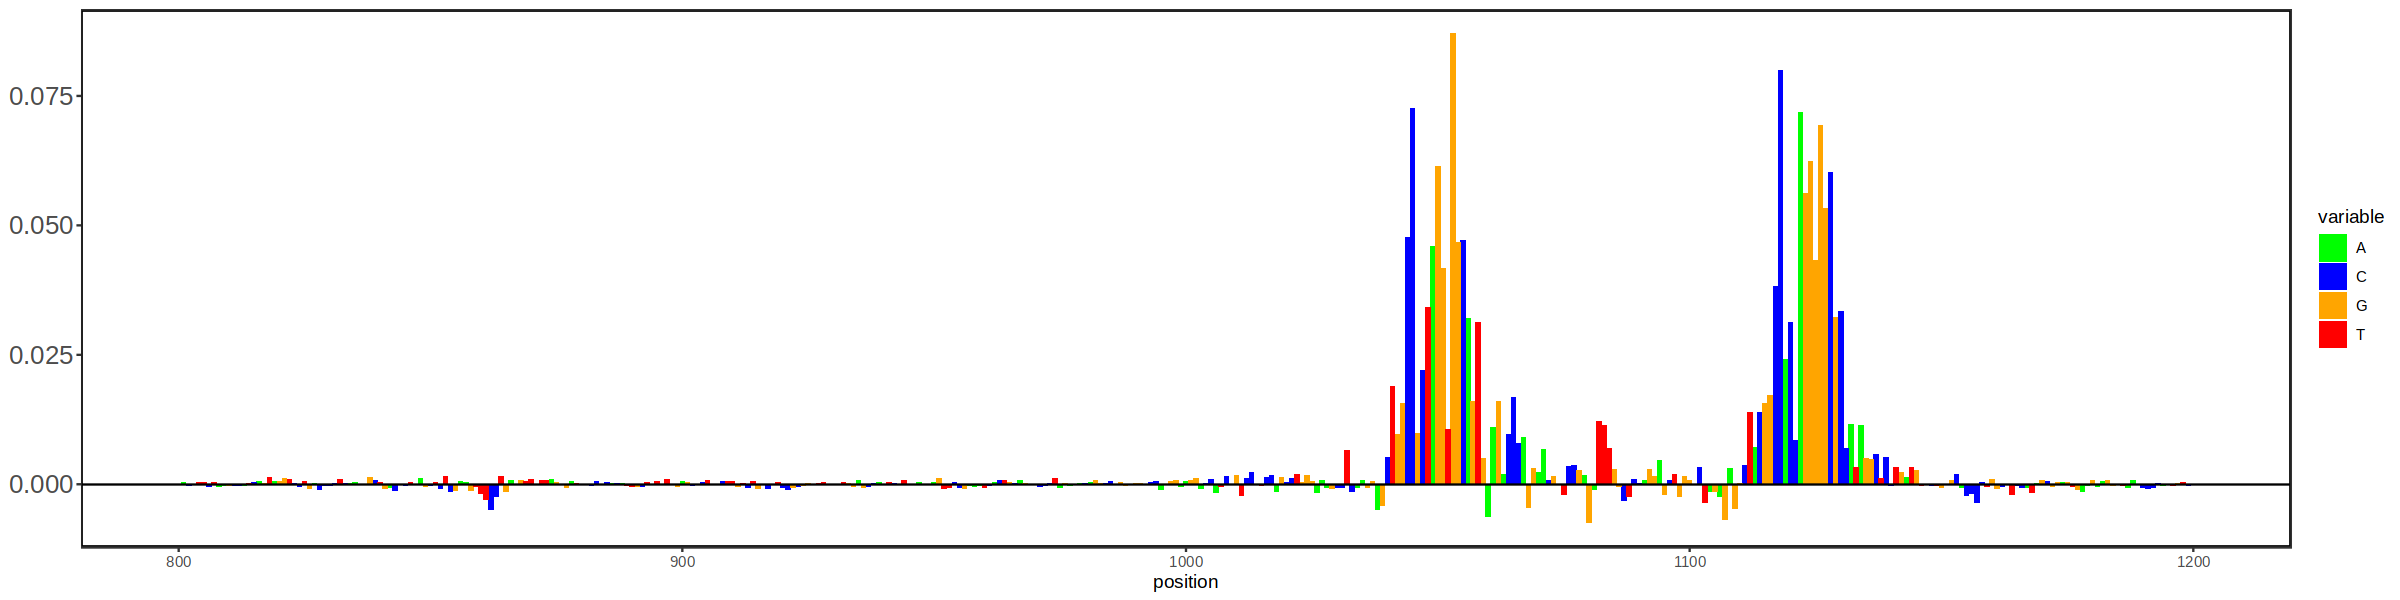

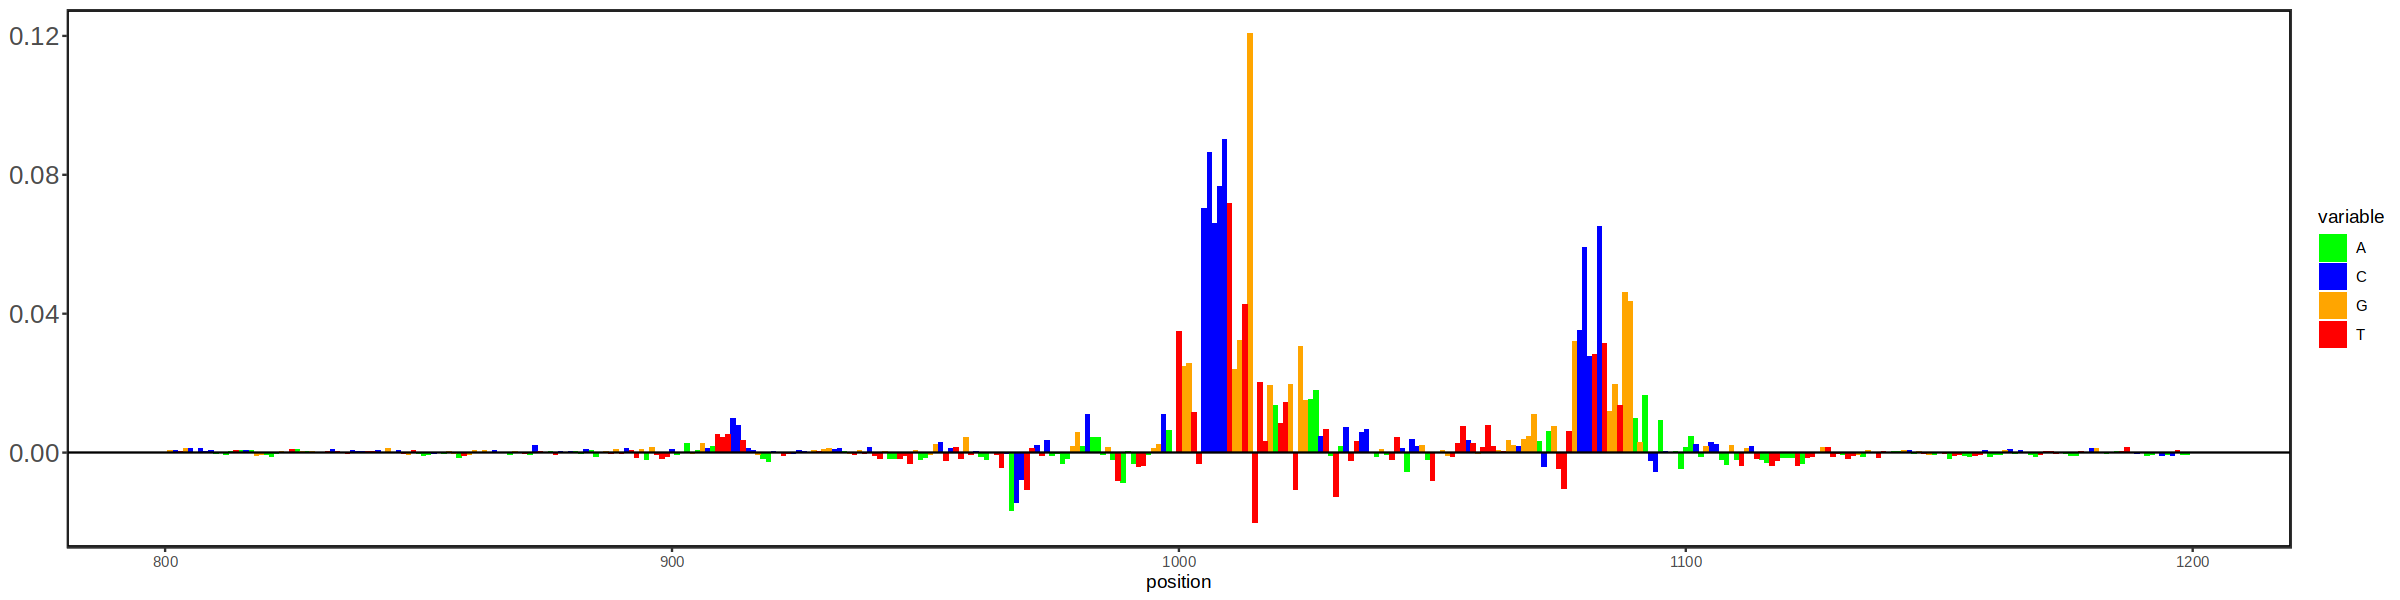

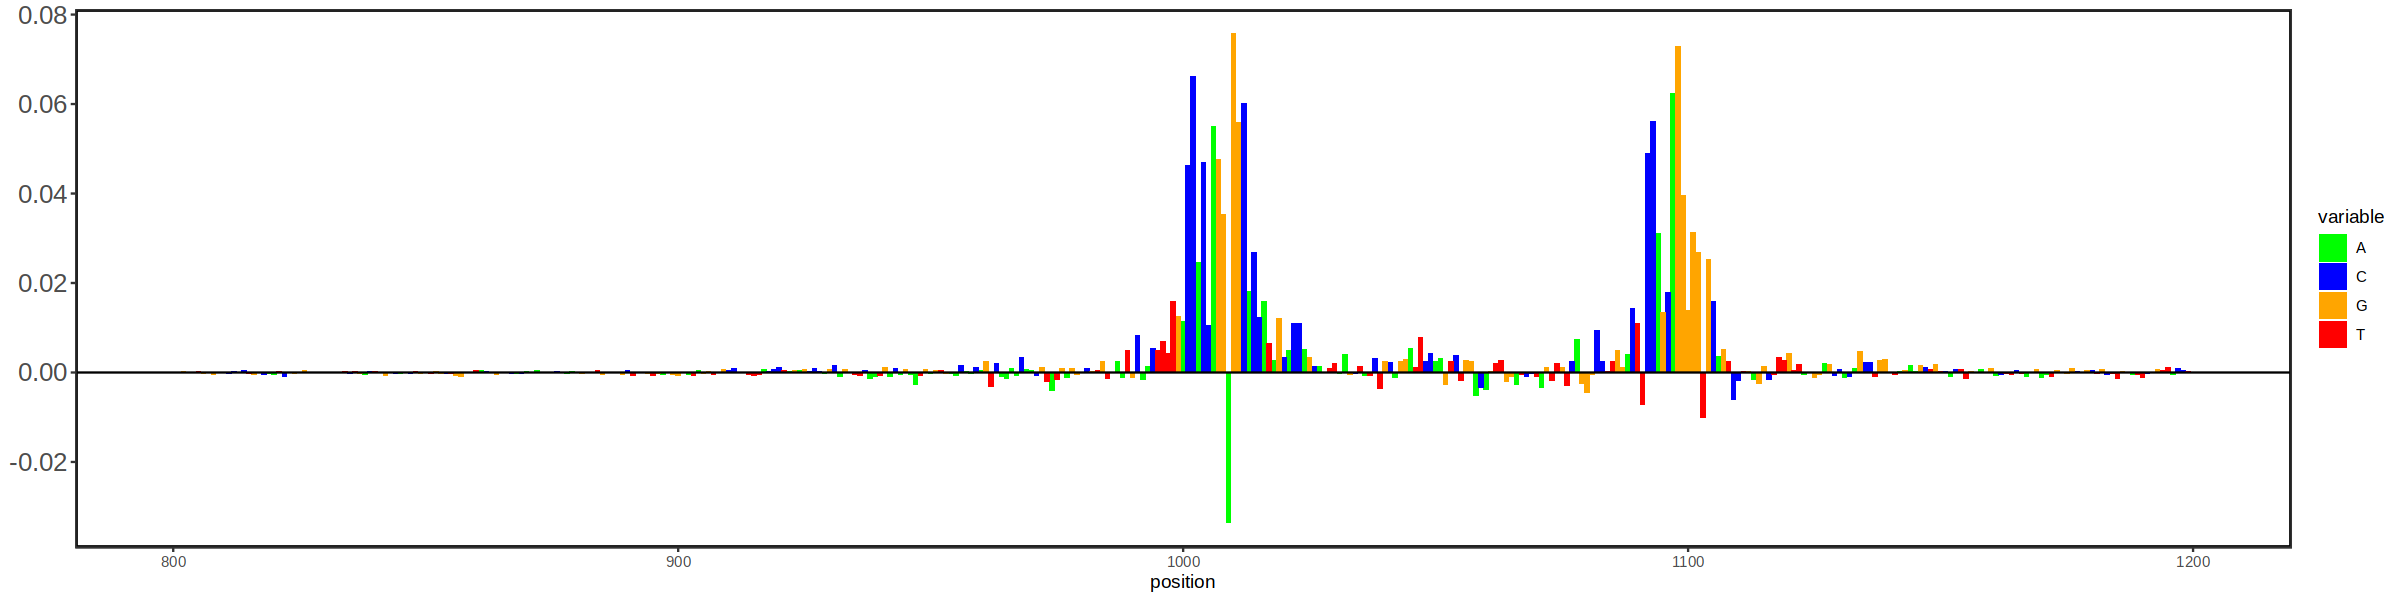

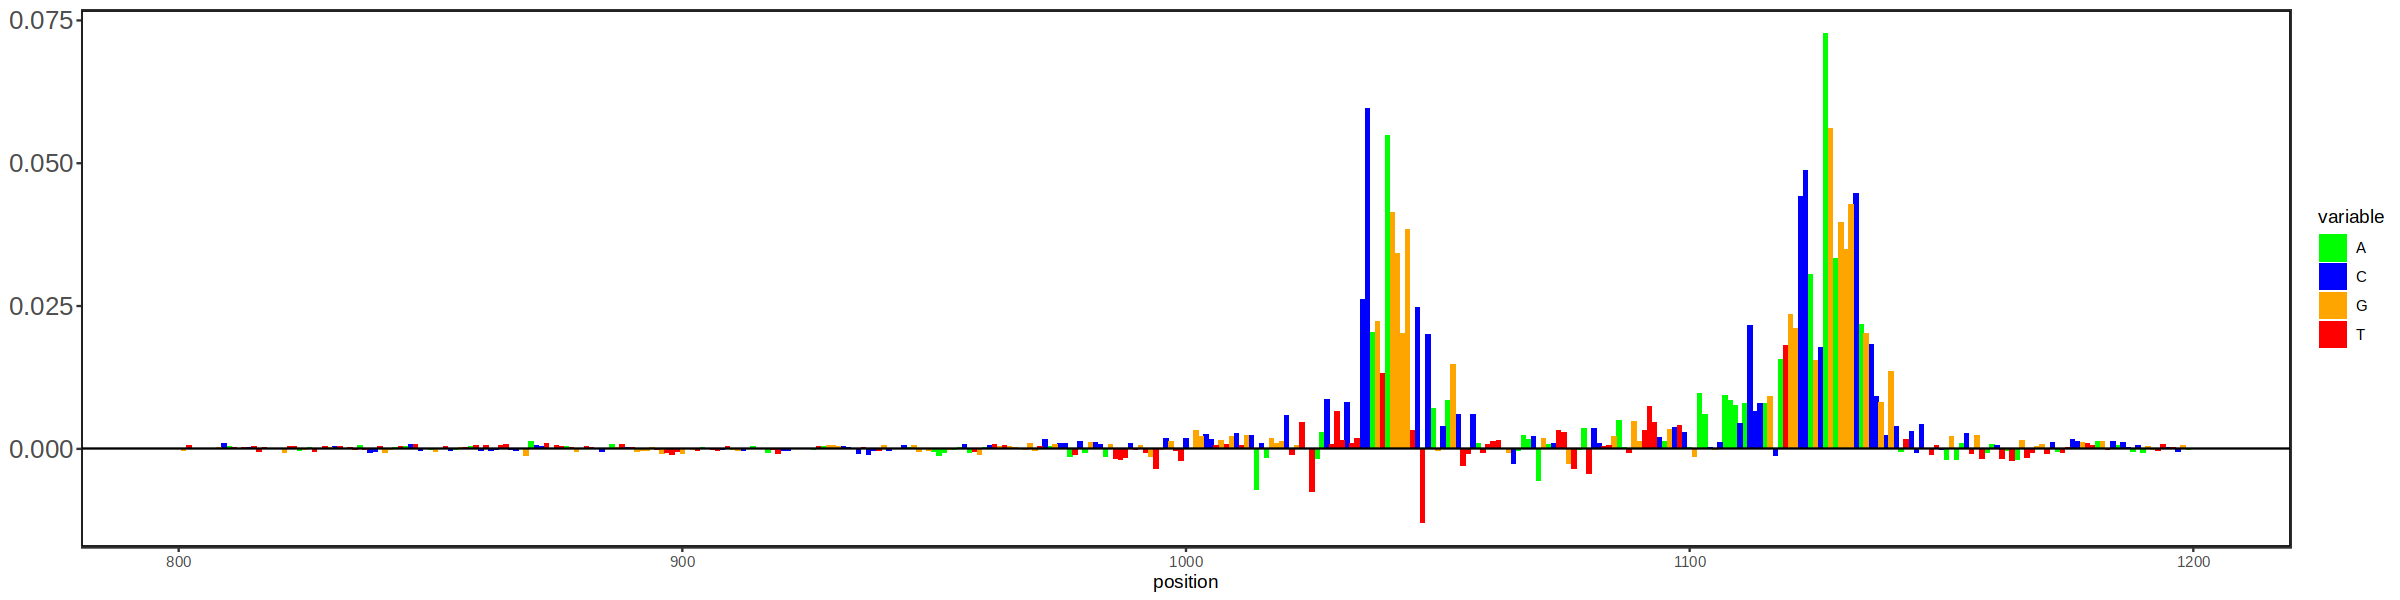

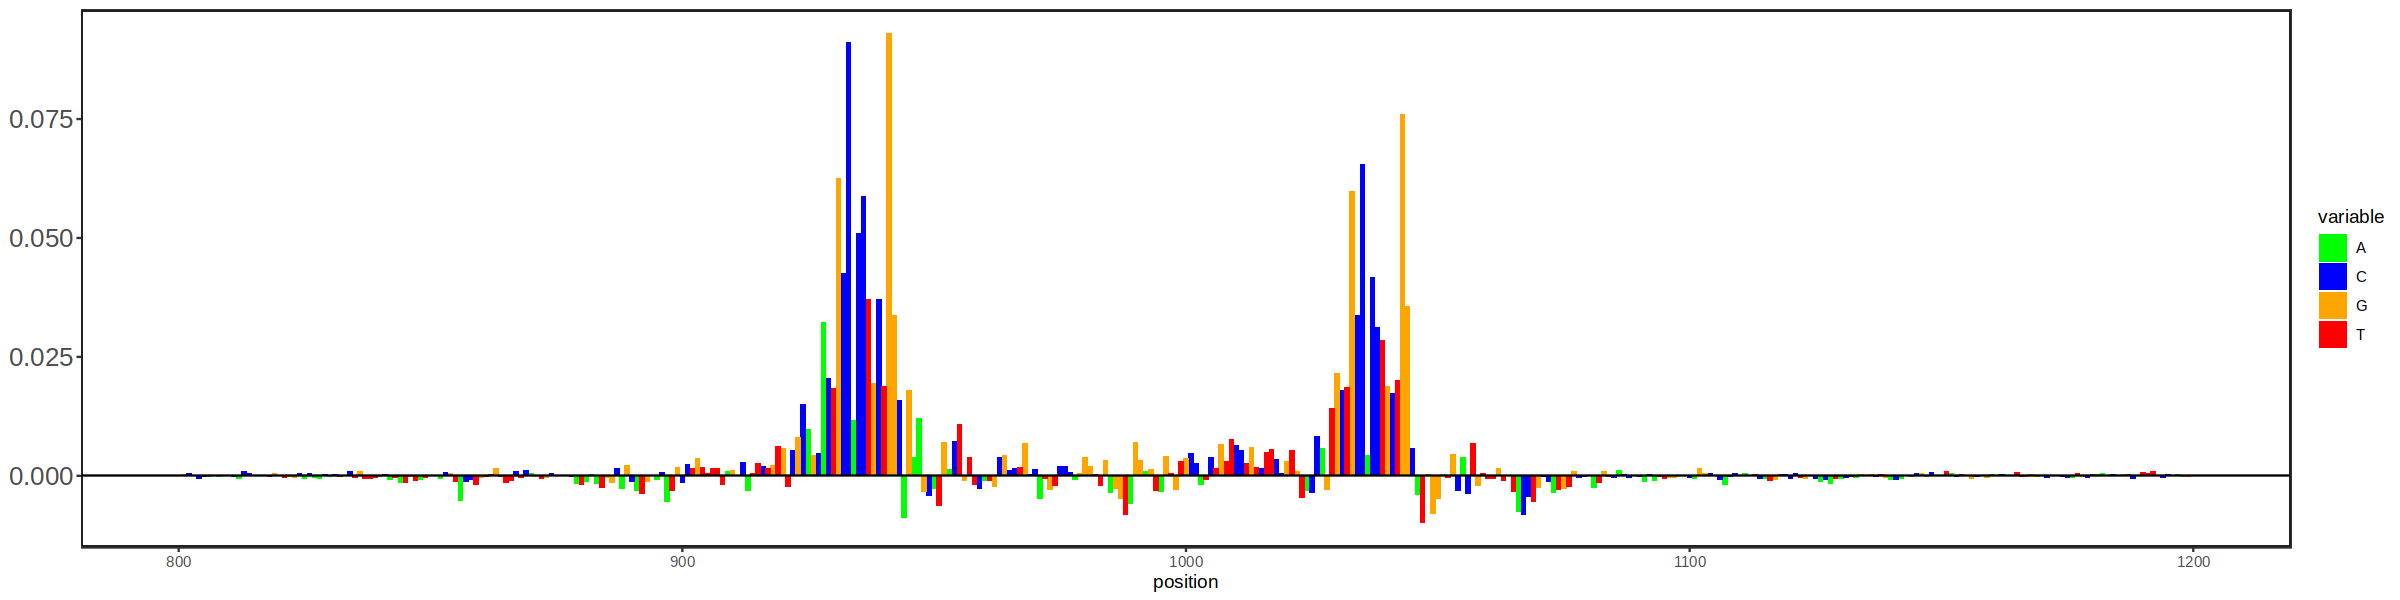

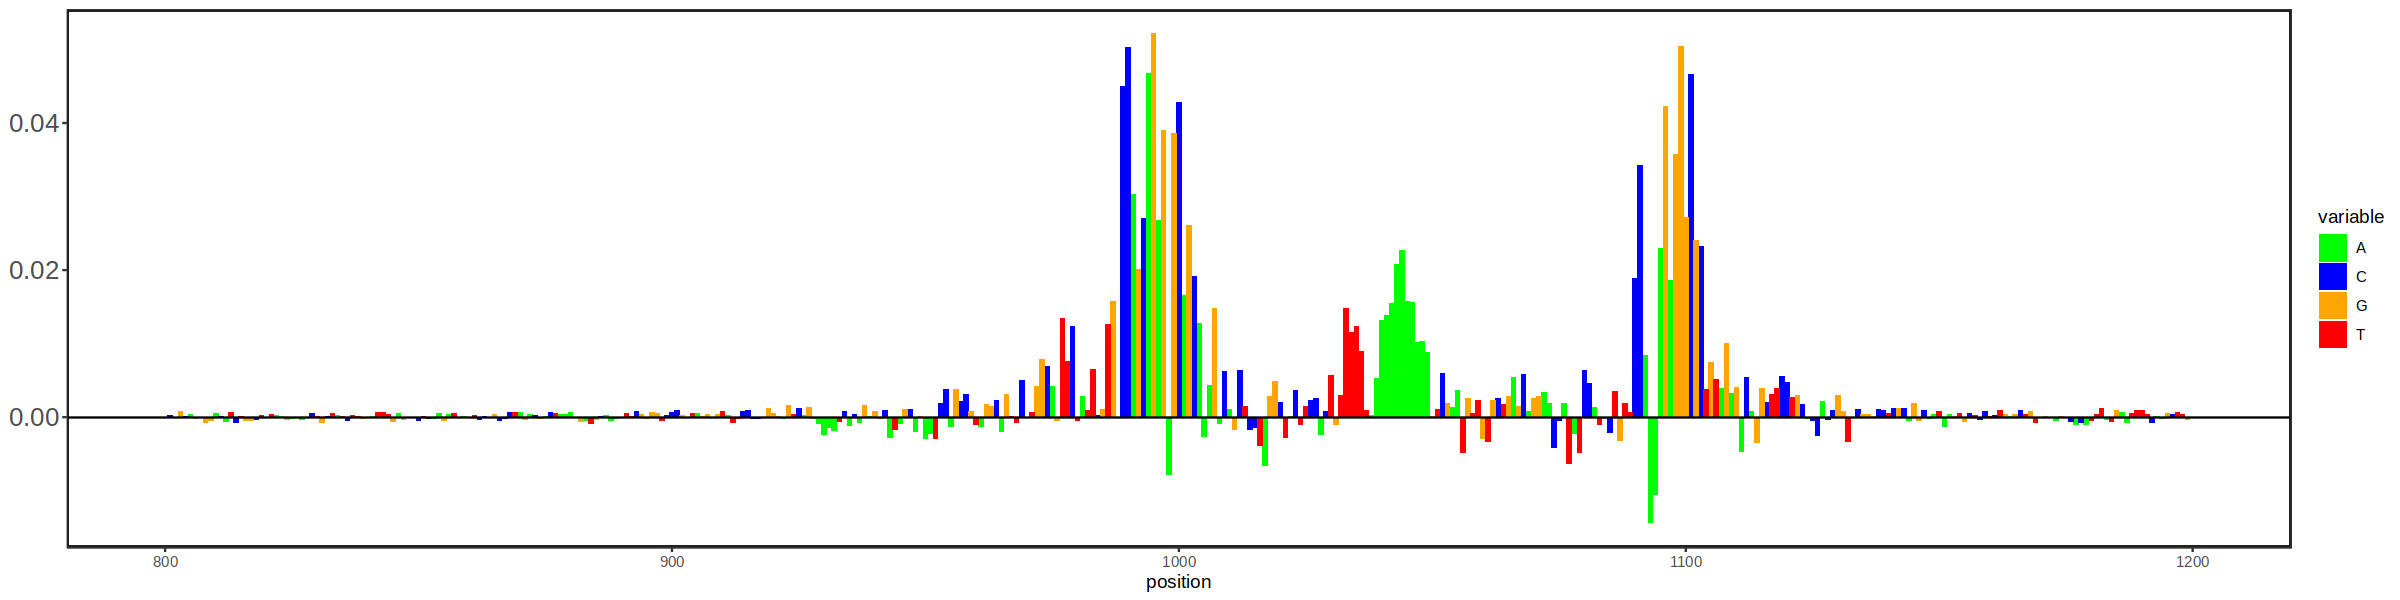

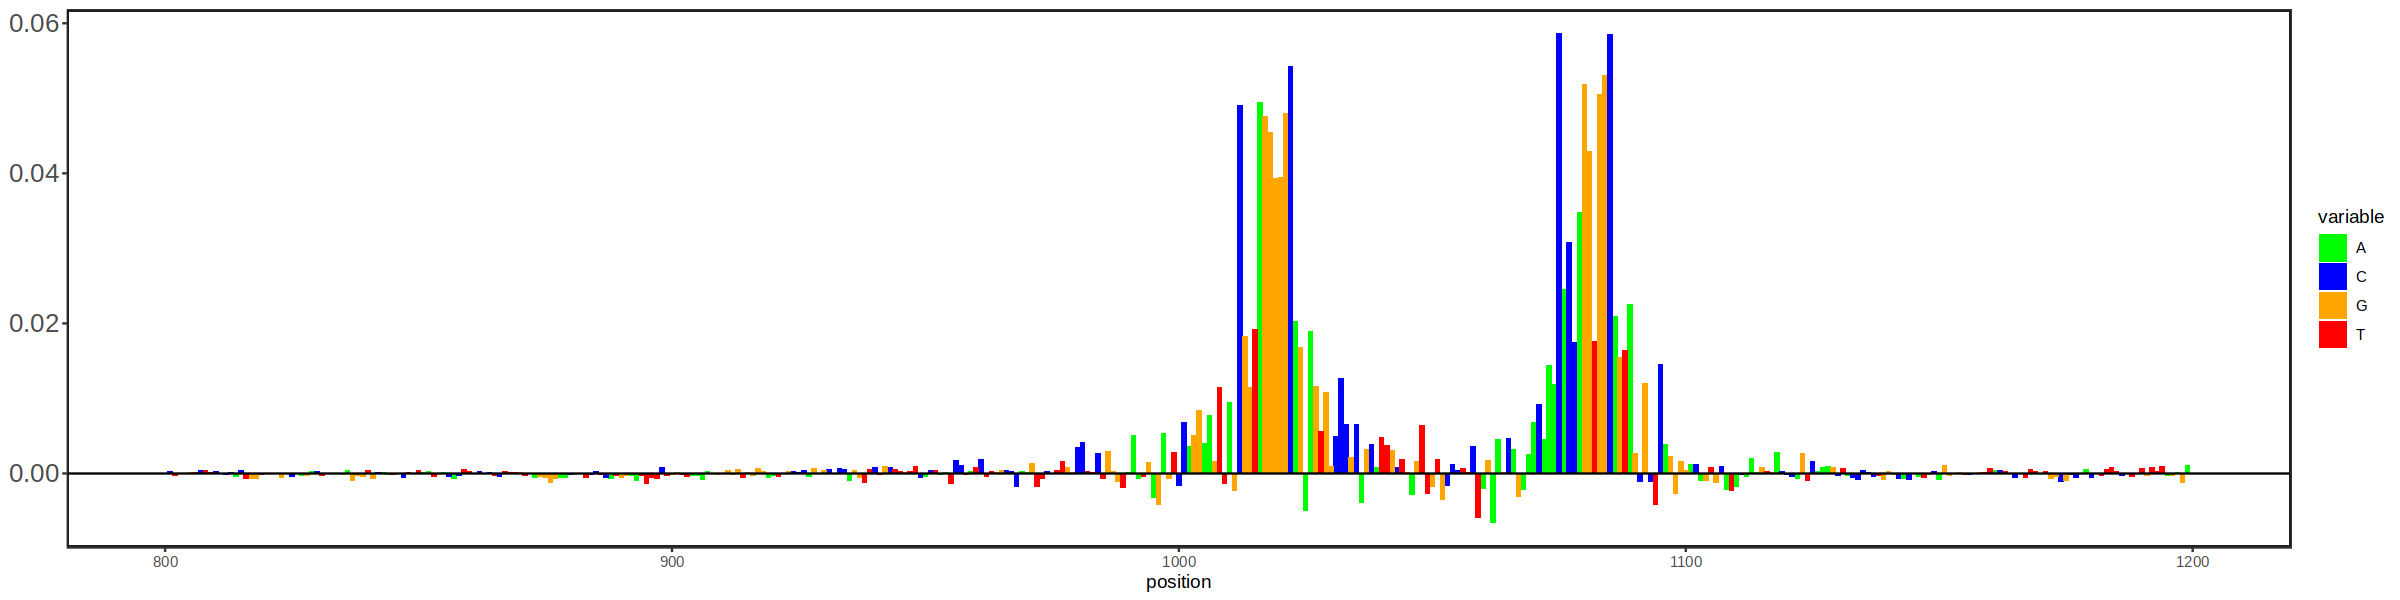

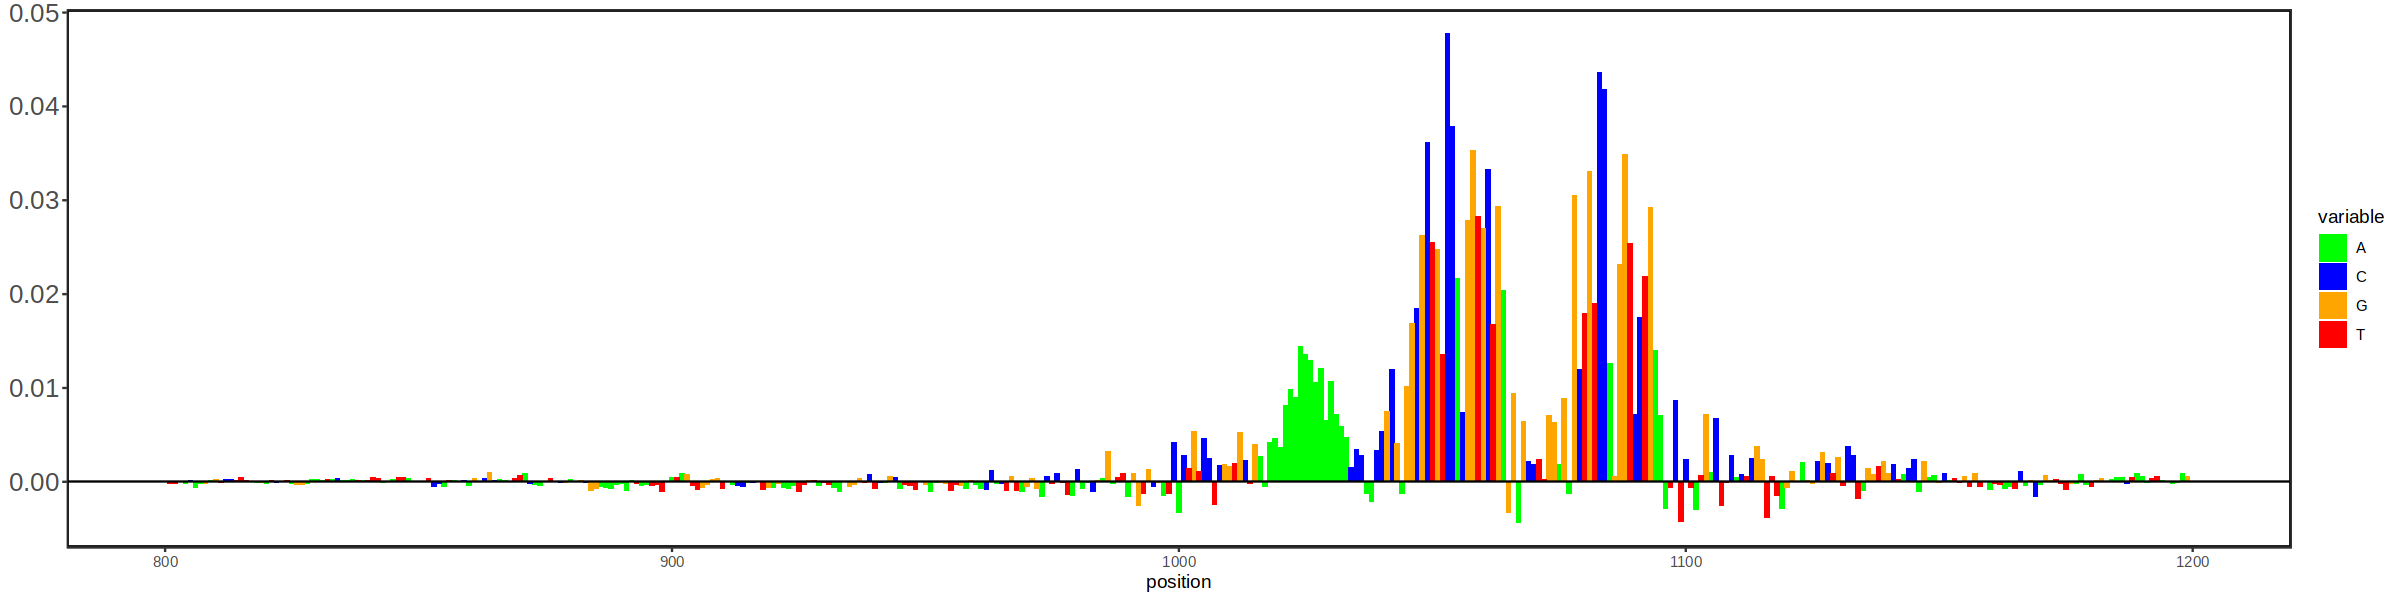

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]


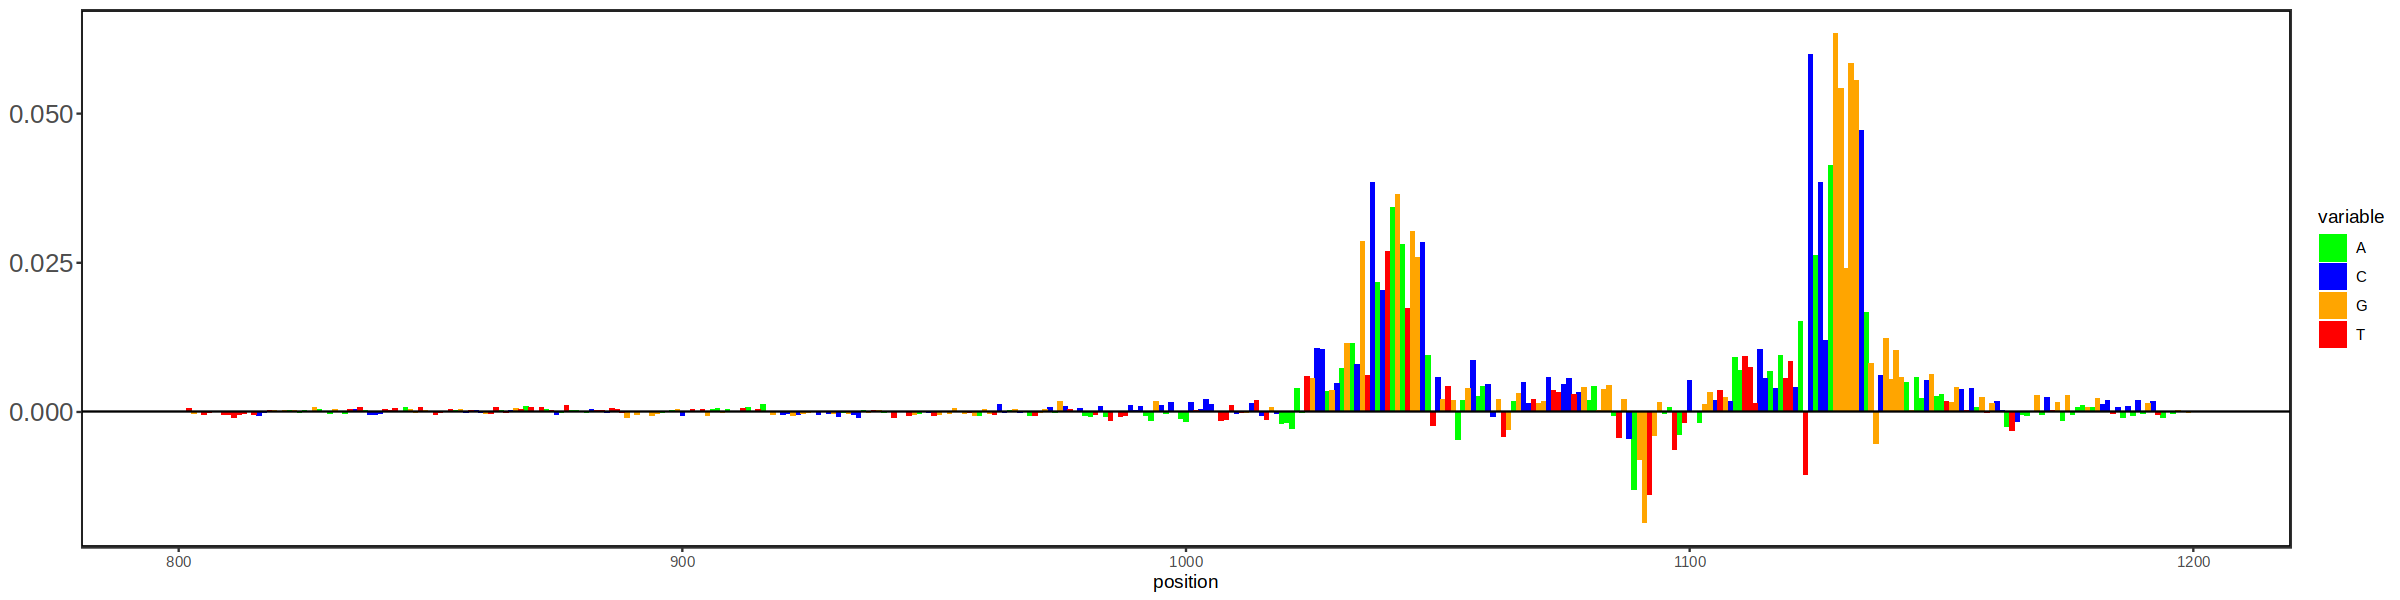

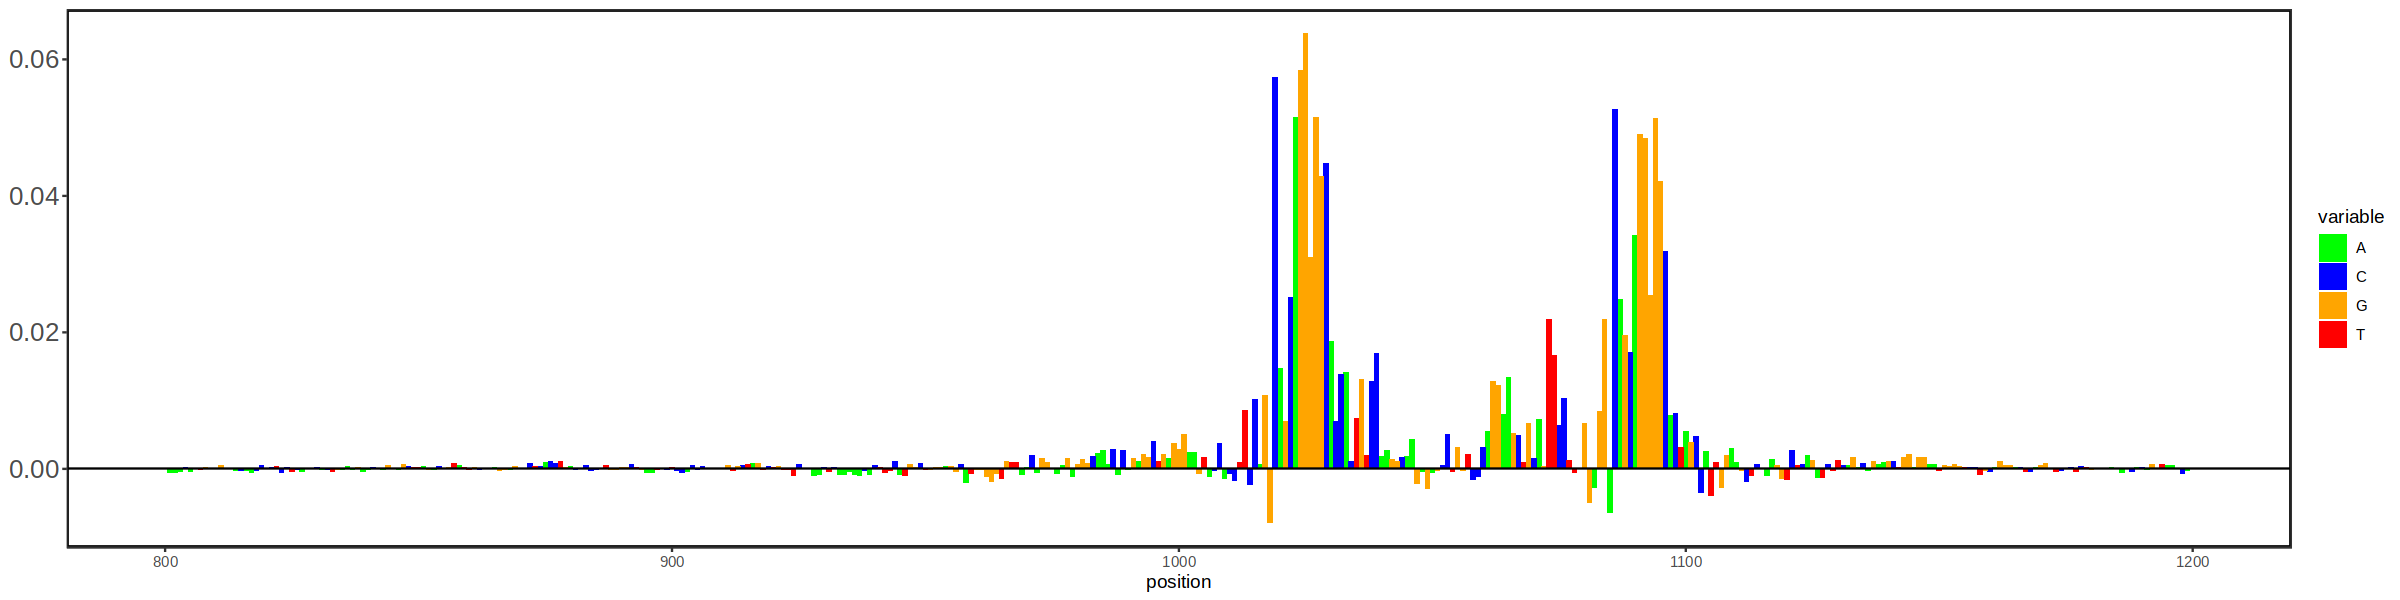

In [13]:
lapply(1:10, function(x){
row = boom[x,]$row

    test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]

    
genome = data.table(A = test[1:2114],
           C = test[2115:4228],
           G =  test[4229:6342],
           T =  test[6343:8456]
           ) %>%
    .[, position := .I] %>%
    melt(., id.vars = 'position') %>% 
    .[abs(value) > 0]

options(repr.plot.width = 20, repr.plot.height = 5)
genome = genome[position > 800 & position < 1200]
ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_text(size = 15),
         axis.title.y = element_blank())
})

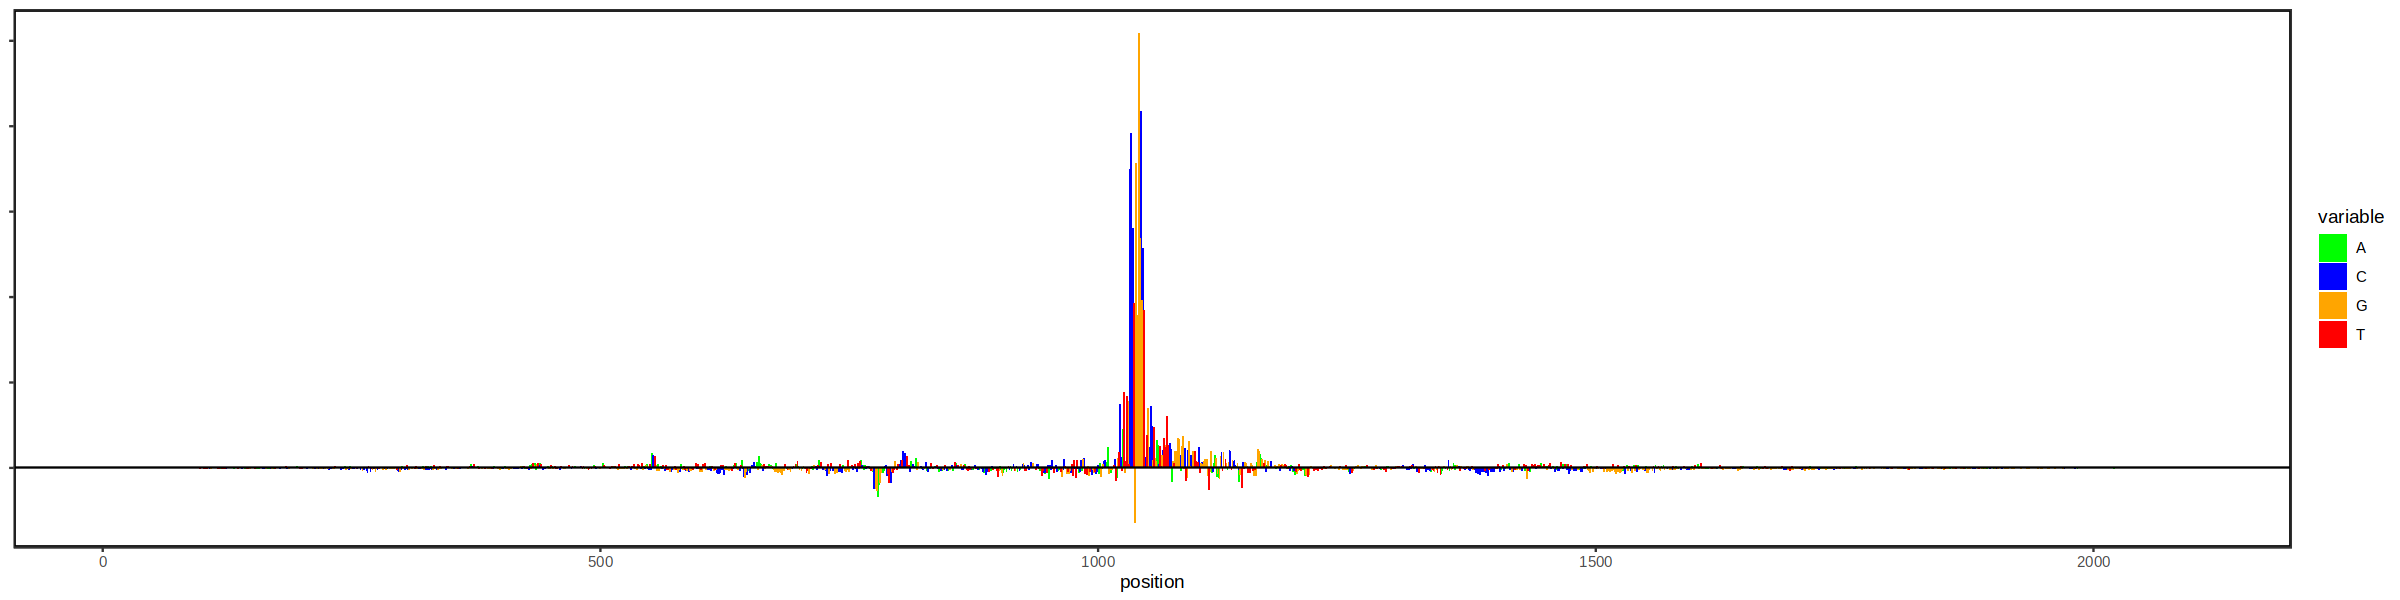

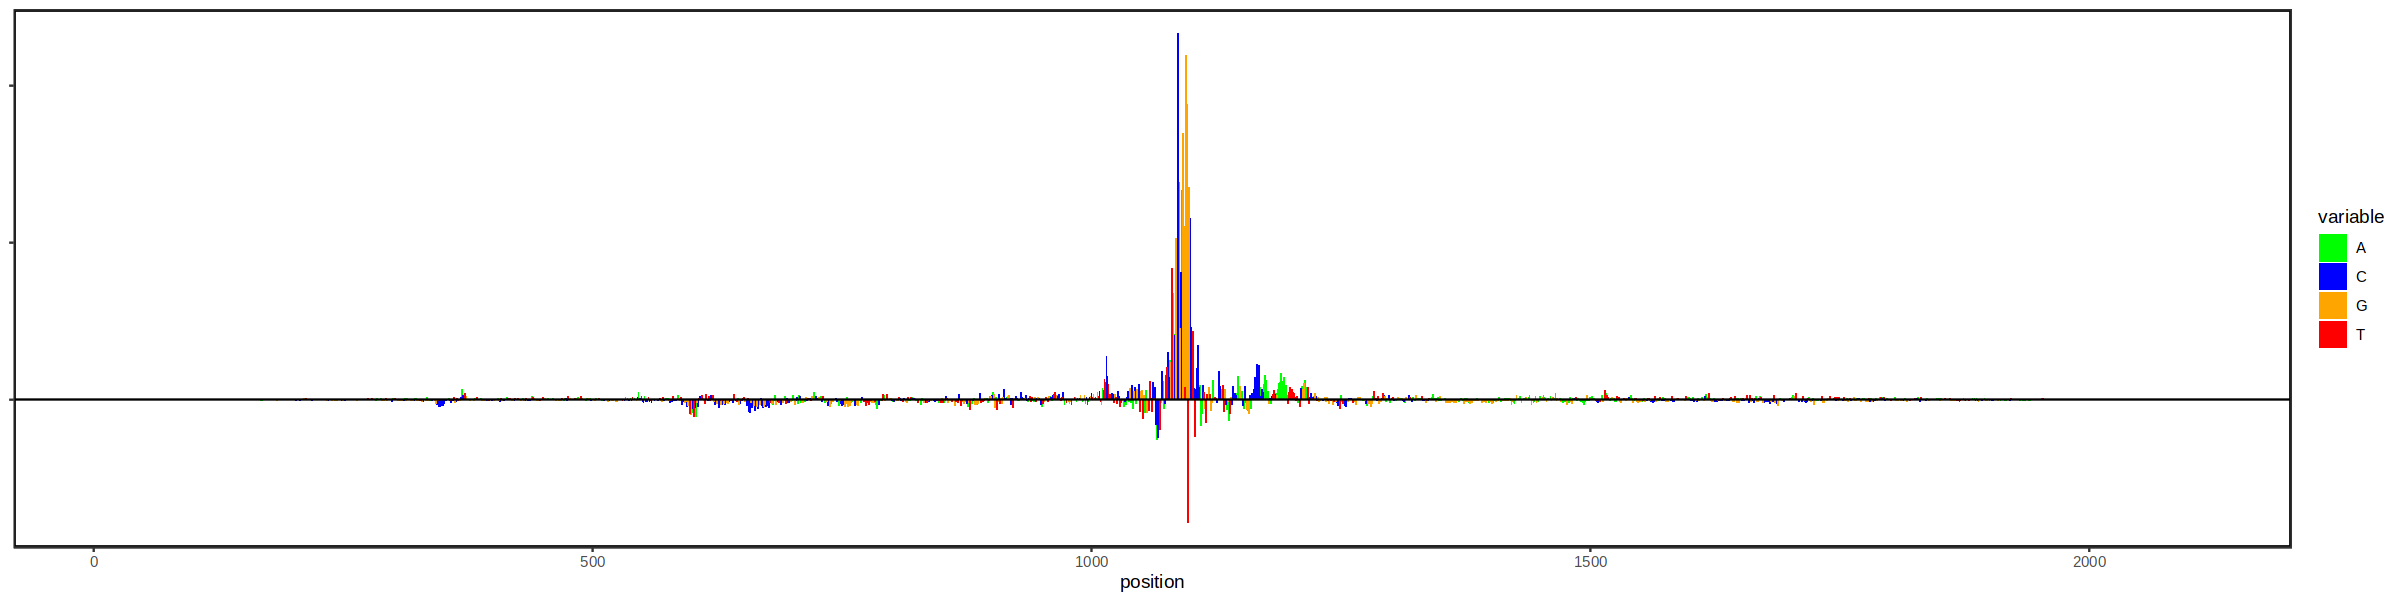

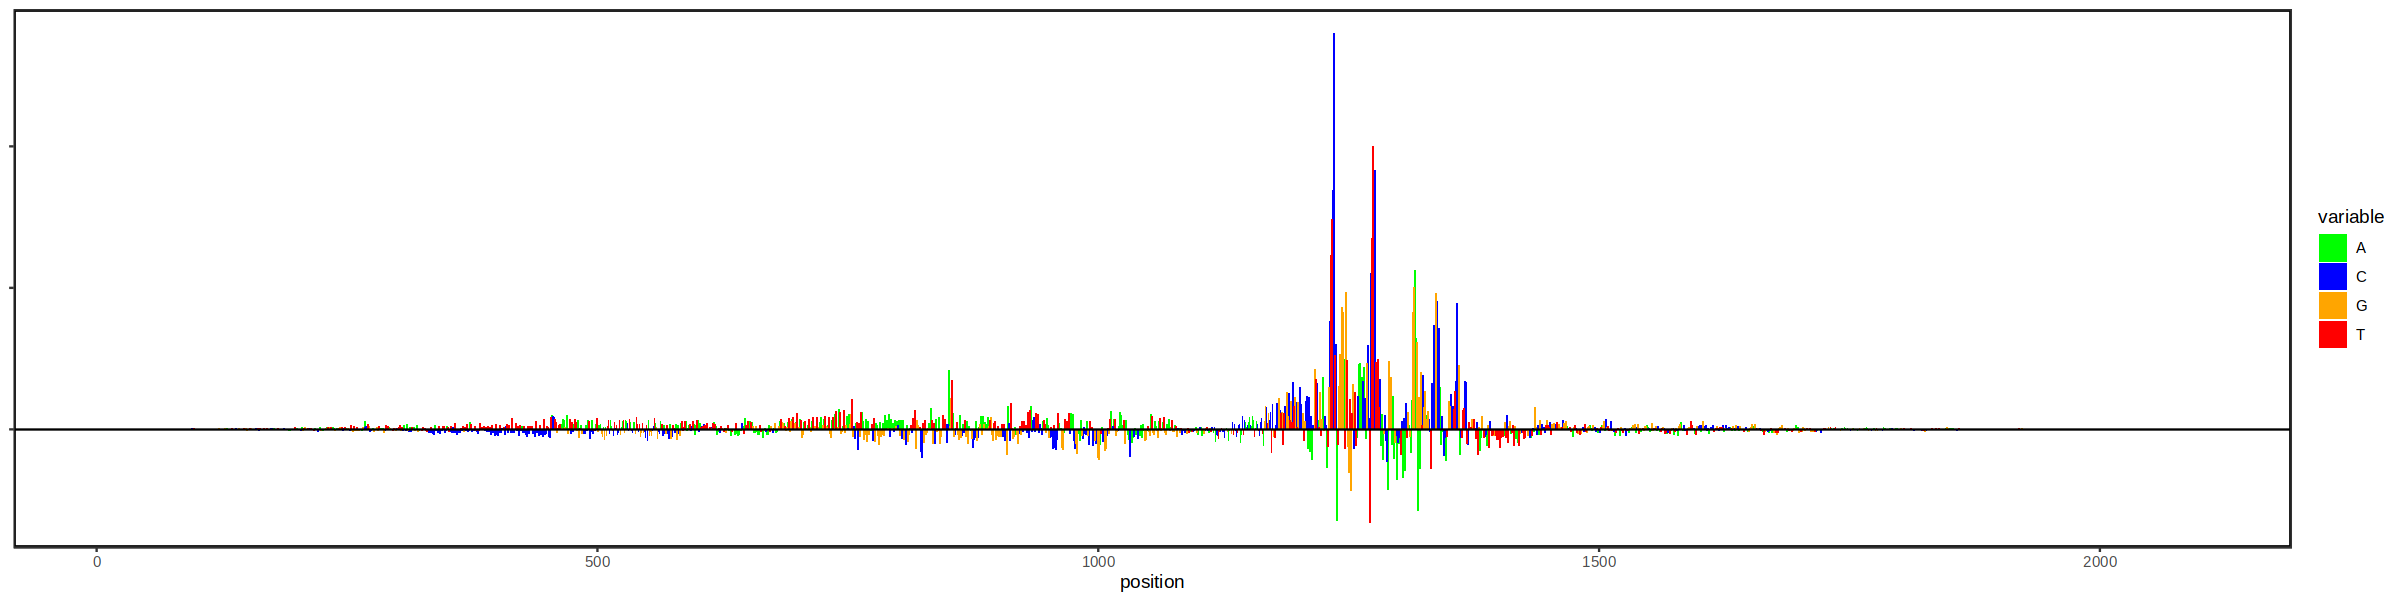

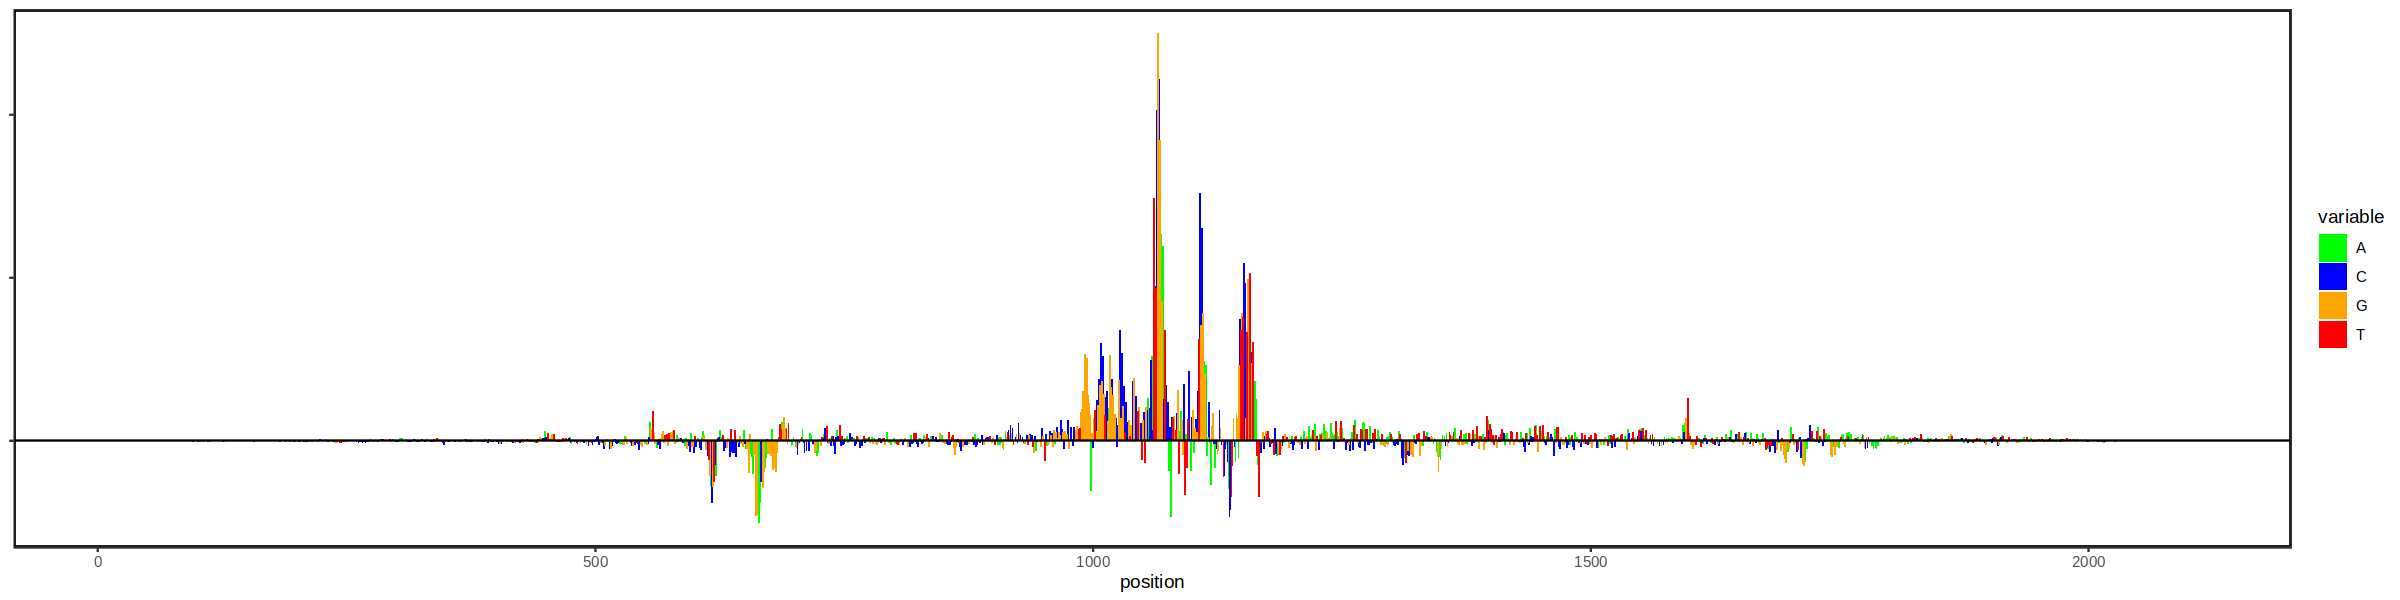

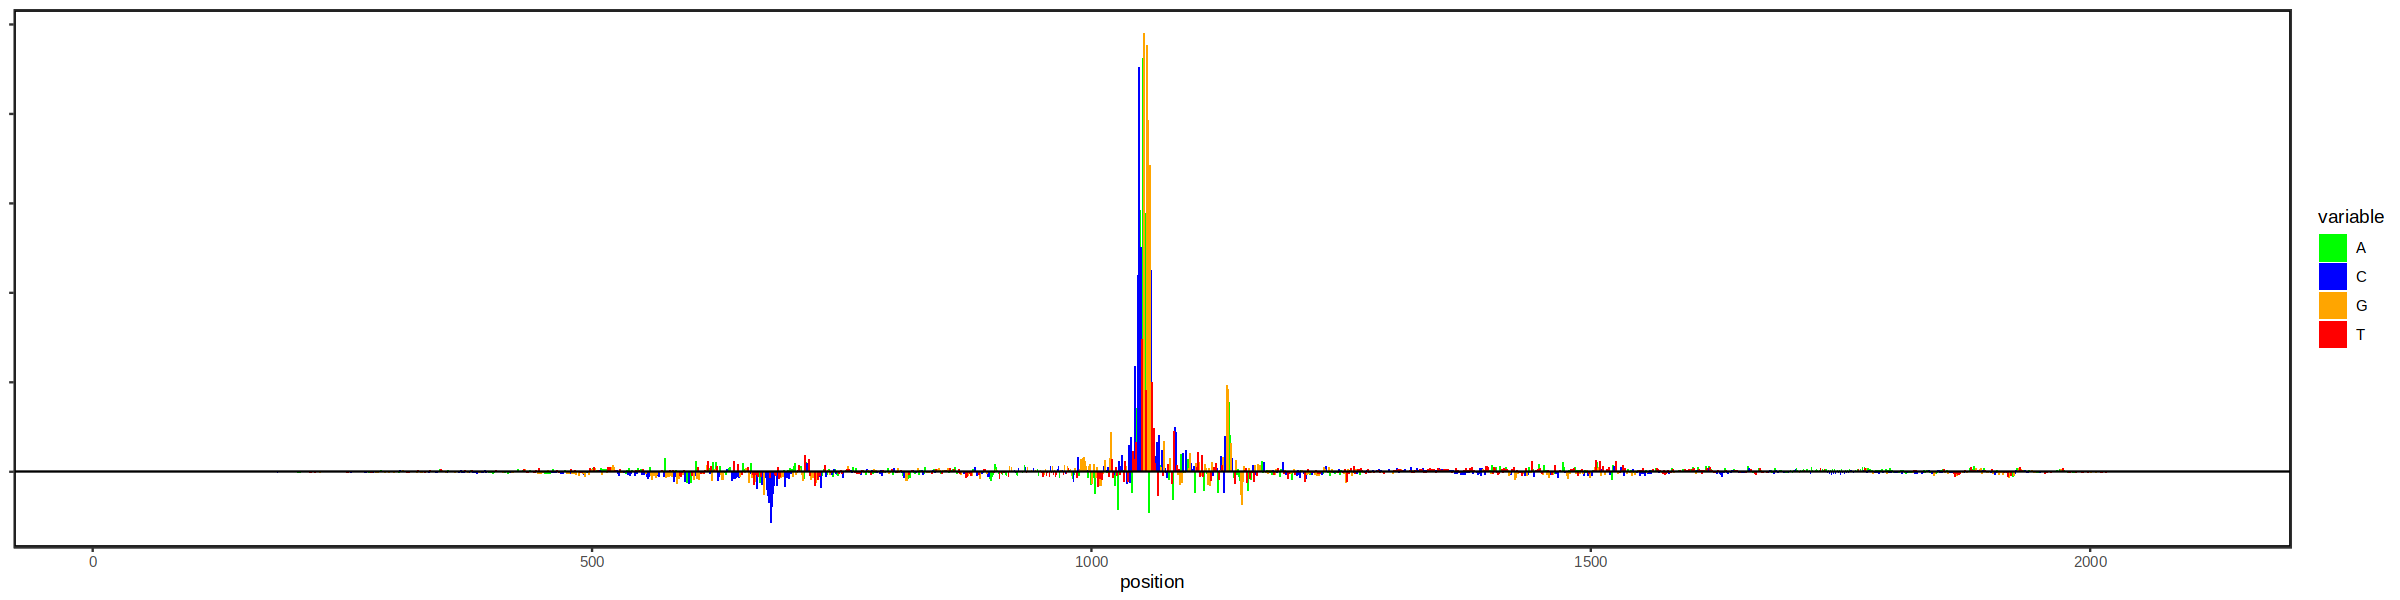

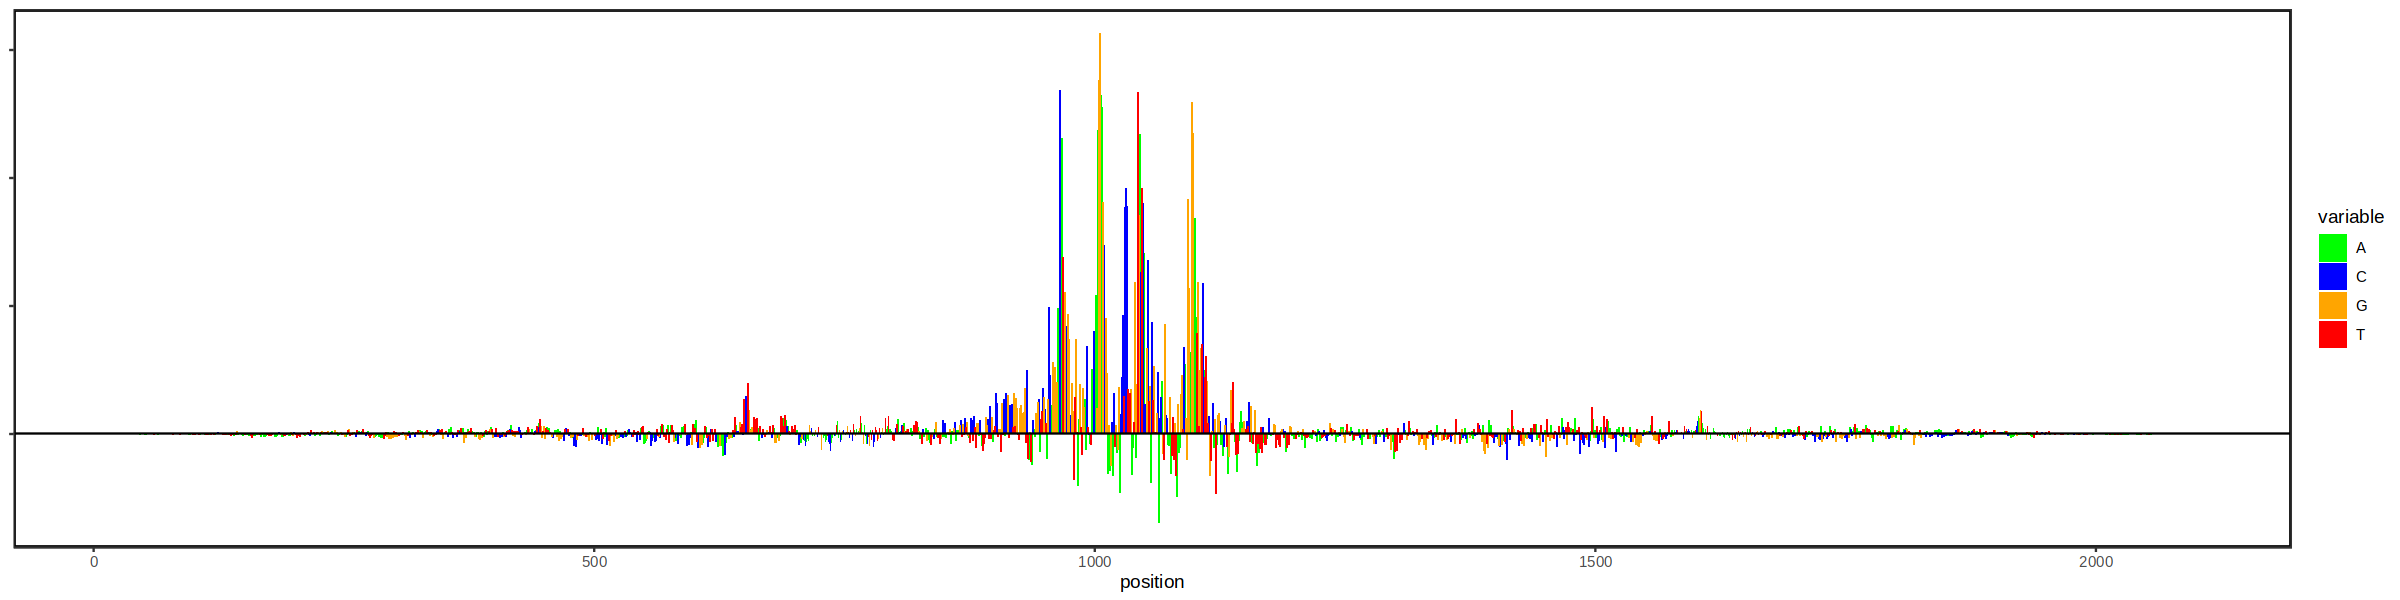

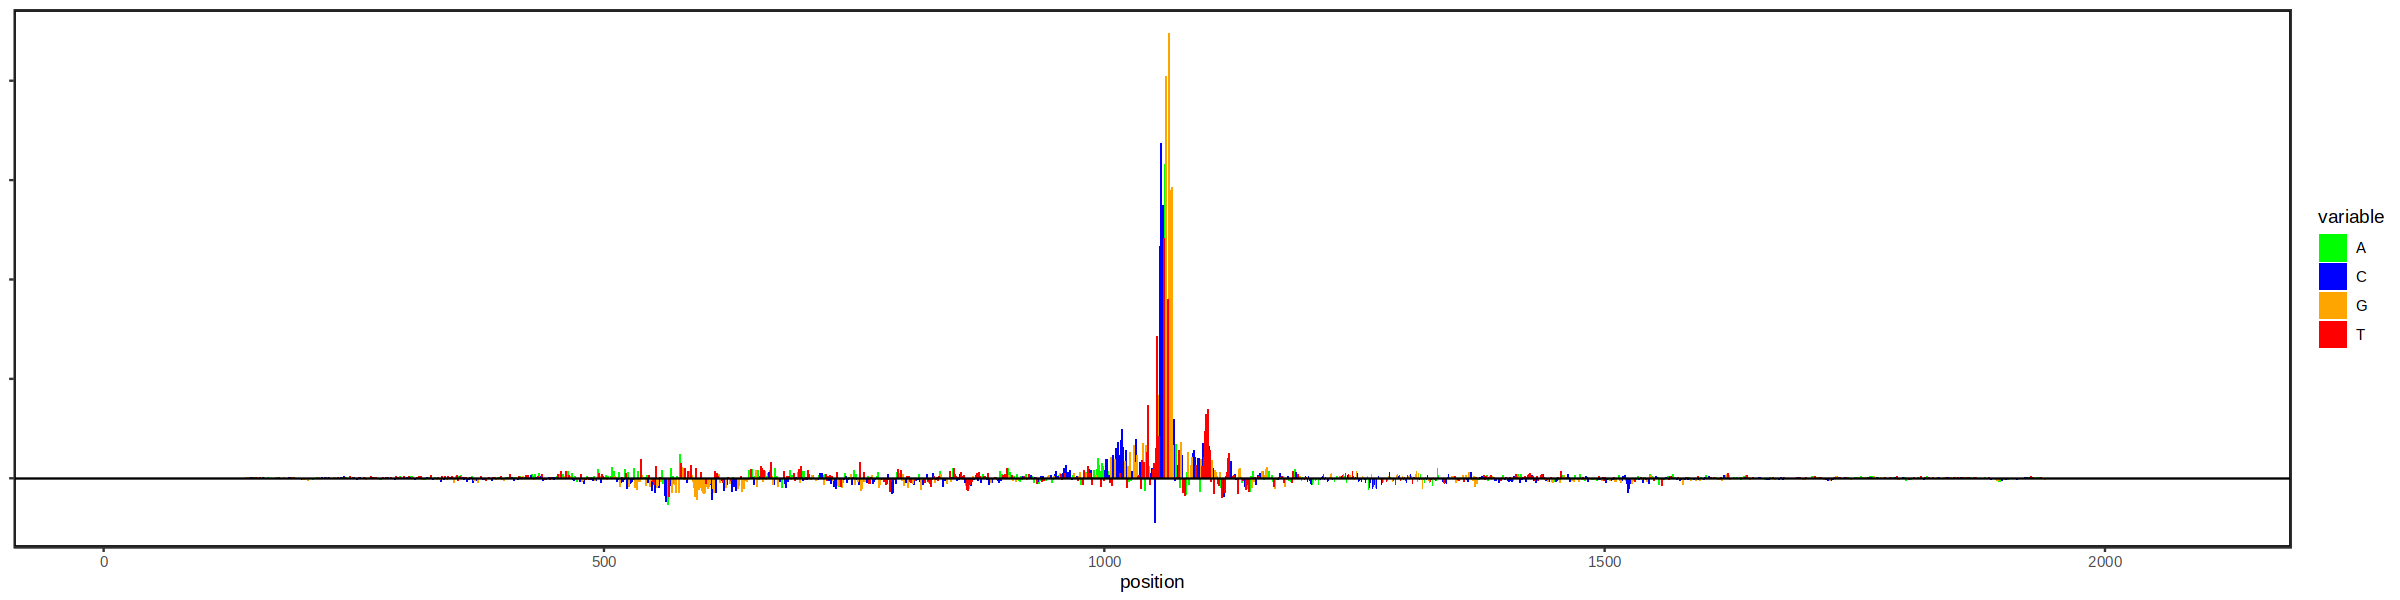

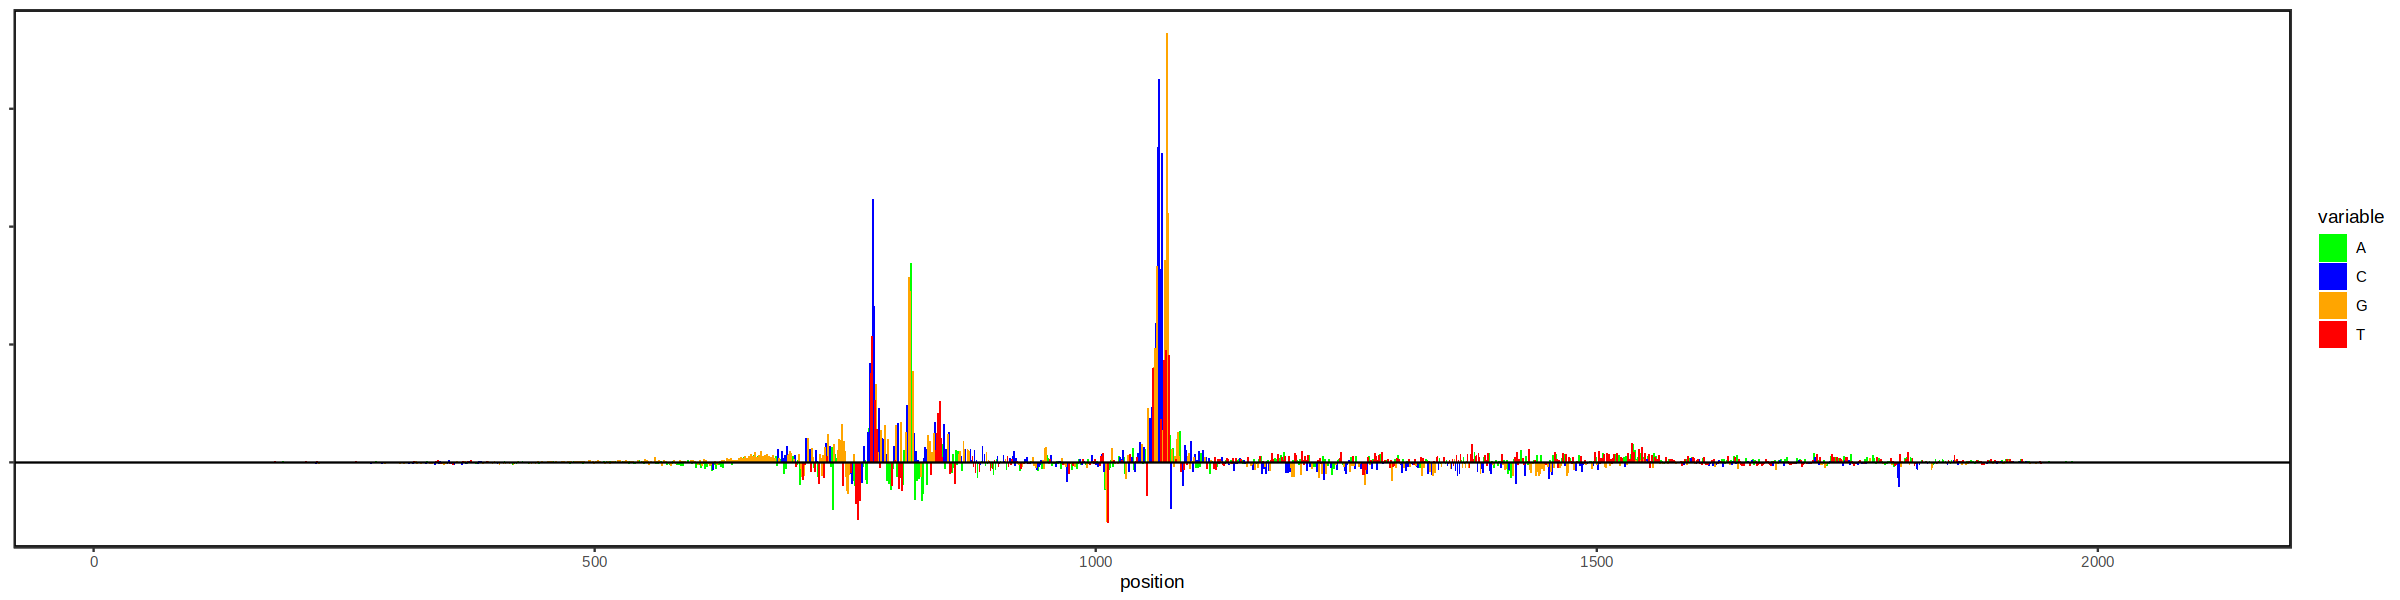

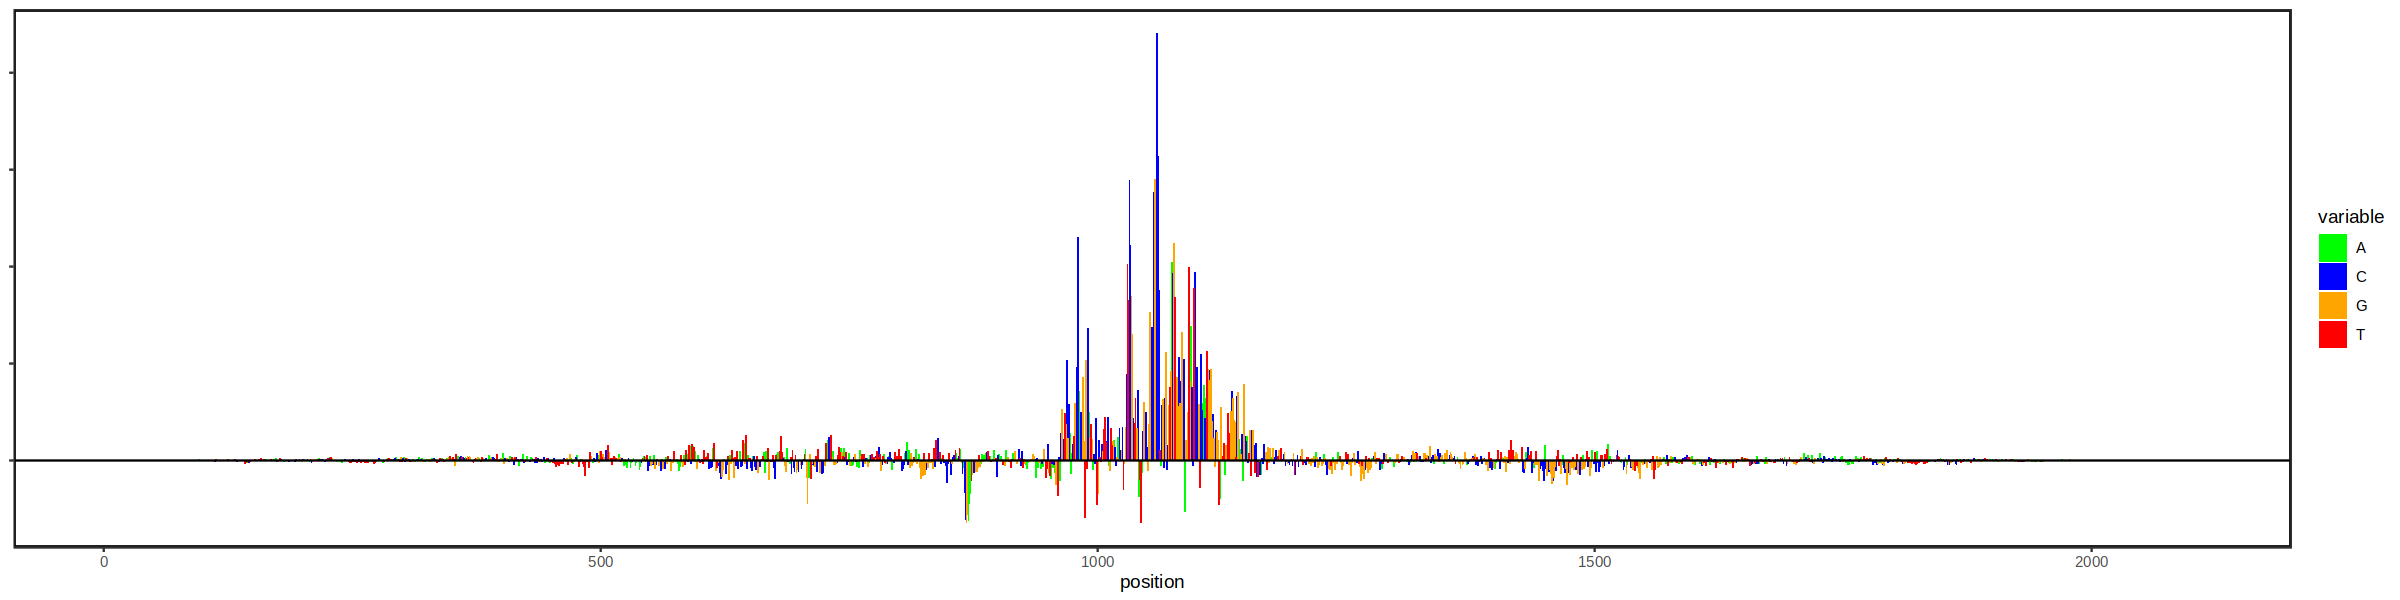

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]

[[11]]


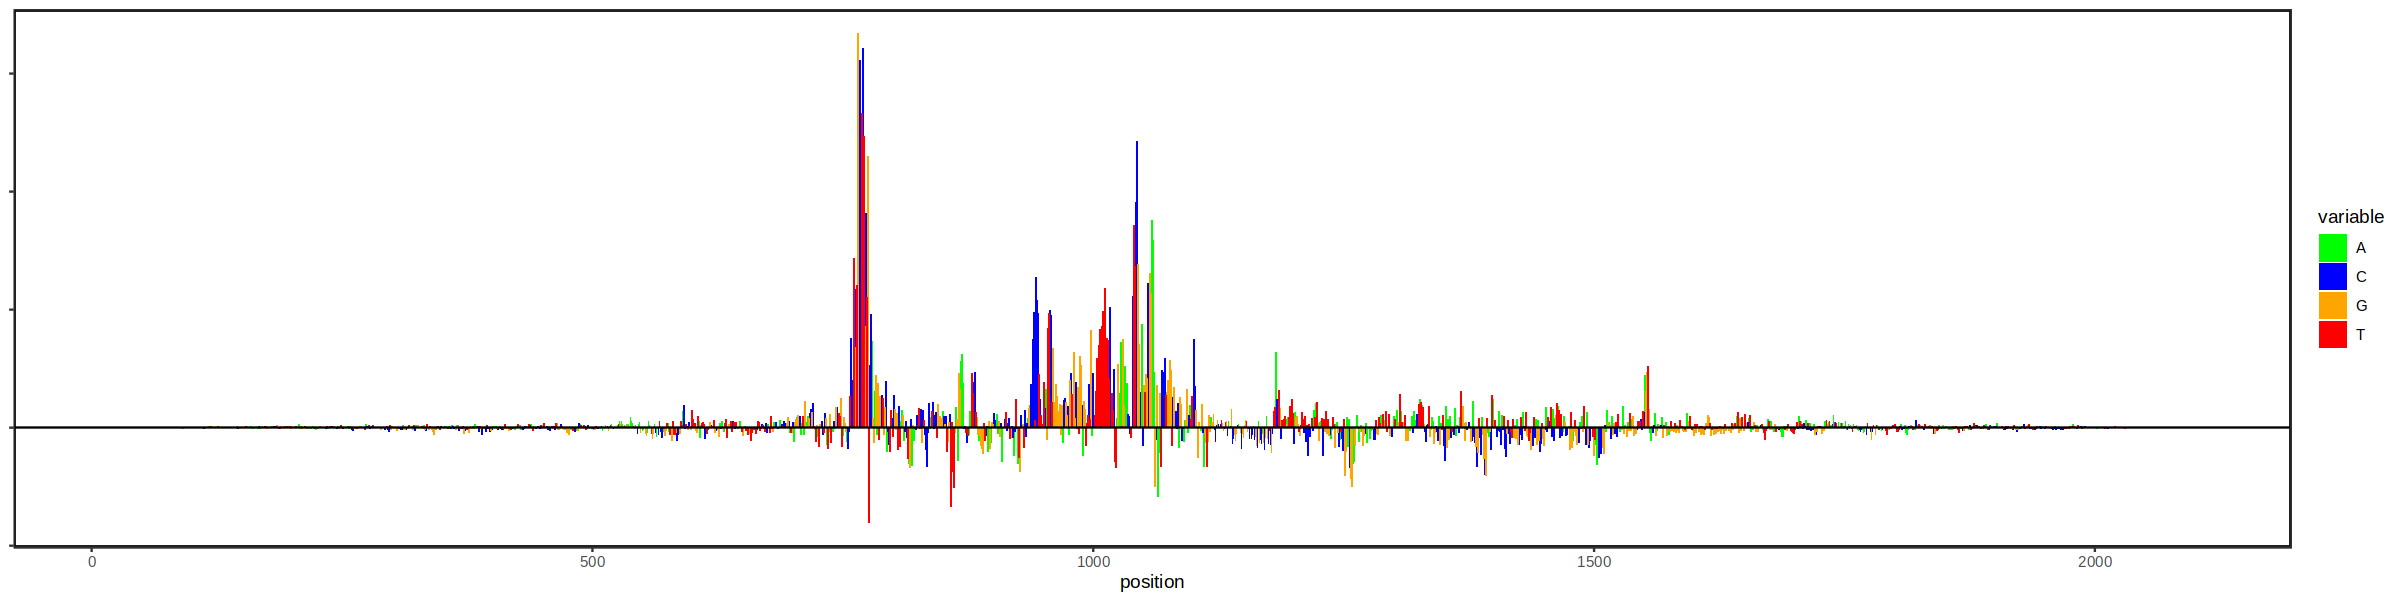

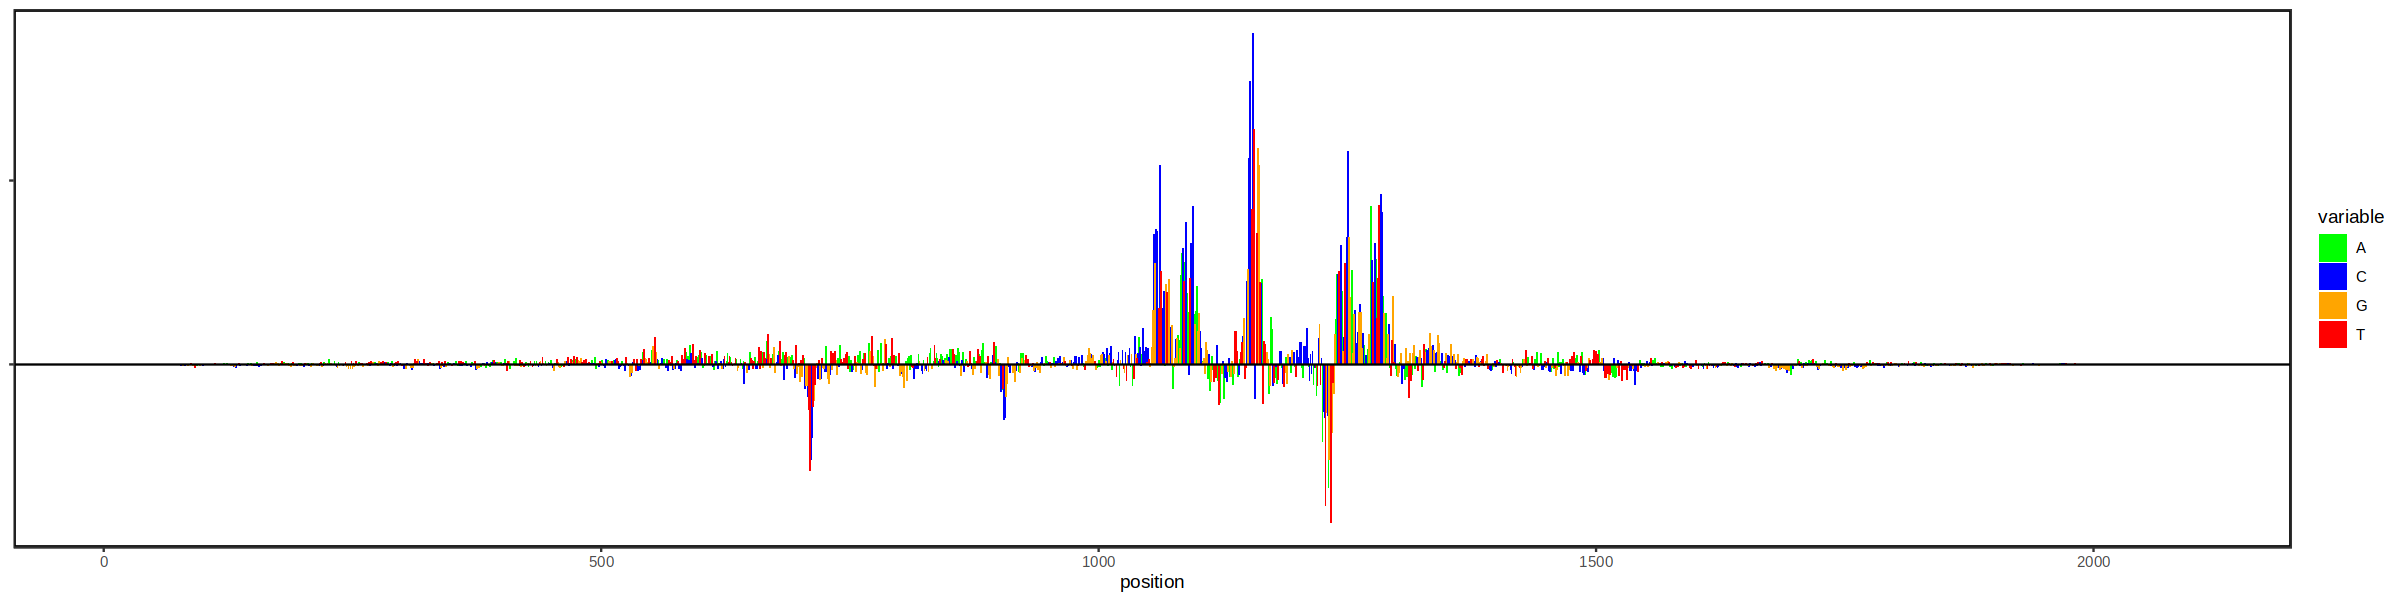

In [88]:
lapply(2000:2010, function(x){
row = boom[x,]$row

    test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]

    
genome = data.table(A = test[1:2114],
           C = test[2115:4228],
           G =  test[4229:6342],
           T =  test[6343:8456]
           ) %>%
    .[, position := .I] %>%
    melt(., id.vars = 'position') %>% 
    .[abs(value) > 0]

options(repr.plot.width = 20, repr.plot.height = 5)
#genome = genome[position > 800 & position < 1200]
ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_blank(),
         axis.title.y = element_blank())
})

# Same for the allantois

In [1]:
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(parallel))



                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
here::i_am("atac/archR/bigwig/create_1bp_bigwigs.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [3]:
ArchRProject = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [4]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/atac/chrombpnet"

In [89]:
outdir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet/allantois'
dir.create(outdir, recursive = T)

Warning message in dir.create(outdir, recursive = T):
“'/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet/allantois' already exists”


In [555]:
meta = as.data.table(ArchRProject@cellColData, keep.rownames = T)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [556]:
endo_meta = meta[celltype.mapped == 'Allantois']

In [557]:
table(endo_meta$sample)


       E7.5_rep1        E8.0_rep1        E8.0_rep2 E8.5_CRISPR_T_KO 
               2              129              120                2 
E8.5_CRISPR_T_WT        E8.5_rep1        E8.5_rep2       E8.75_rep1 
             100              222              146               32 
      E8.75_rep2 
              41 

In [559]:
chrs = c('chr1','chr10','chr11','chr12','chr13','chr14','chr15','chr16','chr17','chr18','chr19','chr2','chr3','chr4','chr5','chr6','chr7','chr8','chr9')
sample = c('E8.0_rep1', 'E8.0_rep2', 'E8.5_rep1', 'E8.5_rep2') 

# Export fragments of endo cells in subset of samples
mclapply(sample, function(x){
    tmp_cell = endo_meta[sample == x, rn] %>% 
        str_split('#') %>%  # get cell names without sample in front of it
        map_chr(2) 
    file = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/original/%s/atac_fragments.tsv.gz', x)
    fragment = fread(file)#,
                  #  tmpdir = '/rds/project/rds-SDzz0CATGms/users/bt392/software/tmp'))
    message('before filtering:')
    message(nrow(fragment))
    message(paste0('chrs: ', unique(fragment$chr)))
    
    fragment = fragment %>% 
        setnames(c('chr', 'start', 'end', 'cell', 'reads')) %>%
        # .[chr == 'chr1'] %>%
        .[cell %in% tmp_cell] %>% 
        .[chr %in% chrs]
    
    message('after filtering:')
    message(nrow(fragment))
    message(paste0('chrs: ', unique(fragment$chr)))
    
    fwrite(fragment, sprintf('%s/%s_allantois.tsv.gz', outdir, x), sep = '\t')
}, mc.cores = 1)

Warning message in fread(file):
“Detected 1 column names but the data has 5 columns (i.e. invalid file). Added 4 extra default column names at the end.”
before filtering:

222428387

chrs: 

after filtering:

4056648

chrs: chr1chrs: chr10chrs: chr11chrs: chr12chrs: chr13chrs: chr14chrs: chr15chrs: chr16chrs: chr17chrs: chr18chrs: chr19chrs: chr2chrs: chr3chrs: chr4chrs: chr5chrs: chr6chrs: chr7chrs: chr8chrs: chr9

Warning message in fread(file):
“Detected 1 column names but the data has 5 columns (i.e. invalid file). Added 4 extra default column names at the end.”
before filtering:

195609304

chrs: 

after filtering:

3690565

chrs: chr1chrs: chr10chrs: chr11chrs: chr12chrs: chr13chrs: chr14chrs: chr15chrs: chr16chrs: chr17chrs: chr18chrs: chr19chrs: chr2chrs: chr3chrs: chr4chrs: chr5chrs: chr6chrs: chr7chrs: chr8chrs: chr9

Warning message in fread(file):
“Detected 1 column names but the data has 5 columns (i.e. invalid file). Added 4 extra default column names at the end.”
before 

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

In [566]:
tmp = lapply(sample, function(x){
    tmp_frag = fread(sprintf('%s/%s_allantois.tsv.gz', outdir, x), sep = '\t')
}) %>% rbindlist() %>% 
    .[order(chr, start)]

fwrite(tmp, sprintf('%s/allantois_fragments.tsv.gz', outdir), col.names = F, sep = '\t')
# fwrite(tmp, sprintf('%s/endo_fragments.tsv', outdir), col.names = F, sep = '\t')

In [567]:
tmp = fread(sprintf('%s/allantois_fragments.tsv.gz', outdir))

In [577]:
nrow(tmp)
unique(tmp[,1])

[1] 19307180

V1
<chr>
chr1
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17


In [569]:
peaks = as.data.table(
    readRDS(
        '../../../data/processed/atac/archR/PeakCalls/Allantois-reproduciblePeaks.gr.rds'
        )
    ) %>%
    .[, middle := start + (end - start) / 2] %>%
    .[,`:=`(start = middle - 1057, 
            end = middle + 1057,
            column4 = '.',
            column5 = '.',
            column6 = '.',
            column7 = '.',
            column8 = '.',
            column9 = '.',
            column10 = 1057)] %>% 
    .[,.(seqnames, 
         start, 
         end, 
         column4,
         column5,
         column6,
         column7,
         column8,
         column9,
         column10)] %>%
    .[seqnames != 'chrX']


head(peaks)

seqnames,start,end,column4,column5,column6,column7,column8,column9,column10
<fct>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
chr1,92179289,92181403,.,.,.,.,.,.,1057
chr1,177795569,177797683,.,.,.,.,.,.,1057
chr2,26444336,26446450,.,.,.,.,.,.,1057
chr3,19187112,19189226,.,.,.,.,.,.,1057
chr4,135271945,135274059,.,.,.,.,.,.,1057
chr4,139573433,139575547,.,.,.,.,.,.,1057


In [570]:
peaks.gr = GenomicRanges::makeGRangesFromDataFrame(peaks, keep.extra.columns = T)
overlaps = GenomicRanges::findOverlaps(peaks.gr, ArchRProject@genomeAnnotation$blacklist)

peaks.gr = peaks.gr[-queryHits(overlaps)]

In [571]:
peaks = as.data.table(peaks.gr)[,`:=`(width=NULL, strand=NULL)]
fwrite(peaks, sprintf('%s/peaks.bed', outdir), col.names = F, sep = '\t')

In [572]:
nrow(peaks)
tail(peaks)

[1] 42136

seqnames,start,end,column4,column5,column6,column7,column8,column9,column10
<fct>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
chr9,46327733,46329847,.,.,.,.,.,.,1057
chr9,78488092,78490206,.,.,.,.,.,.,1057
chr11,114016059,114018173,.,.,.,.,.,.,1057
chr15,60820775,60822889,.,.,.,.,.,.,1057
chr15,97372901,97375015,.,.,.,.,.,.,1057
chr17,87184610,87186724,.,.,.,.,.,.,1057


In [573]:
chromSizes = as.data.table(ArchRProject@genomeAnnotation$chromSizes) %>%
    .[,.(seqnames, end)]
fwrite(chromSizes, sprintf('%s/mm10.chrom.sizes', outdir), col.names = F, sep = '\t')

In [574]:
fwrite(as.data.table(ArchRProject@genomeAnnotation$blacklist) %>%
           .[,.(seqnames, start, end)],
       sprintf('%s/blacklist.bed.gz', outdir), col.names = F, sep = '\t')

# Read ChromBPNet contribution files

In [6]:
# For all the top hits the explainability is precisely in the center of the peak, indicating pure overfitting if i'm interpretting it correctly
# But the ChromBPNet report looks perfect..?

# Actually it makes sense and is just because of the most determininstic factors being in the centre of the peak

In [7]:
library(rhdf5)

In [8]:
h5ls(sprintf("%s/chrombpnet_model/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir))


,group,name,otype,dclass,dim
,<chr>,<chr>,<chr>,<chr>,<chr>
0,/,projected_shap,H5I_GROUP,,
1,/projected_shap,seq,H5I_DATASET,FLOAT,2114 x 4 x 30000
2,/,raw,H5I_GROUP,,
3,/raw,seq,H5I_DATASET,INTEGER,2114 x 4 x 30000
4,/,shap,H5I_GROUP,,
5,/shap,seq,H5I_DATASET,FLOAT,2114 x 4 x 30000


In [179]:
mydata <- h5read(sprintf("%s/chrombpnet_model/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir), "/projected_shap/seq")


ERROR: Error in H5Lexists(loc$H5Identifier, name): HDF5. Links. Can't get value.


In [181]:
str(mydata)

 num [1:2114, 1:4, 1:30000] 0 0 0 0 0 0 0 0 0 0 ...


In [190]:
mydata <- h5read(sprintf("%s/chrombpnet_model/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir), "/raw/seq")


In [198]:
genome = data.table(A = test[1:2114],
           T = test[2115:2114+2114],
           C =  test[2114+2114+1:2114+2114+2114],
           G =  test[2114+2114+2114+1:2114+2114+2114+2114]
           )

In [90]:
mydata <- h5read(sprintf("%s/chrombpnet_model/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir), "/projected_shap/seq")


In [91]:
row = 10
test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]
2114 * (row*4) + 1 
2114 * (row * 4) + 2114*4

[1] 84561

[1] 93016

In [92]:
min(test)

[1] -0.001923561

In [93]:
max(test)

[1] 0.007343292

In [94]:
boom = mclapply(1:30000, function(x){
    test = mydata[(2114 * (x*4) + 1 ): (2114 * (x * 4) + 2114*4)]
    tmp = data.table(row = x,
                     max = max(test))
                     
    return(tmp)
}, mc.cores = 24) %>% rbindlist() %>%
    .[order(-max)]
    
    

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Removed 1 rows containing non-finite values (`stat_bin()`).”


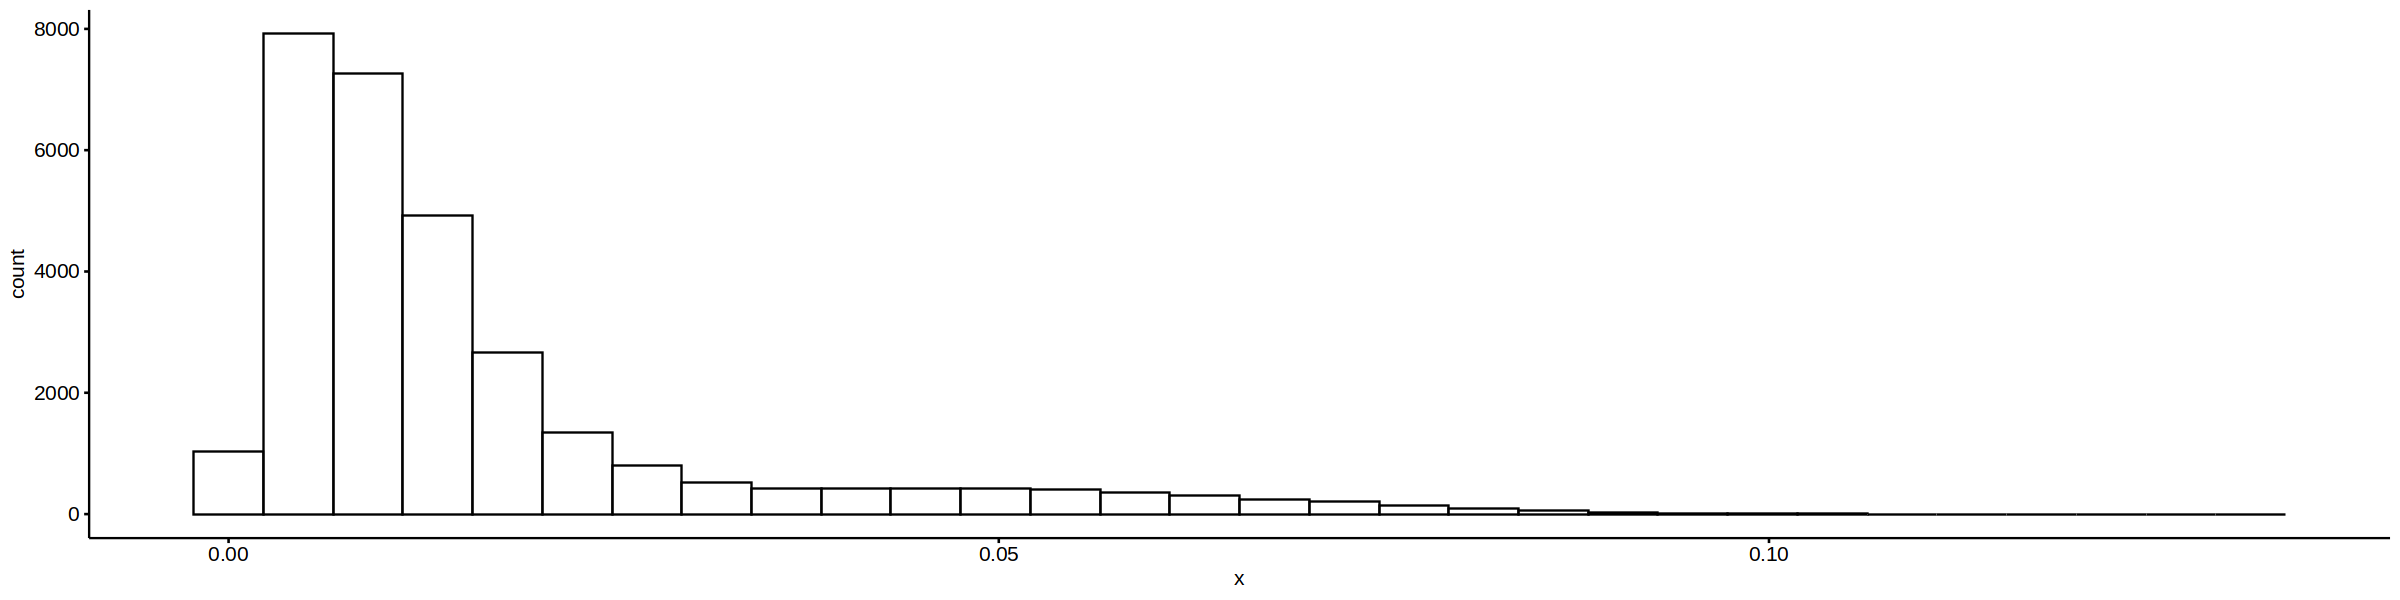

In [95]:
gghistogram(boom$max)

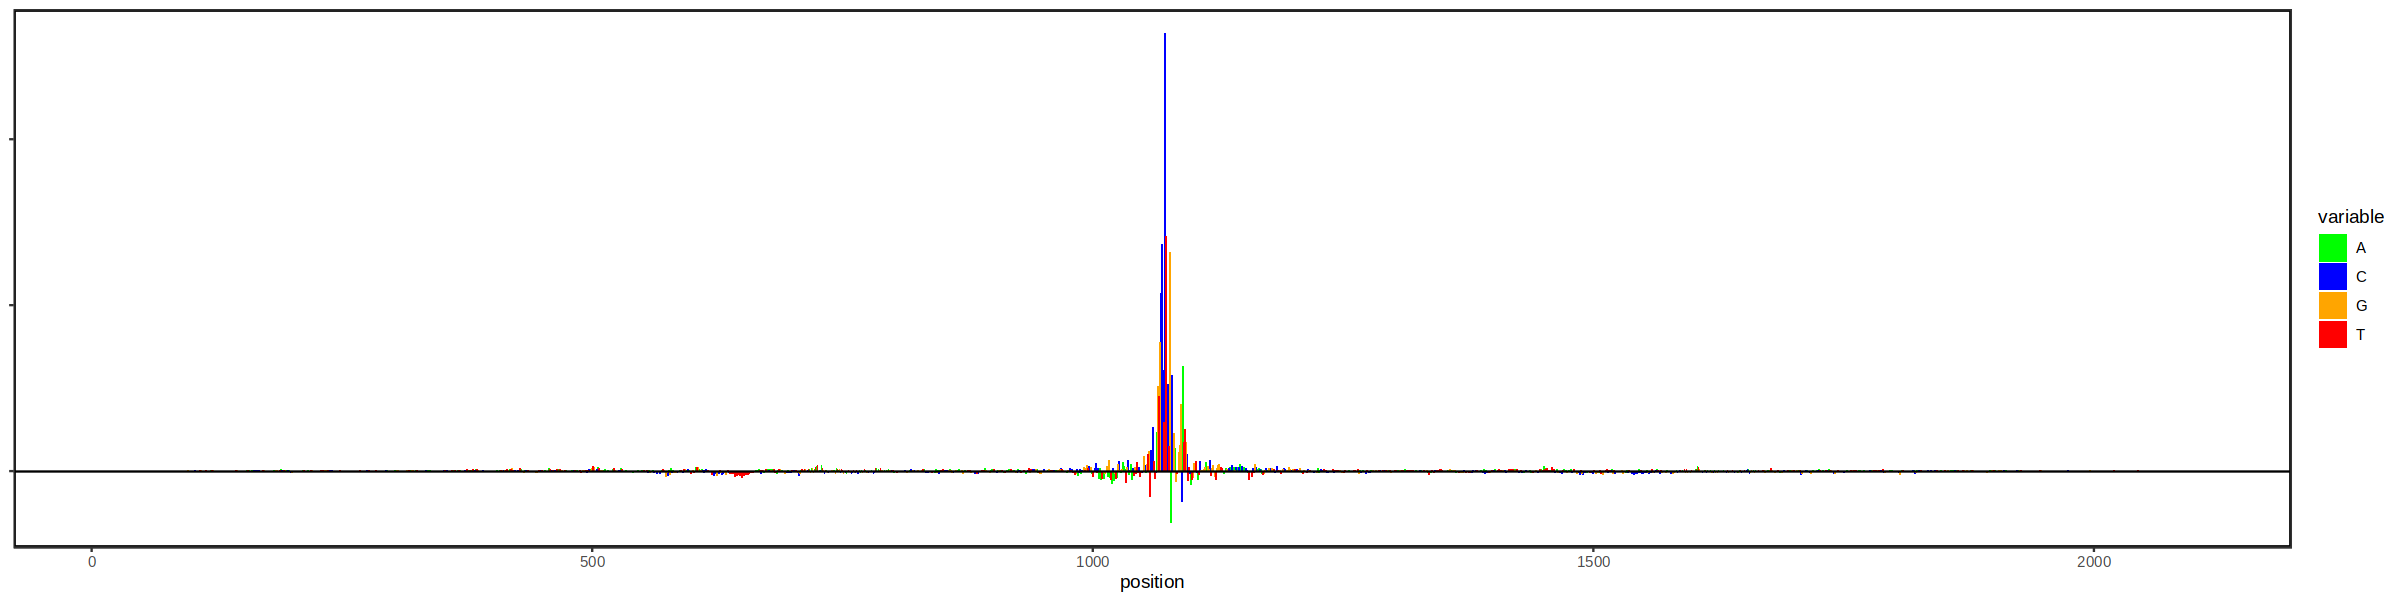

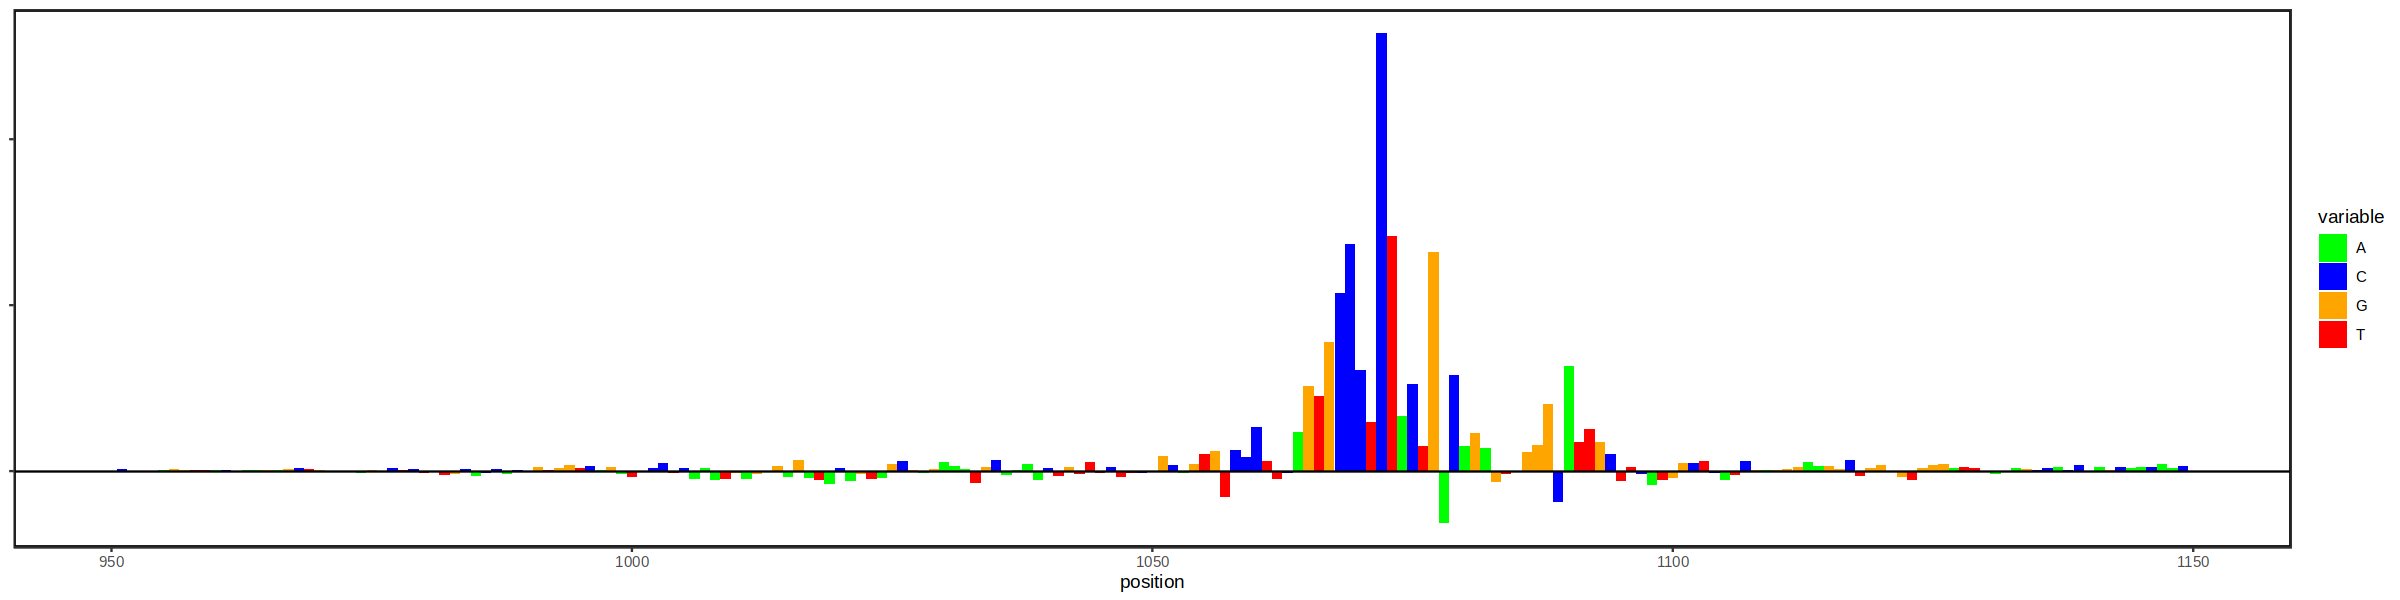

In [96]:
row = boom[1,]$row
test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]

genome = data.table(A = test[1:2114],
           C = test[2115:4228],
           G =  test[4229:6342],
           T =  test[6343:8456]
           ) %>%
    .[, position := .I] %>%
    melt(., id.vars = 'position') %>% 
    .[abs(value) > 0]

options(repr.plot.width = 20, repr.plot.height = 5)
ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_blank(),
         axis.title.y = element_blank())
options(repr.plot.width = 20, repr.plot.height = 5)
genome = genome[position > 950 & position < 1150]
#genome = genome[position > 1200 & position < 1400]

ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_blank(),
         axis.title.y = element_blank())

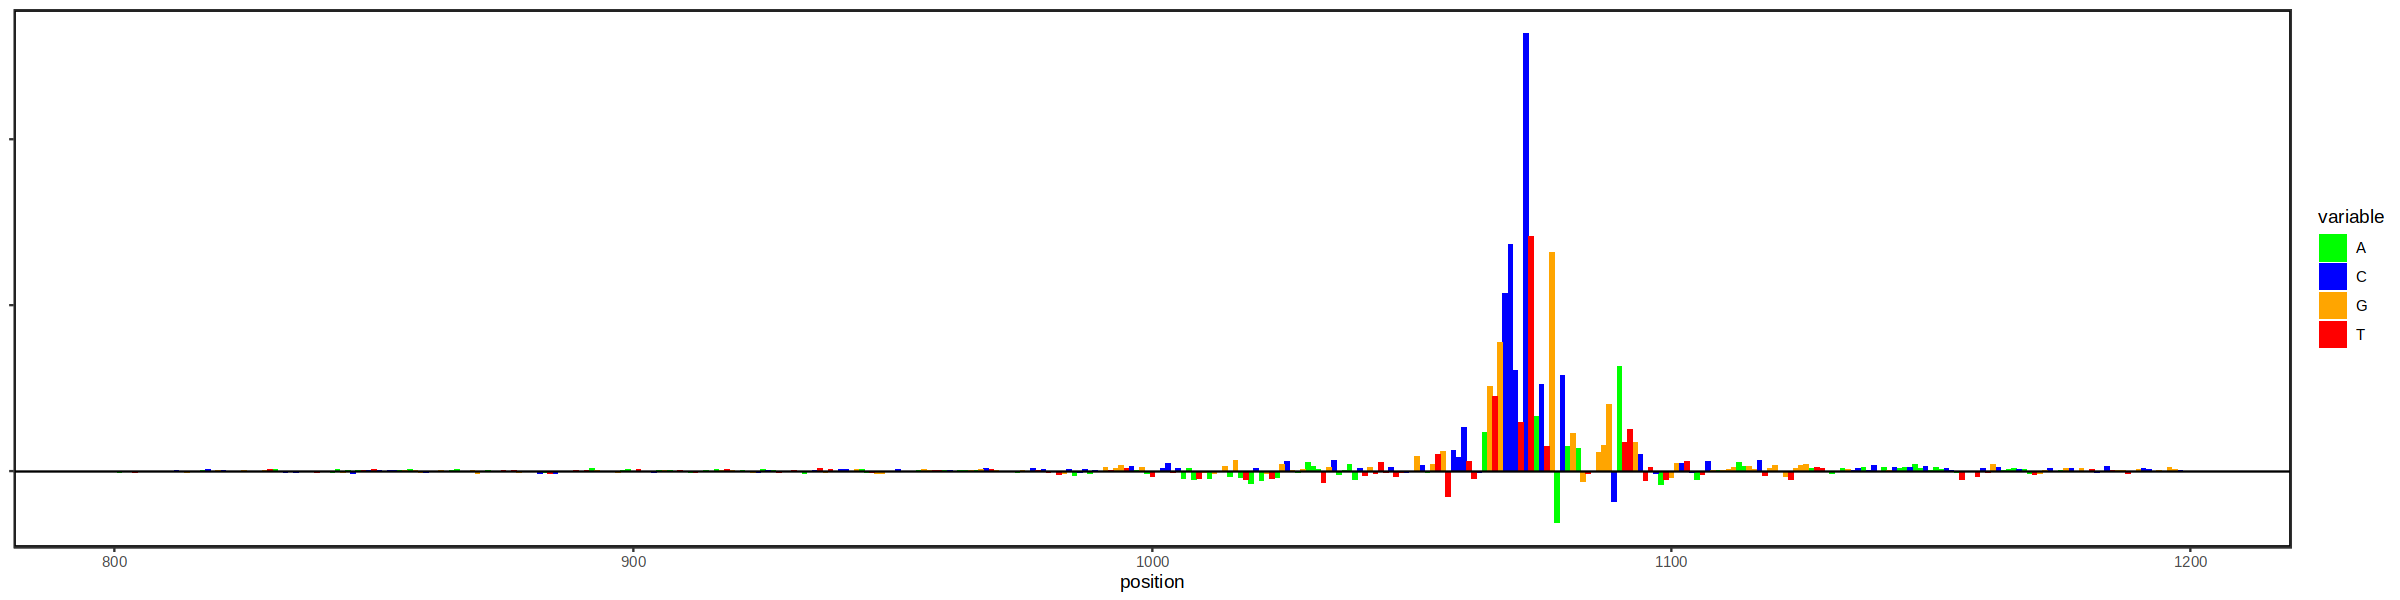

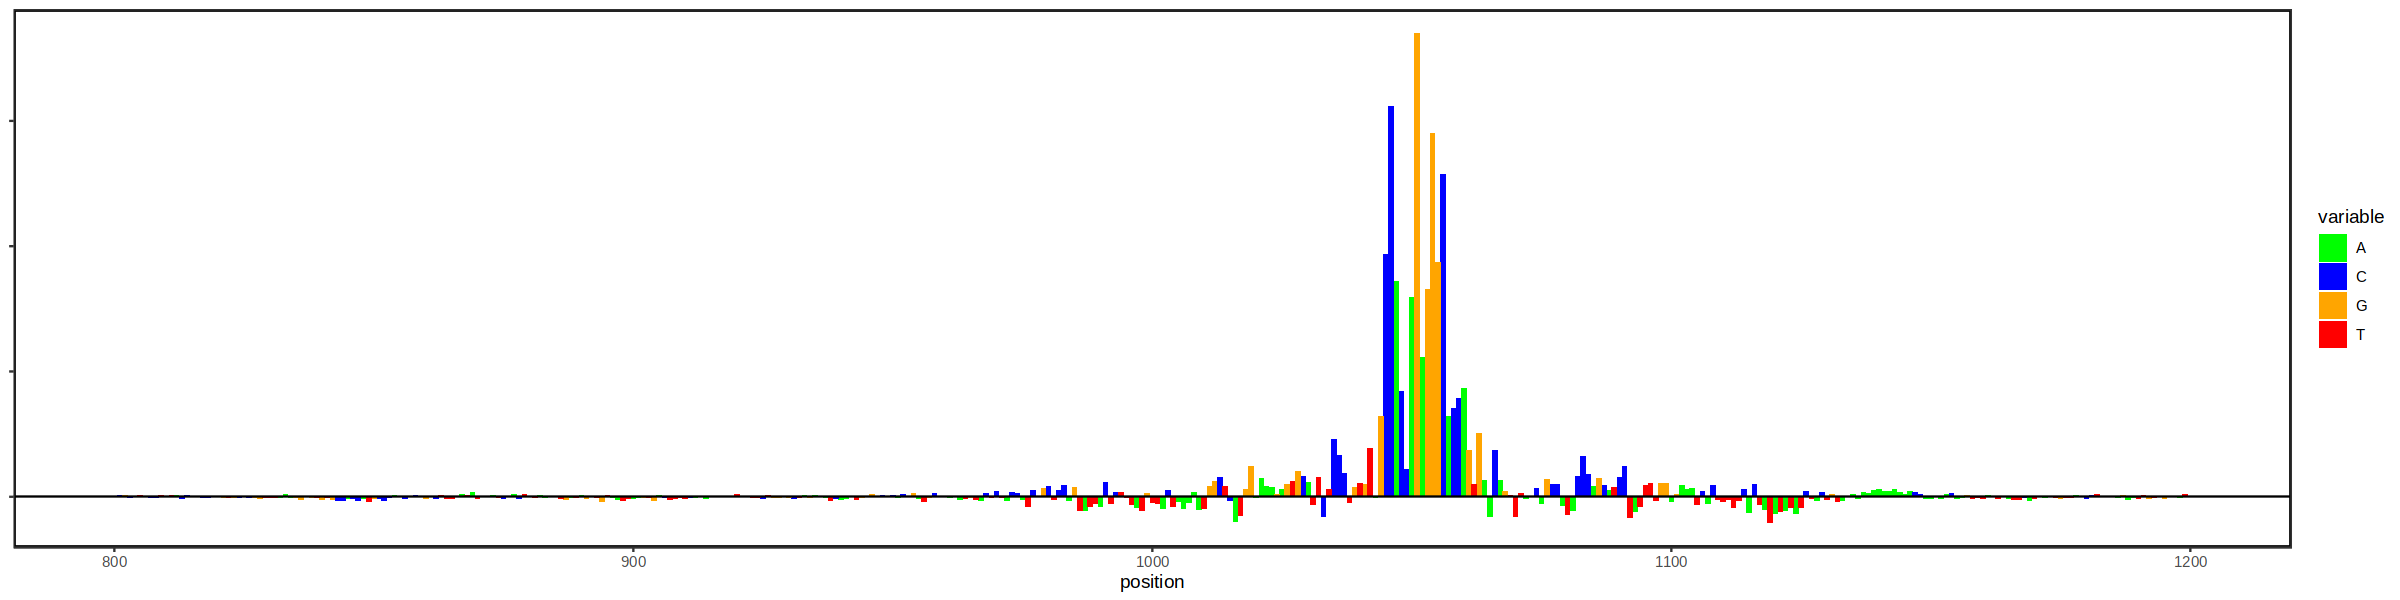

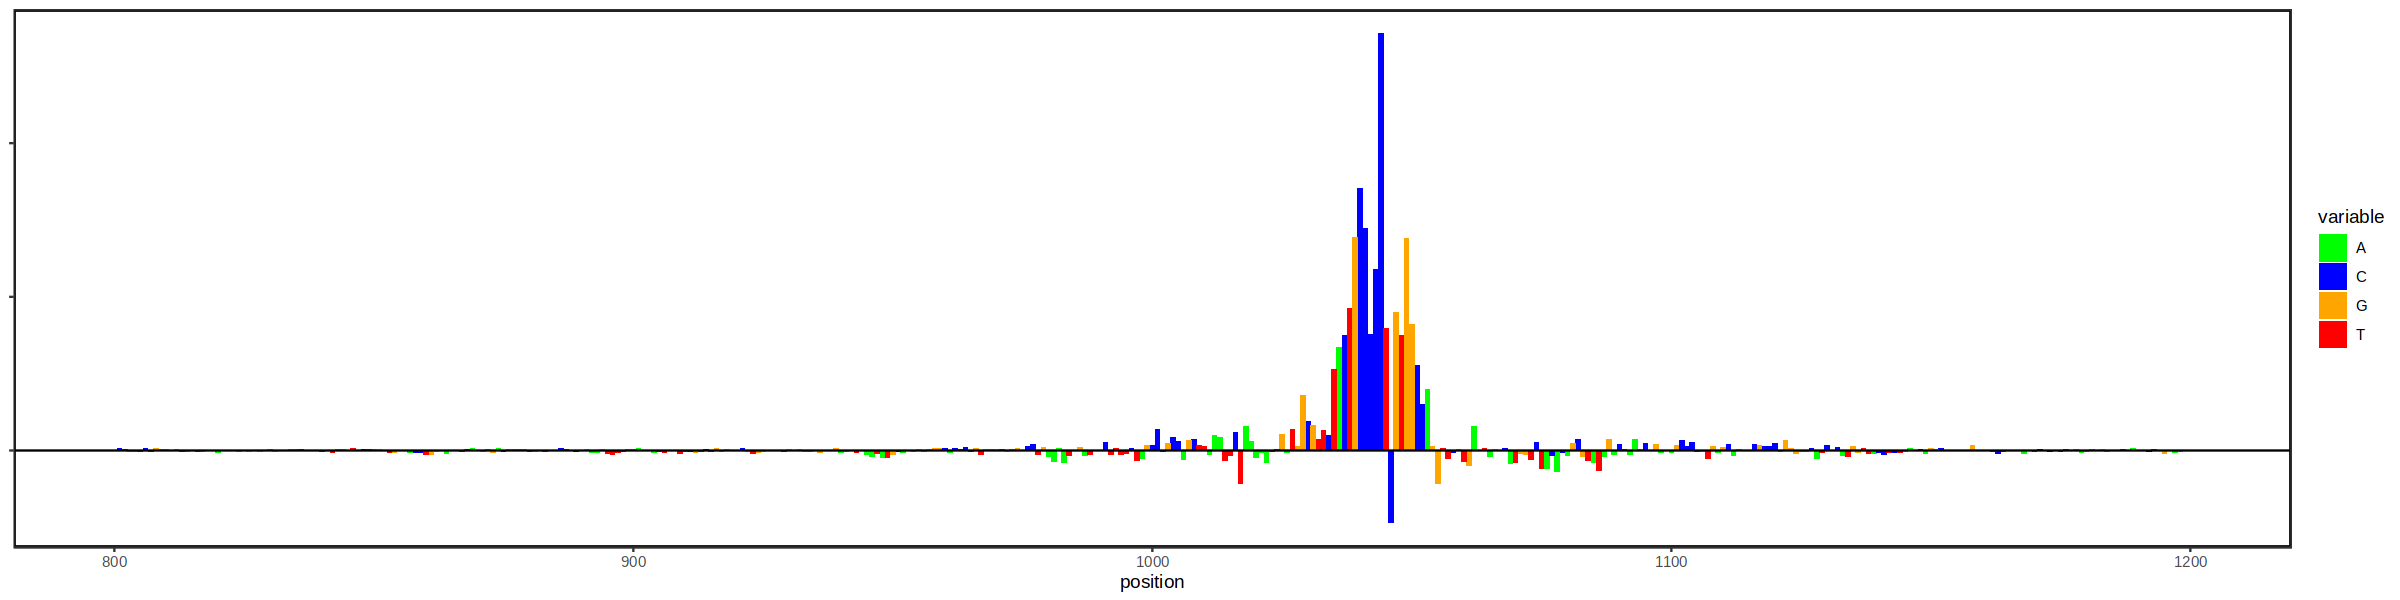

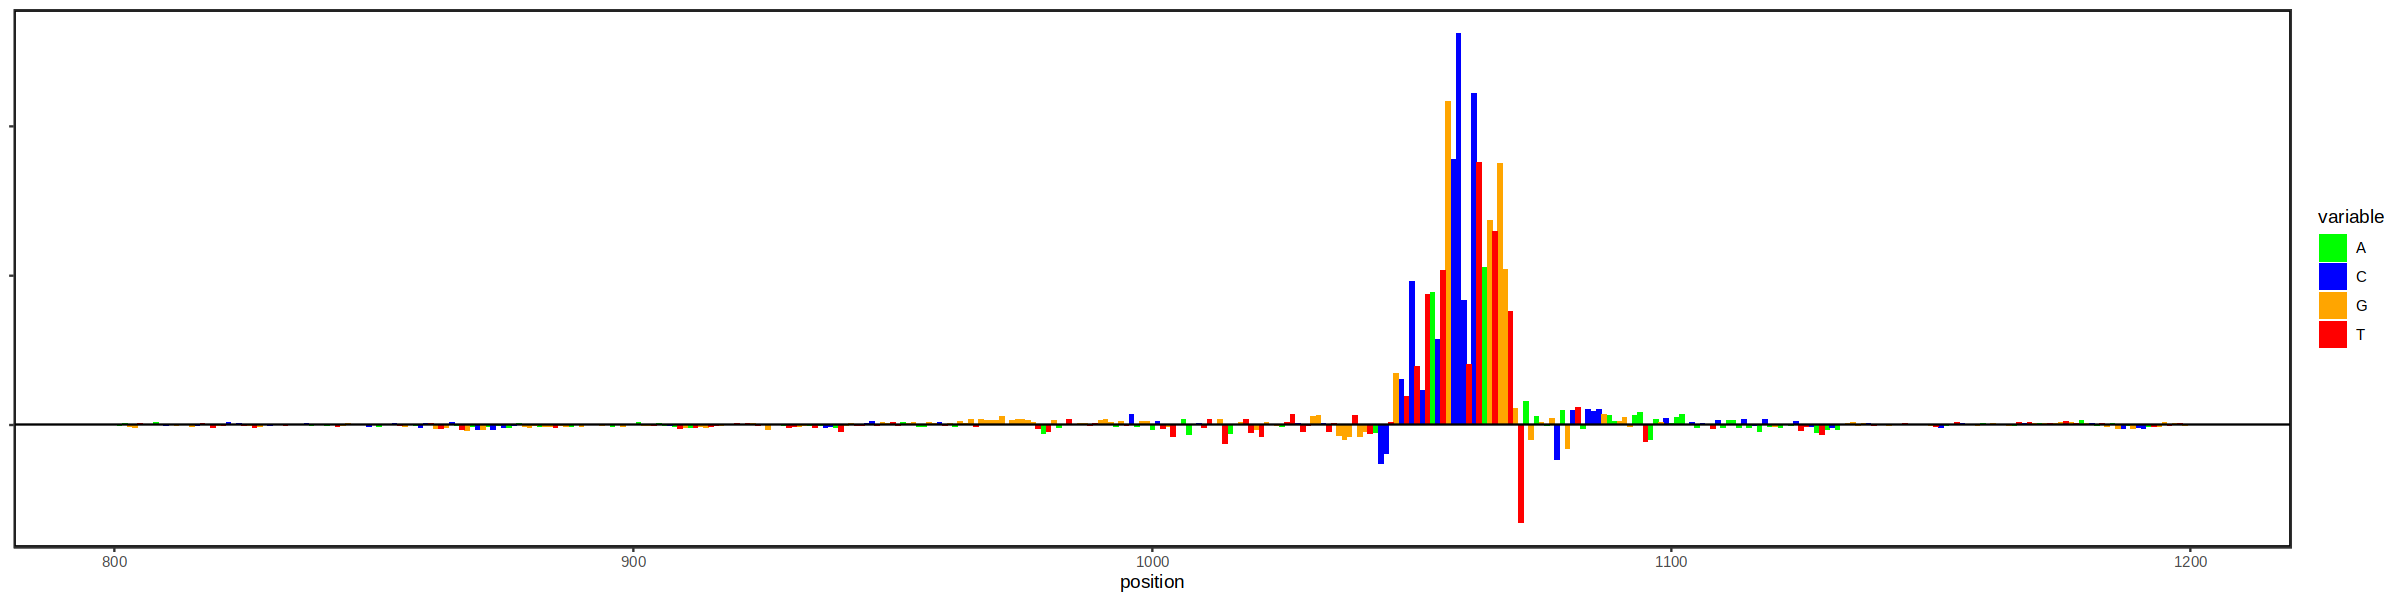

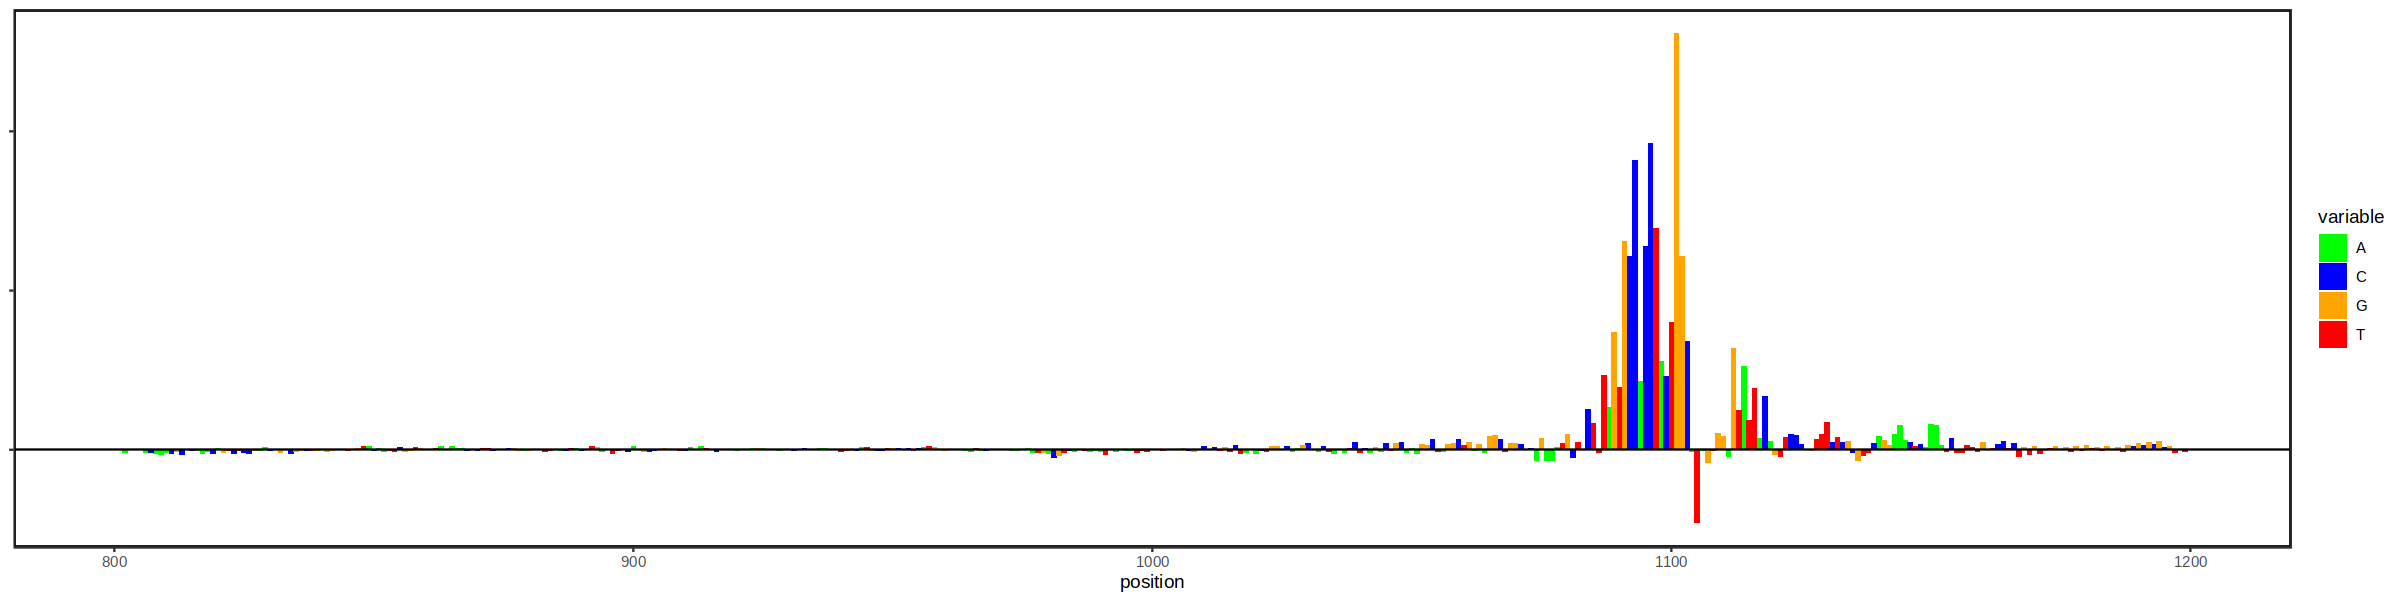

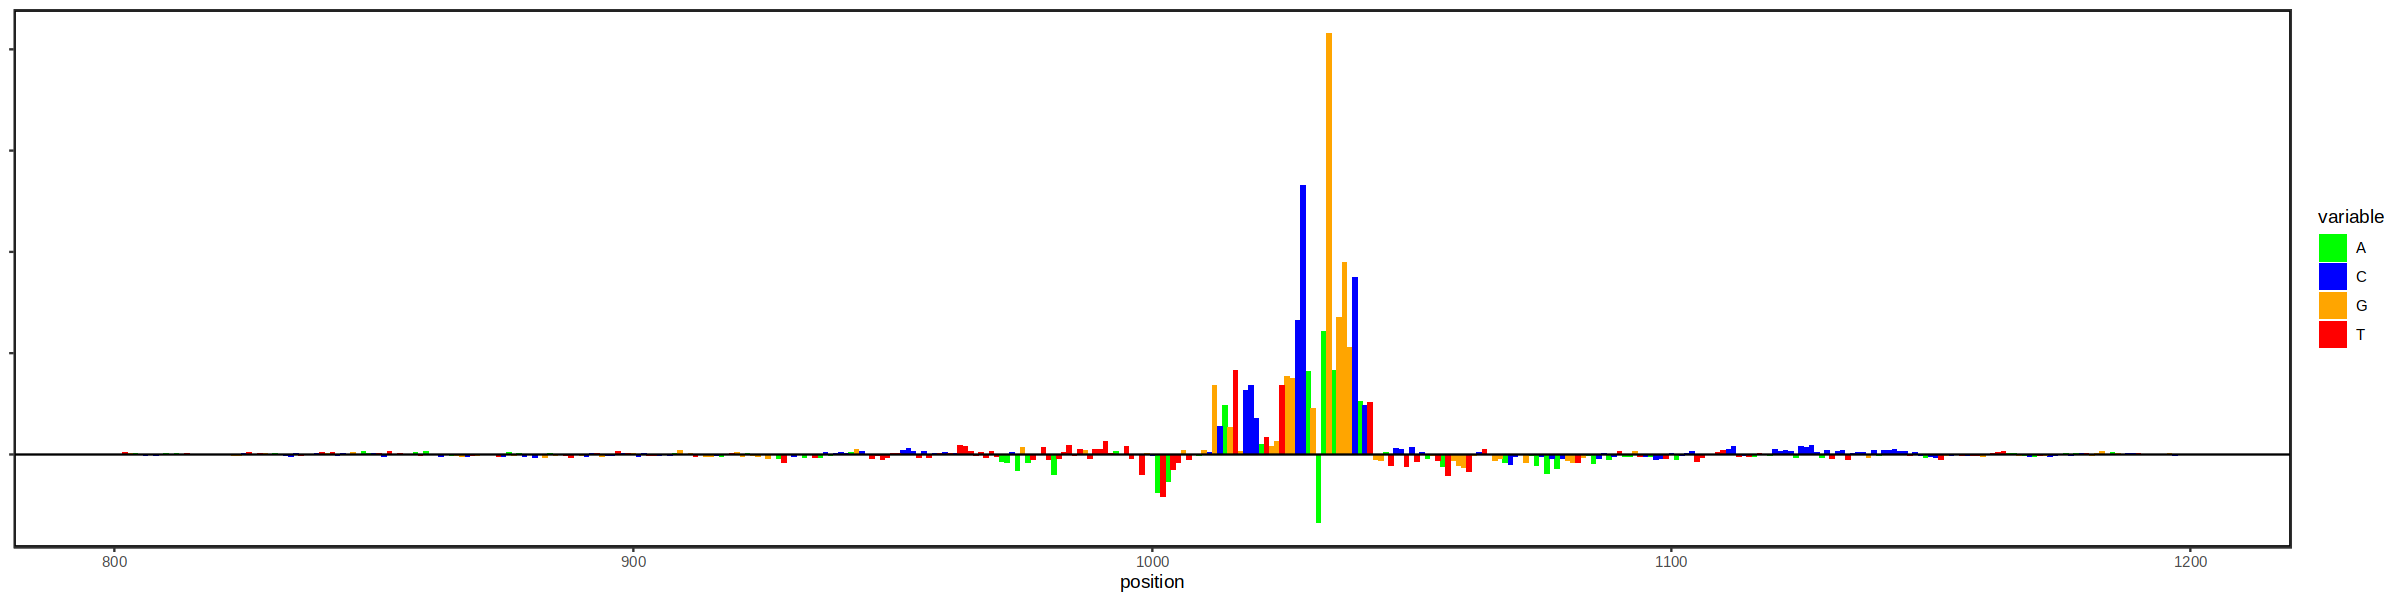

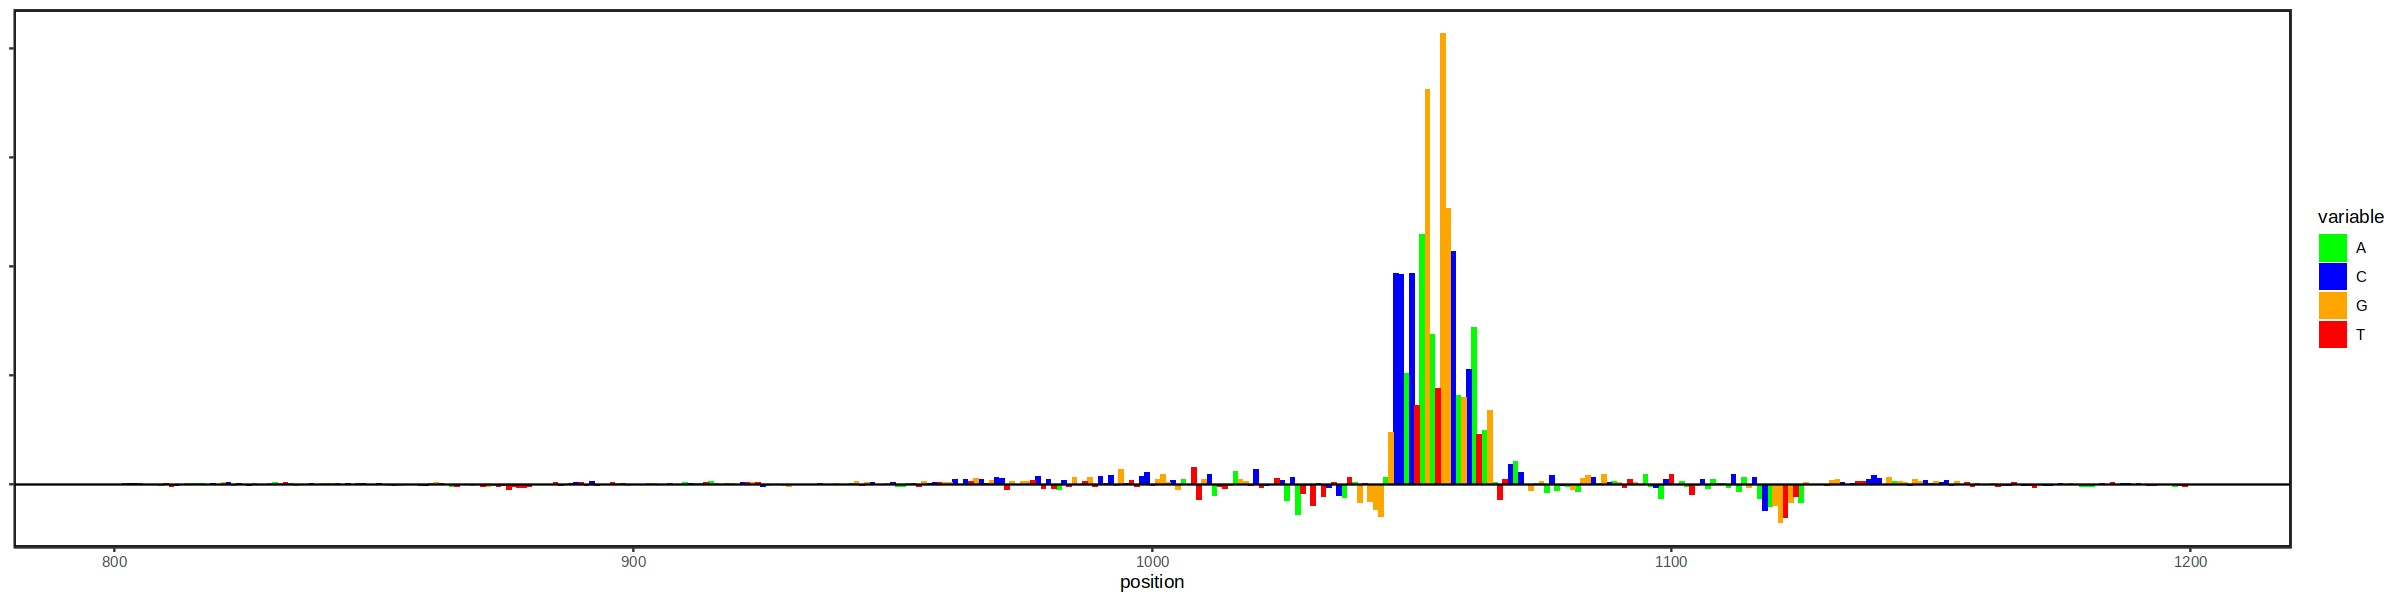

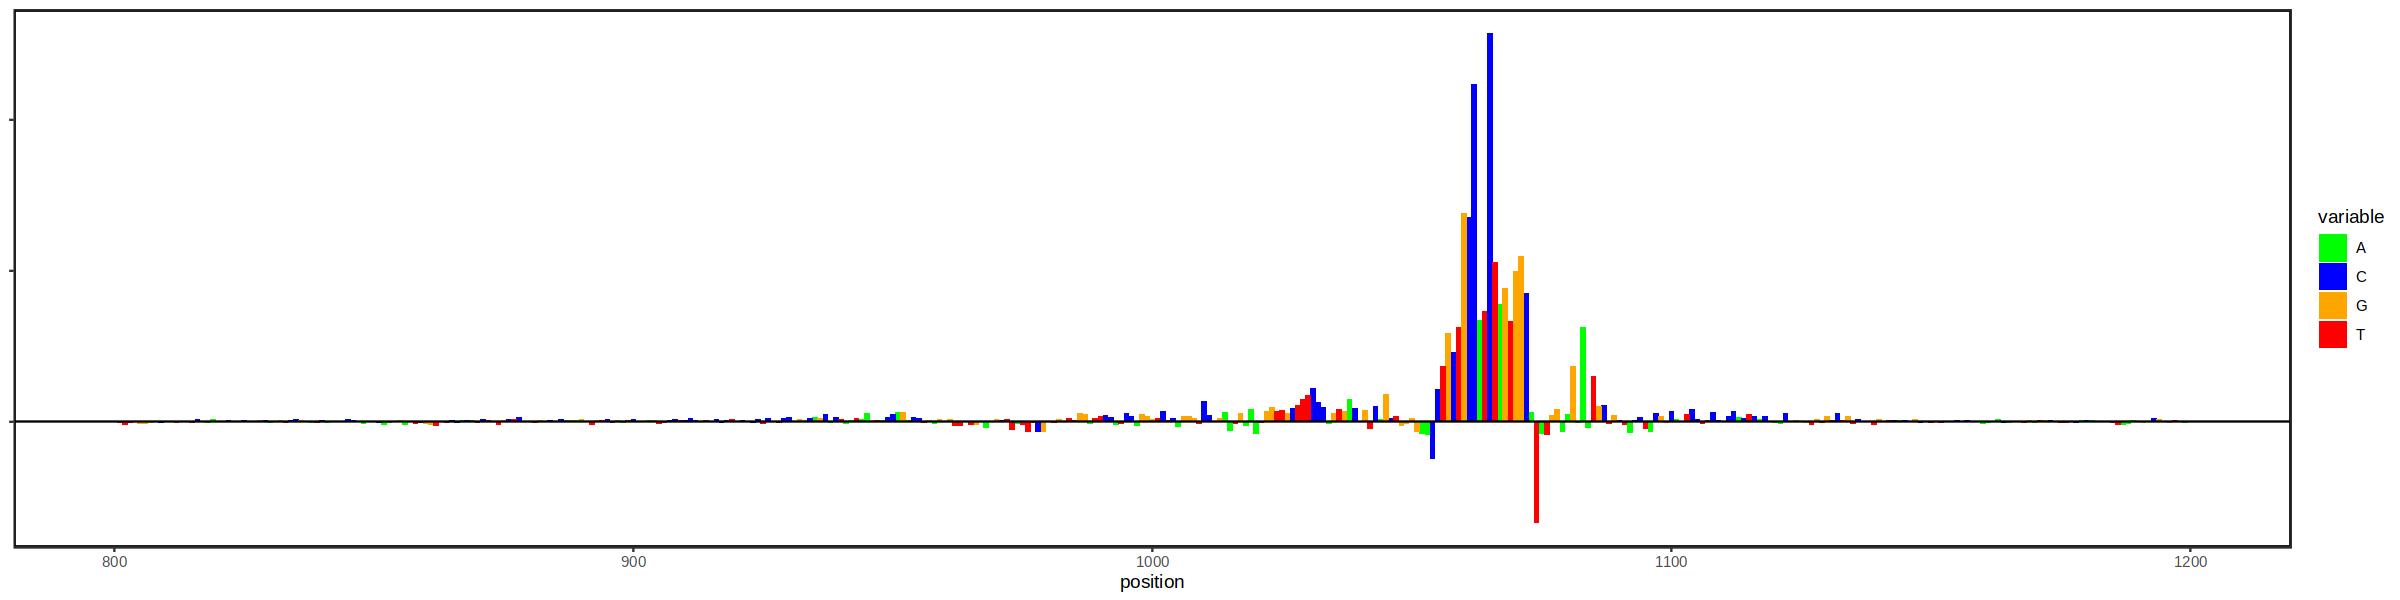

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]


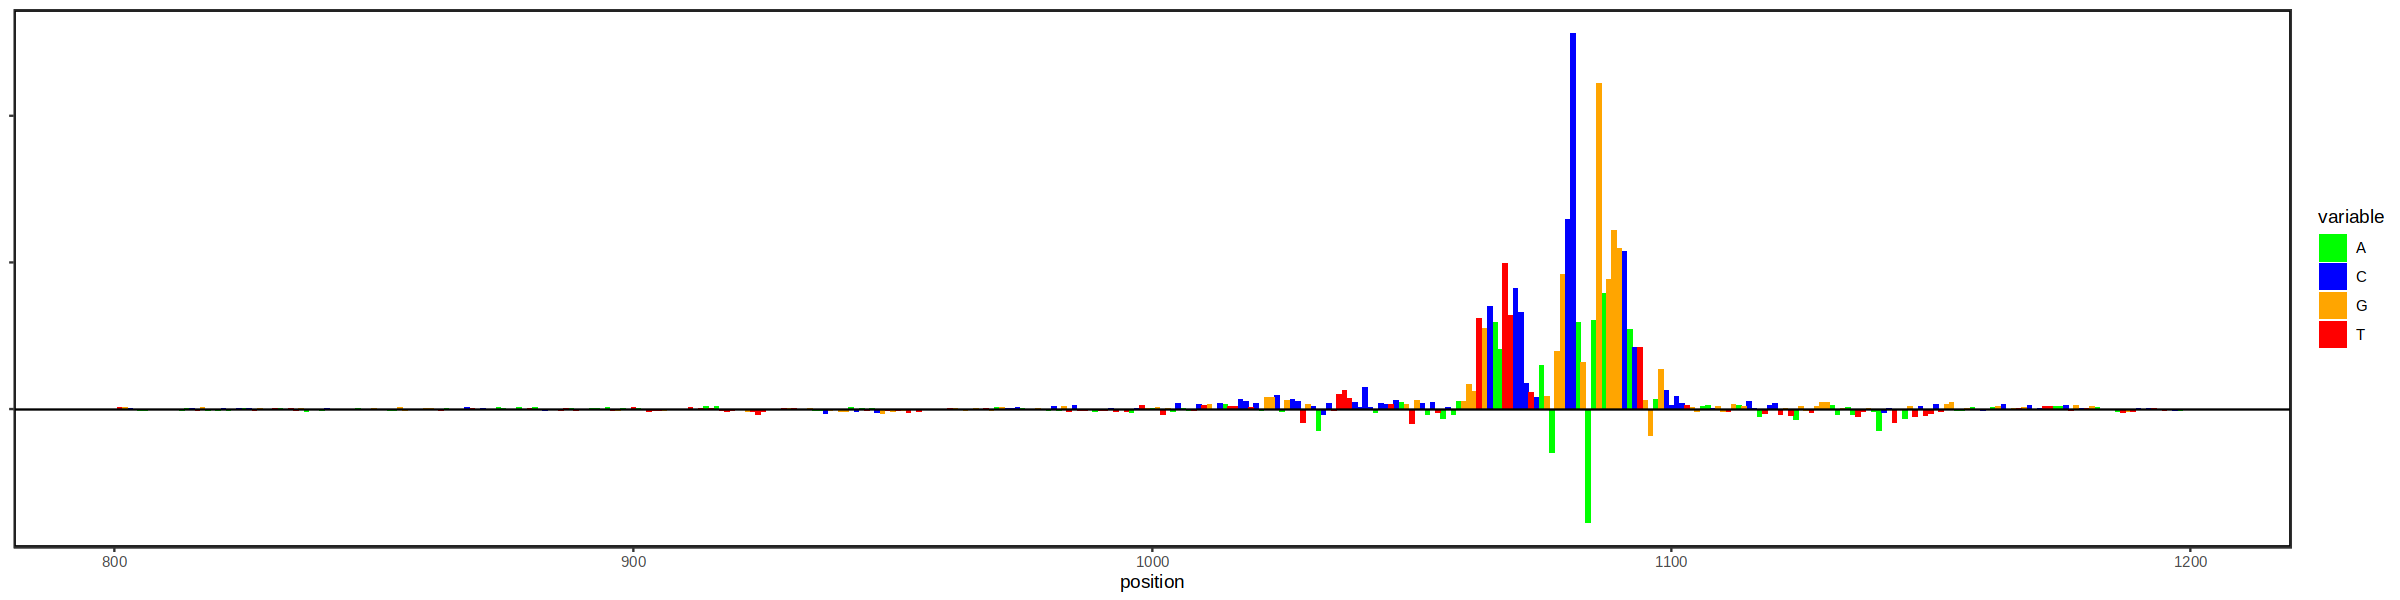

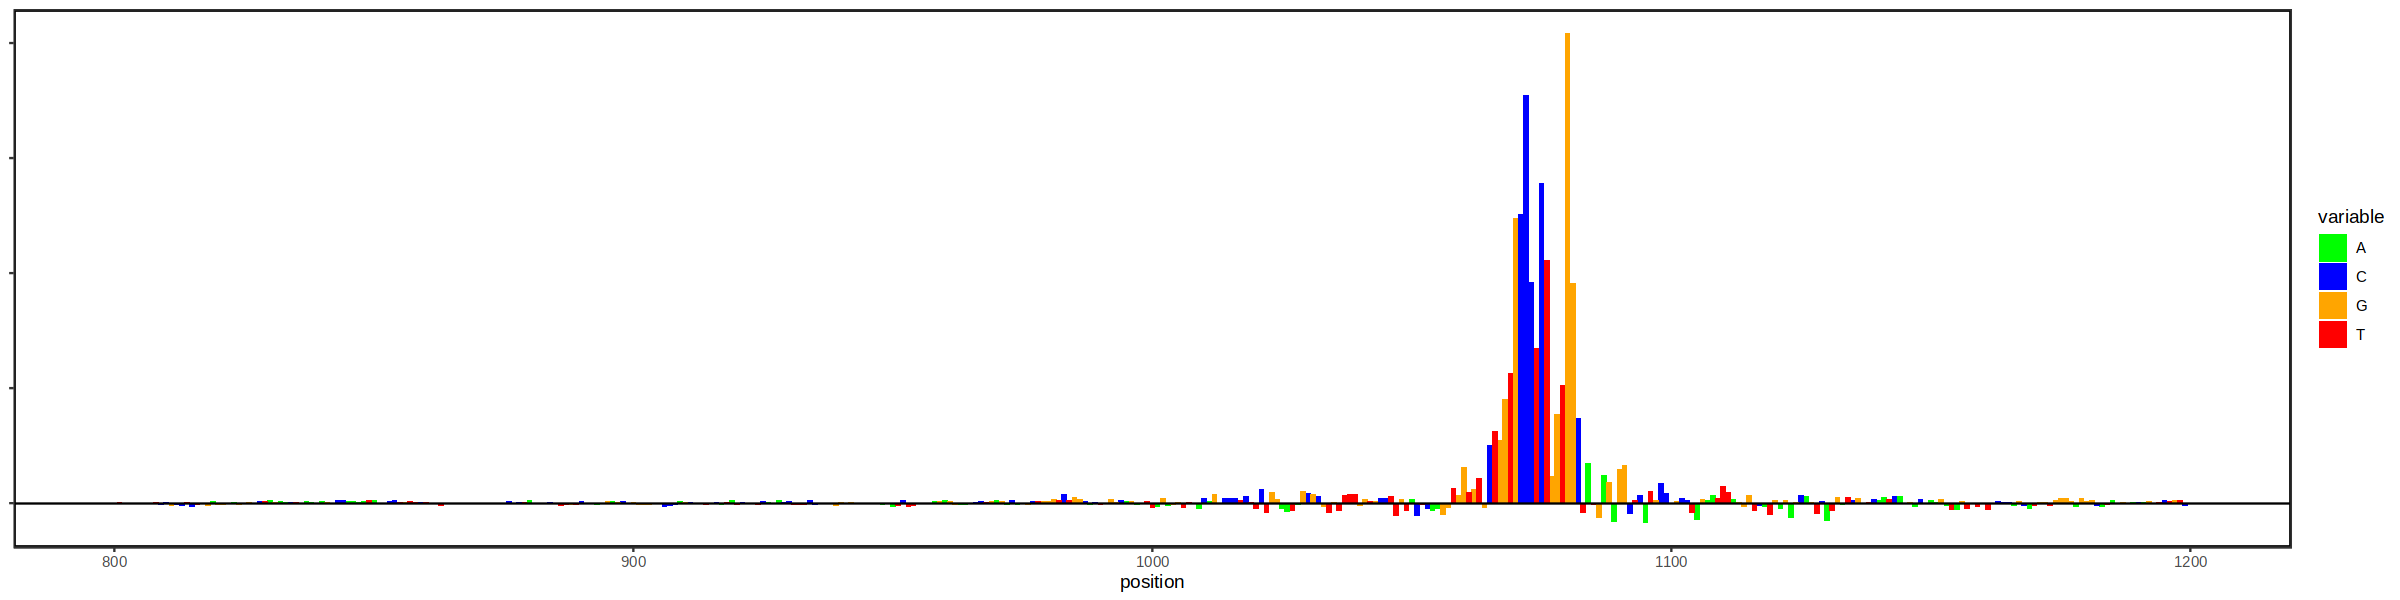

In [97]:
lapply(1:10, function(x){
row = boom[x,]$row

    test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]

    
genome = data.table(A = test[1:2114],
           C = test[2115:4228],
           G =  test[4229:6342],
           T =  test[6343:8456]
           ) %>%
    .[, position := .I] %>%
    melt(., id.vars = 'position') %>% 
    .[abs(value) > 0]

options(repr.plot.width = 20, repr.plot.height = 5)
genome = genome[position > 800 & position < 1200]
ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_blank(),
         axis.title.y = element_blank())
})

In [119]:
boom = mclapply(1:30000, function(x){
    test = mydata[(2114 * (x*4) + 1 ): (2114 * (x * 4) + 2114*4)]
    tmp = data.table(row = x,
                     max = mean(test))
                     
    return(tmp)
}, mc.cores = 24) %>% rbindlist() %>%
    .[order(-max)]
    
    

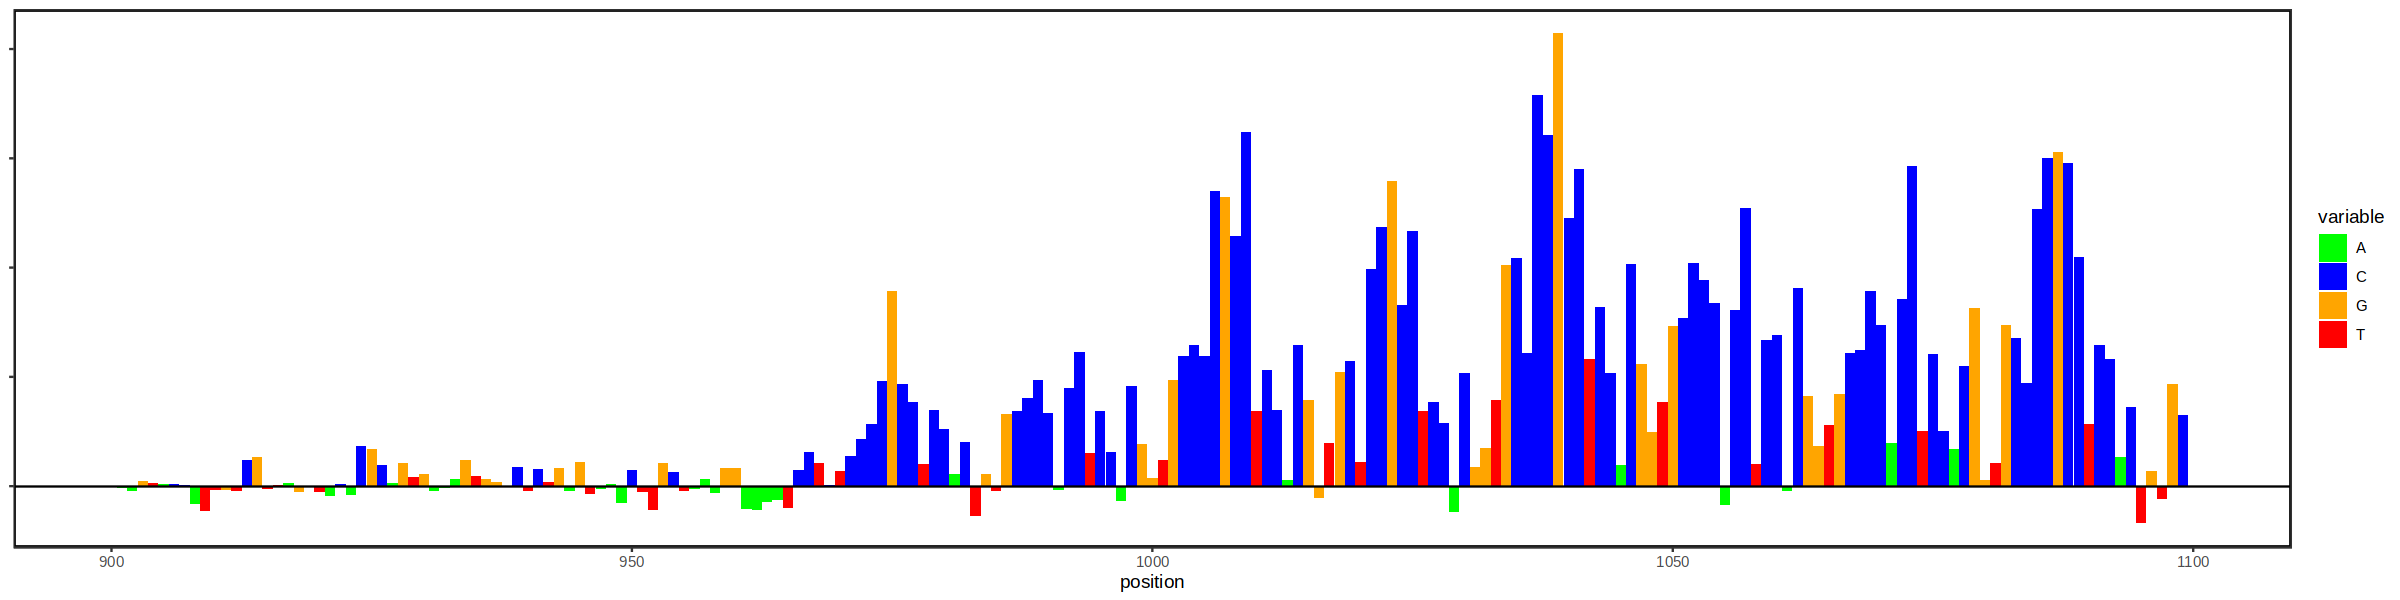

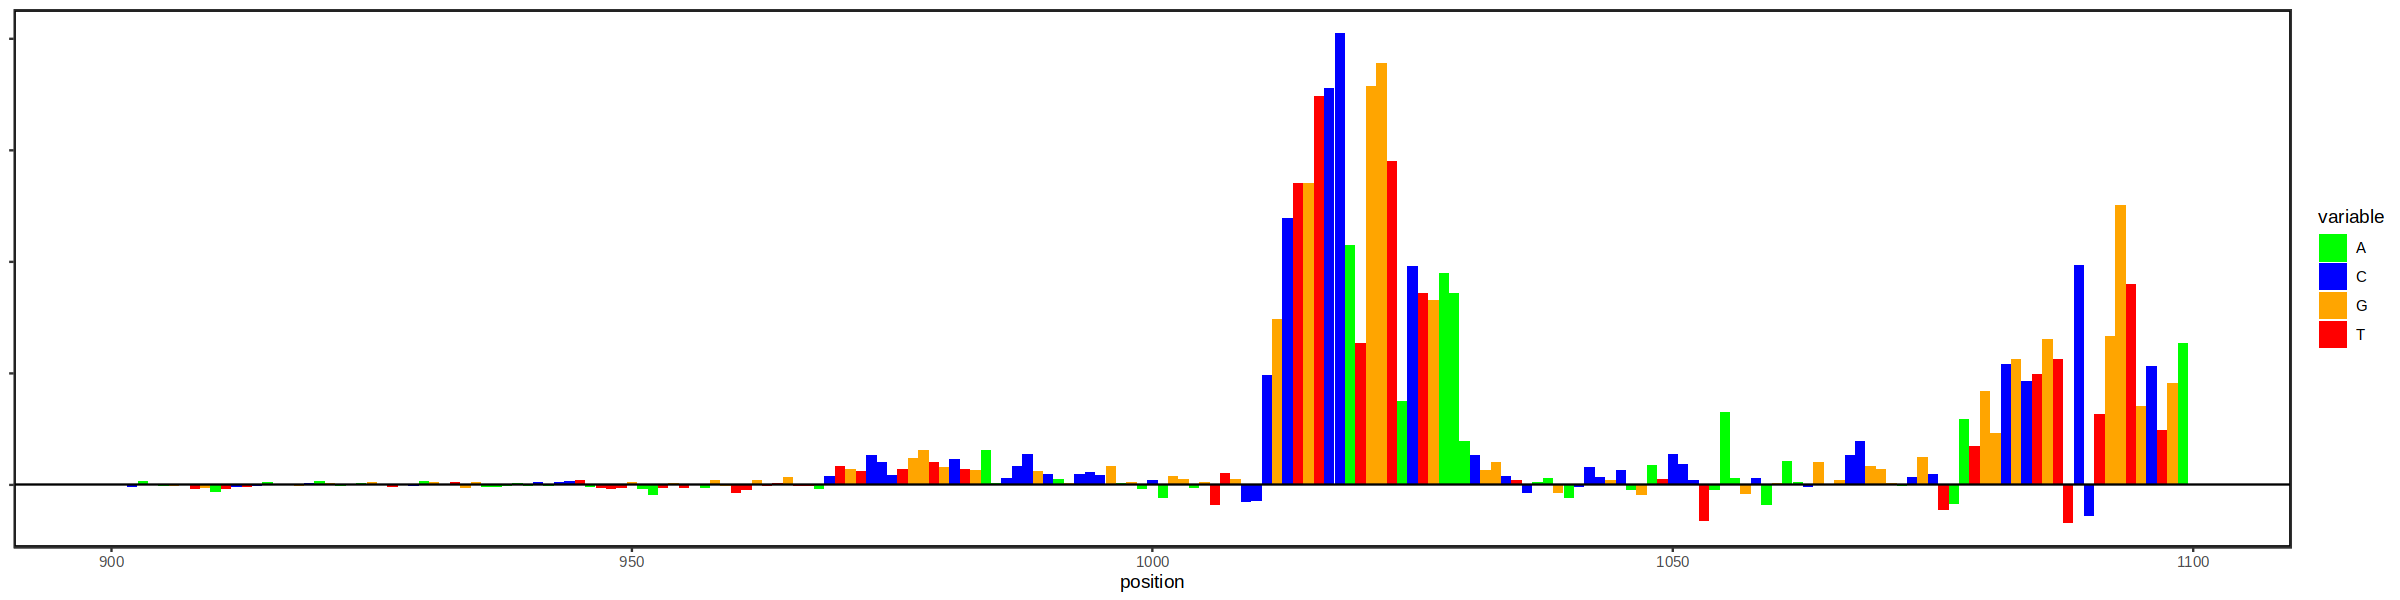

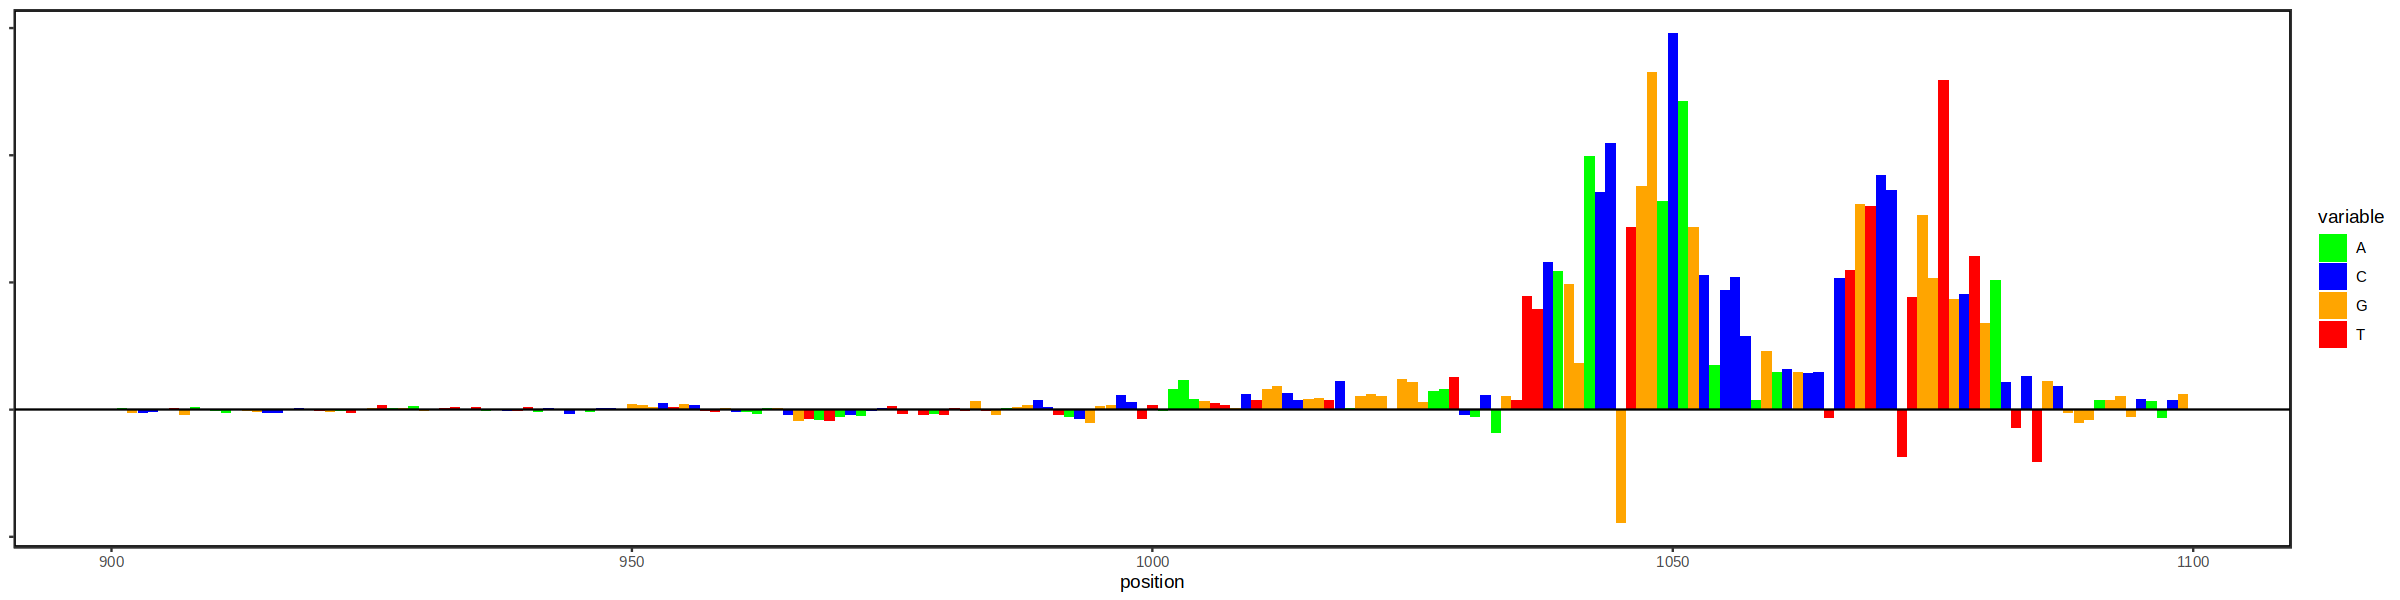

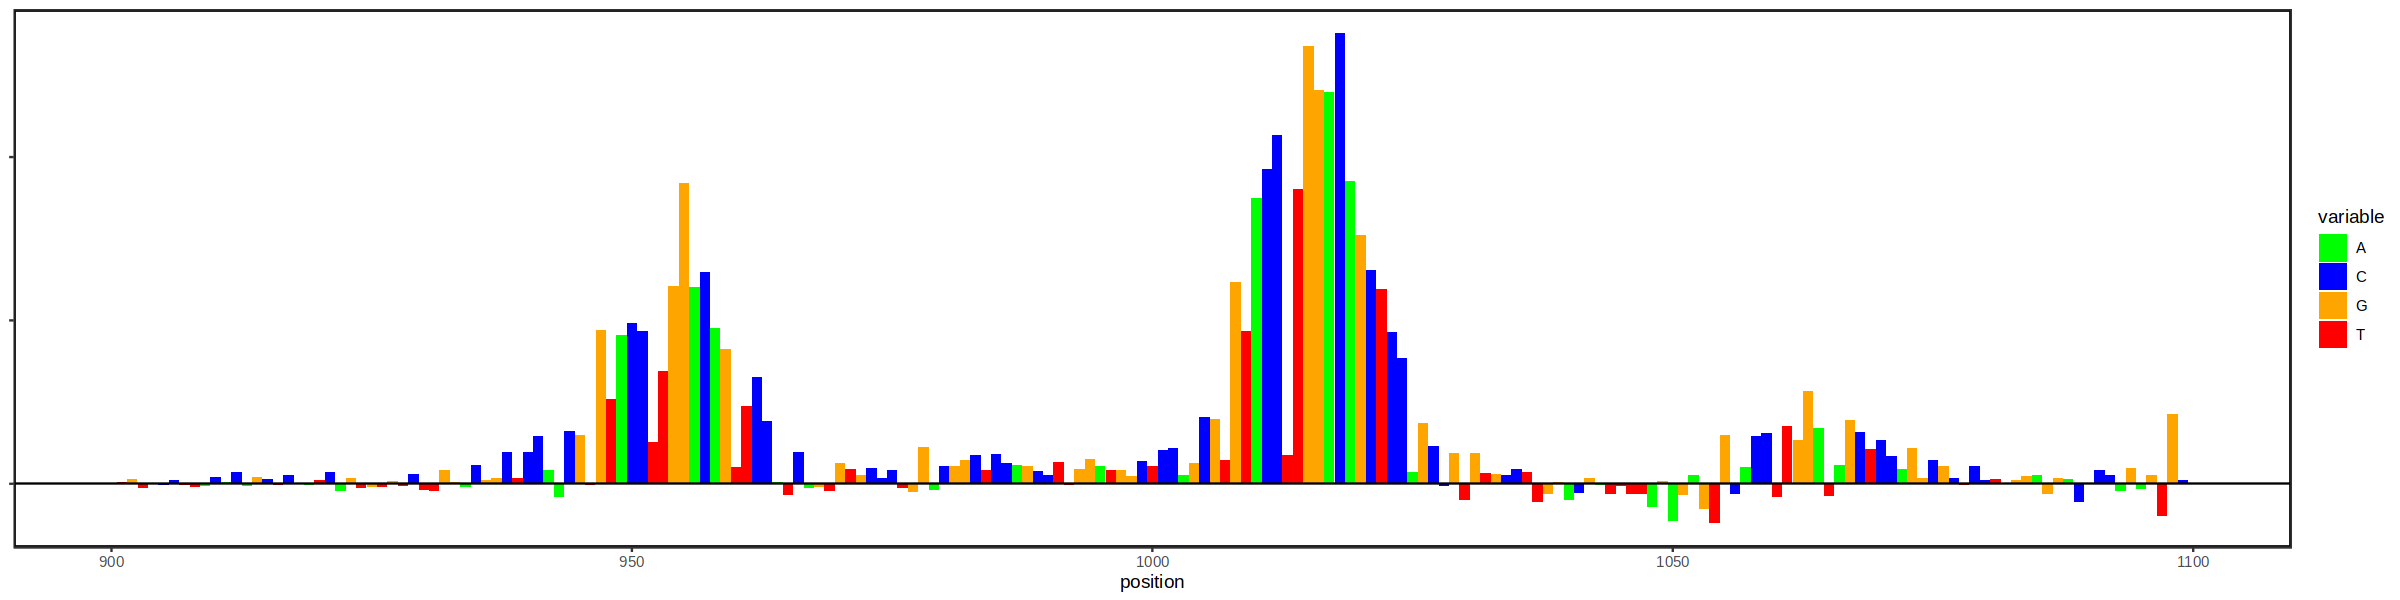

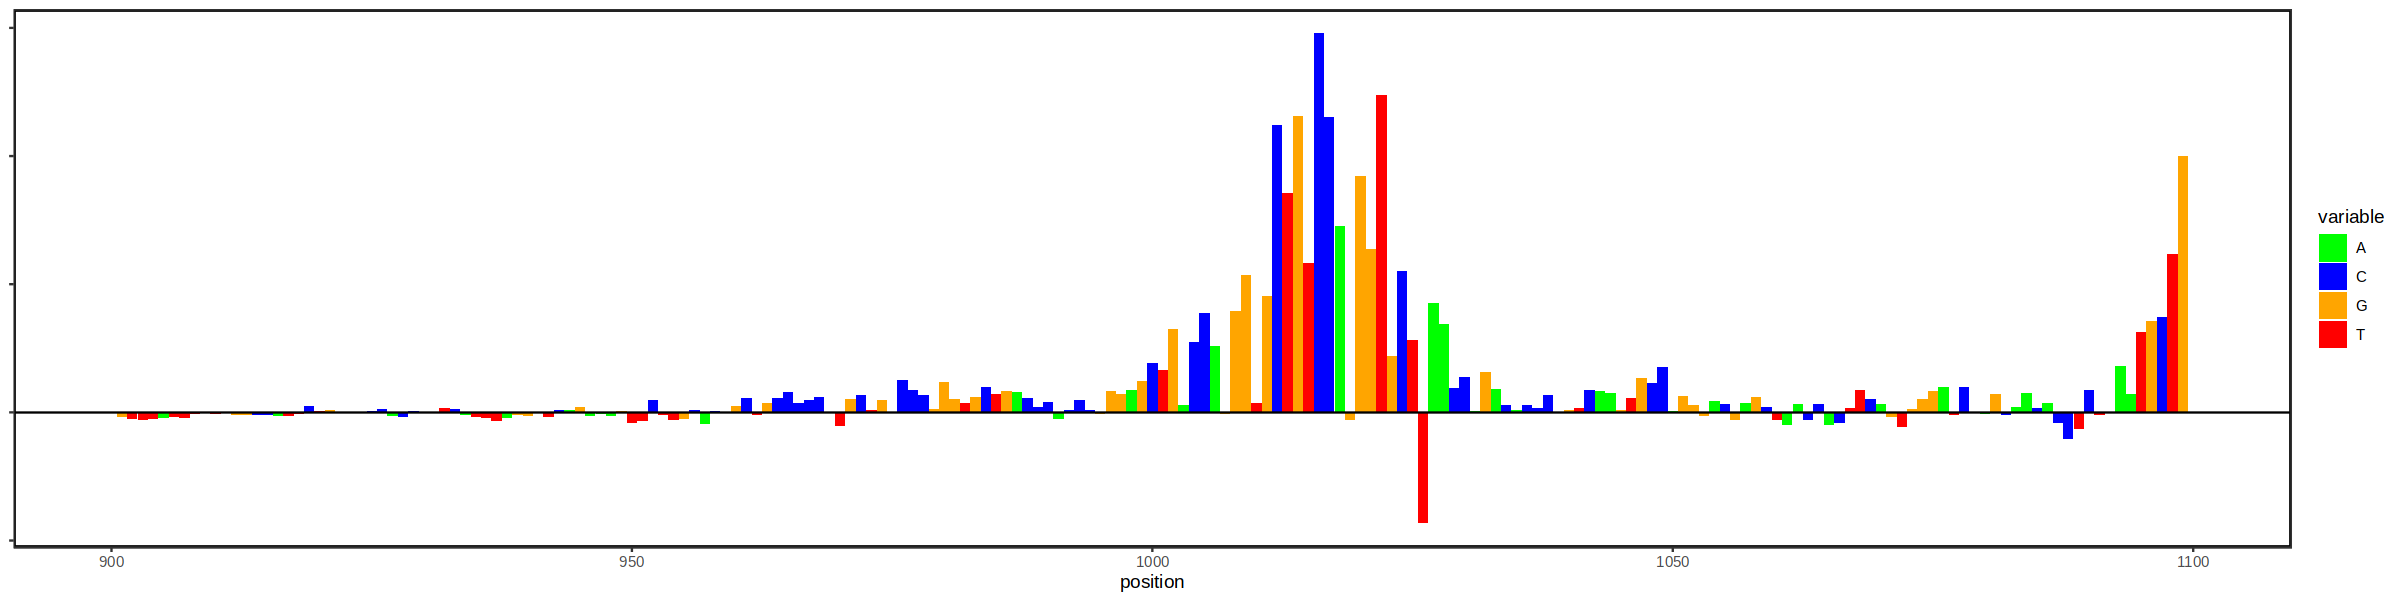

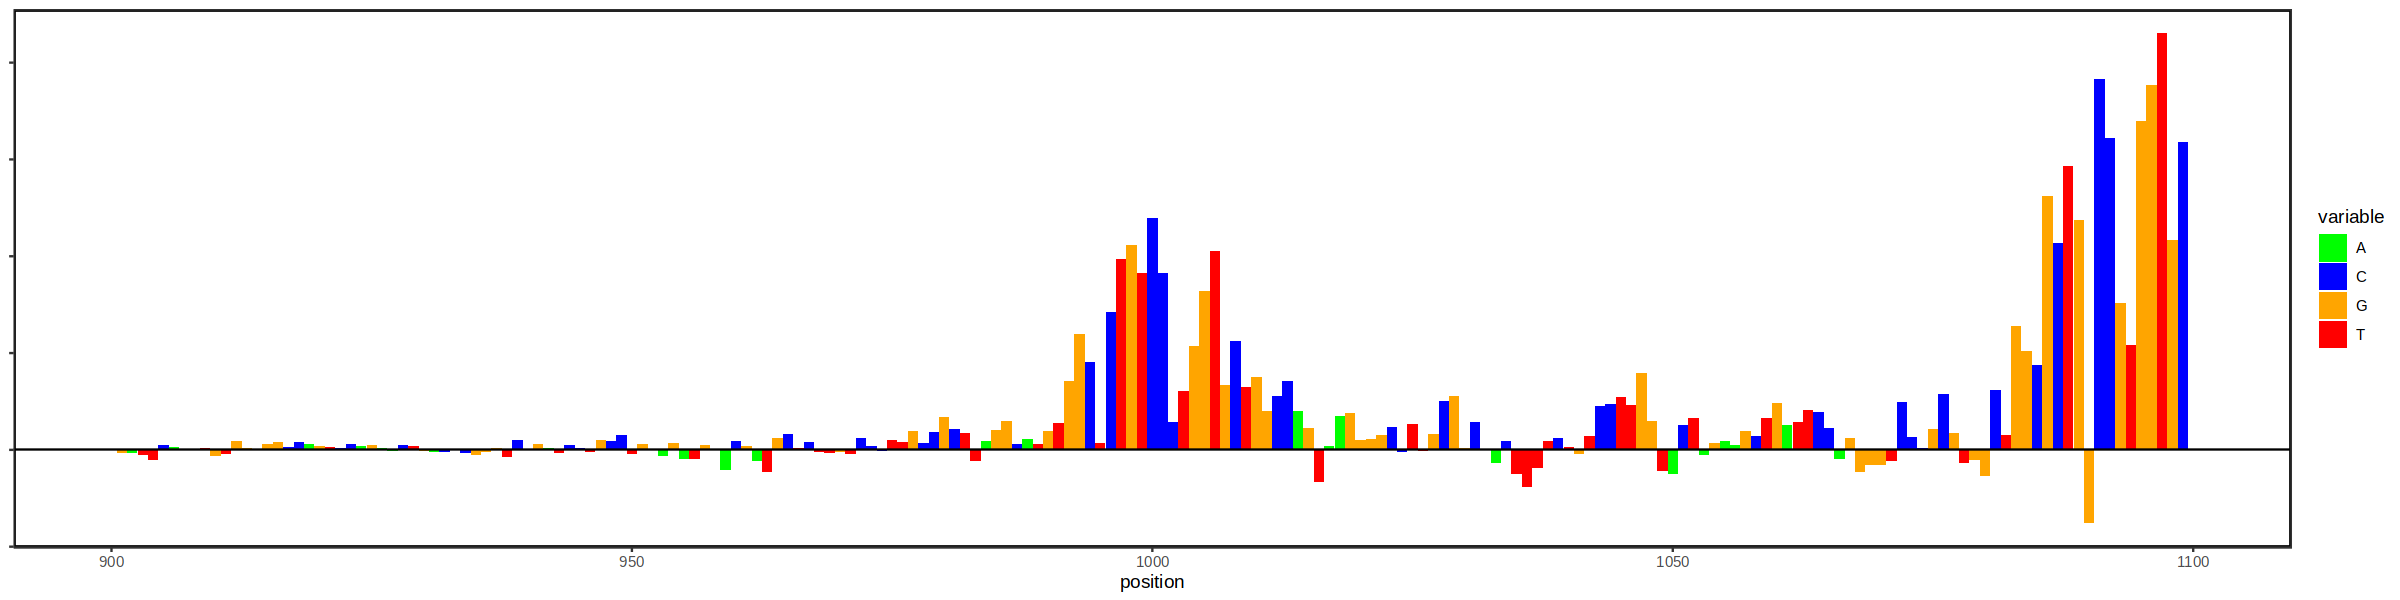

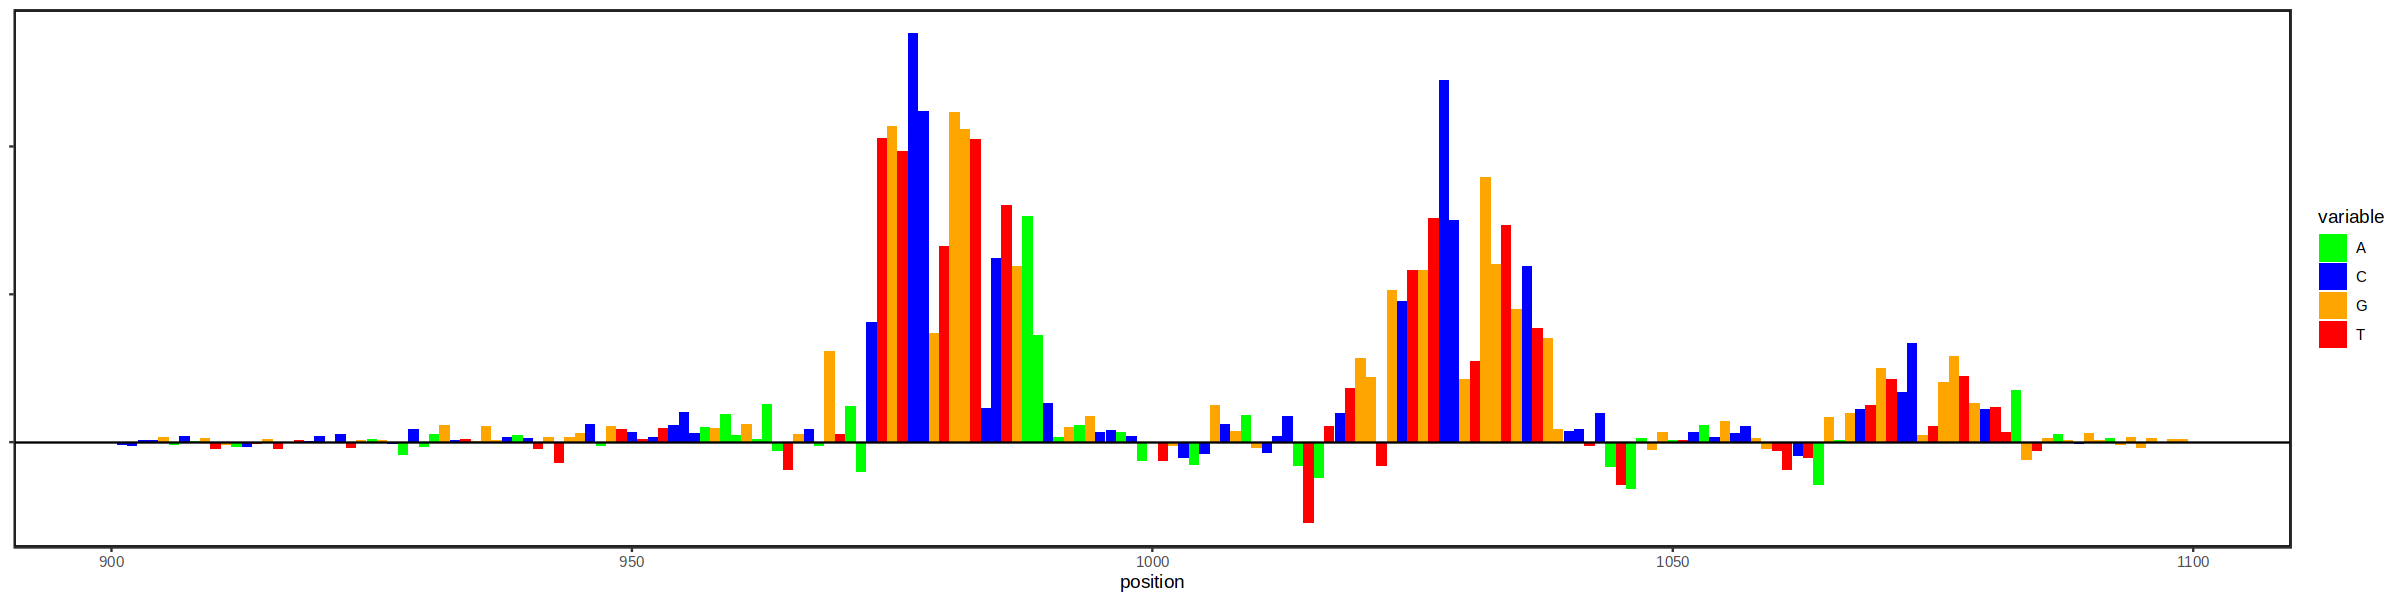

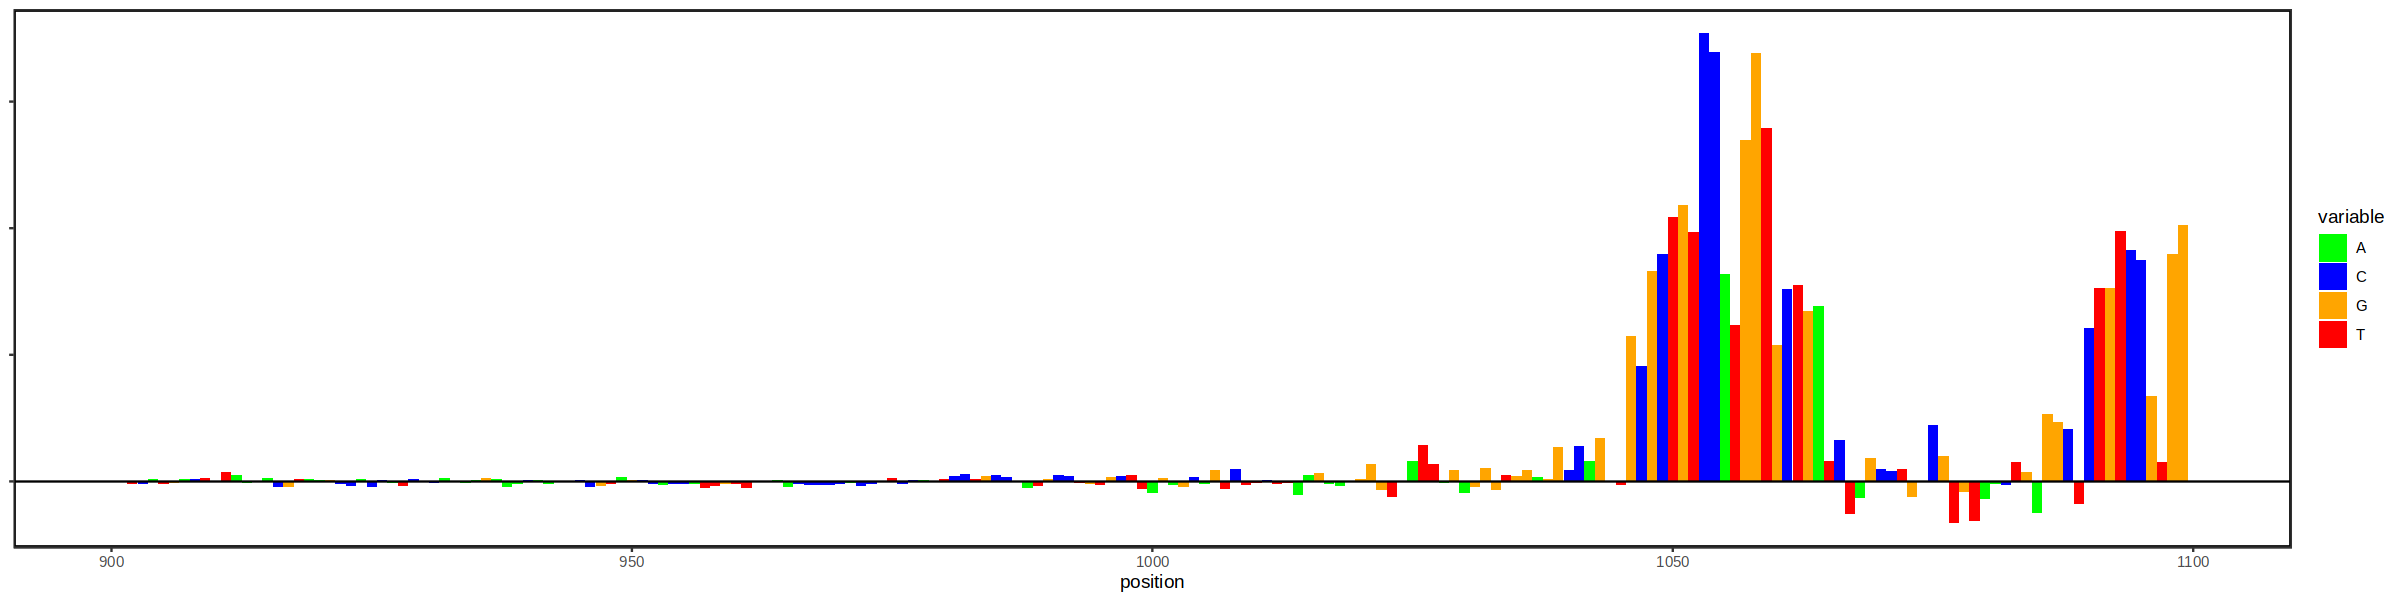

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]


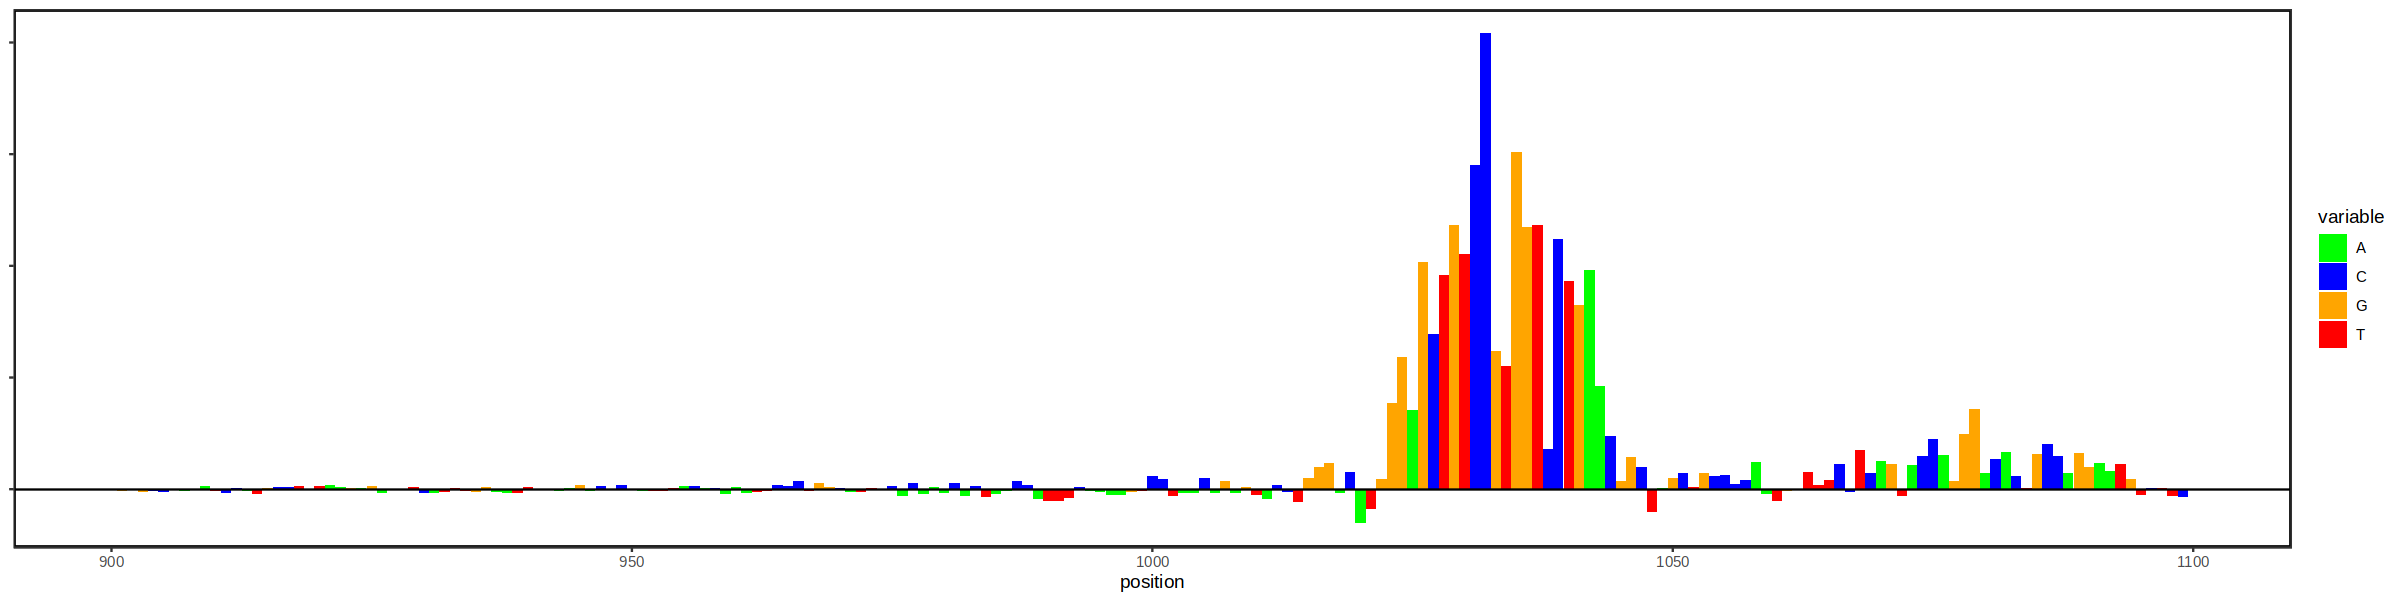

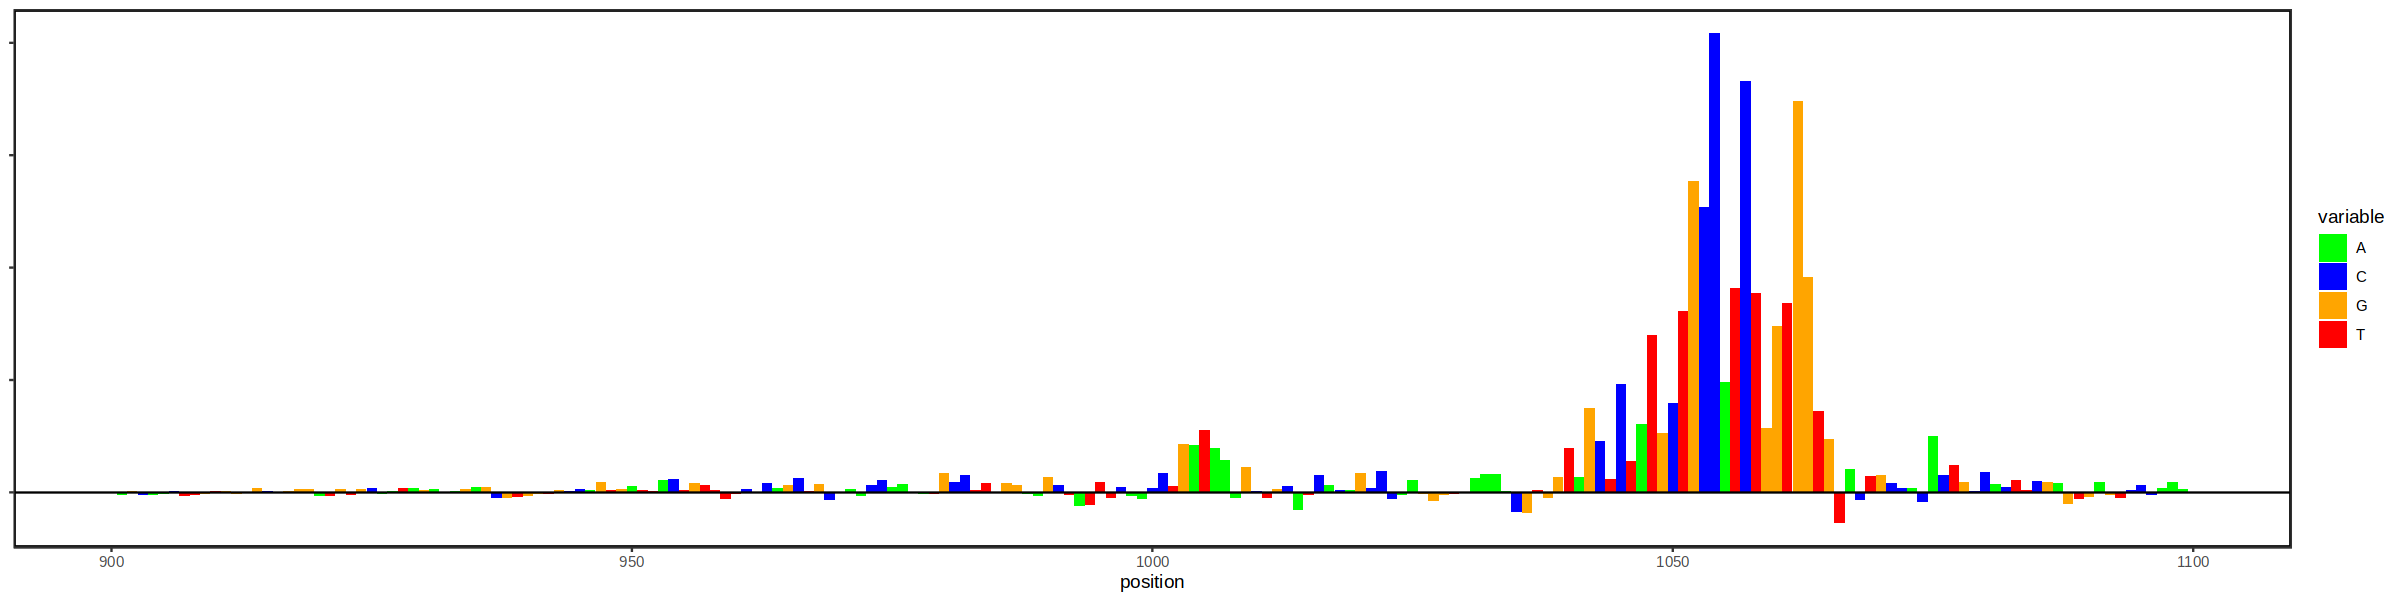

In [120]:
lapply(1:10, function(x){
row = boom[x,]$row

    test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]

    
genome = data.table(A = test[1:2114],
           C = test[2115:4228],
           G =  test[4229:6342],
           T =  test[6343:8456]
           ) %>%
    .[, position := .I] %>%
    melt(., id.vars = 'position') %>% 
    .[abs(value) > 0]

options(repr.plot.width = 20, repr.plot.height = 5)
genome = genome[position > 900 & position < 1100]
ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_blank(),
         axis.title.y = element_blank())
})

In [ ]:
tgtccgtggt

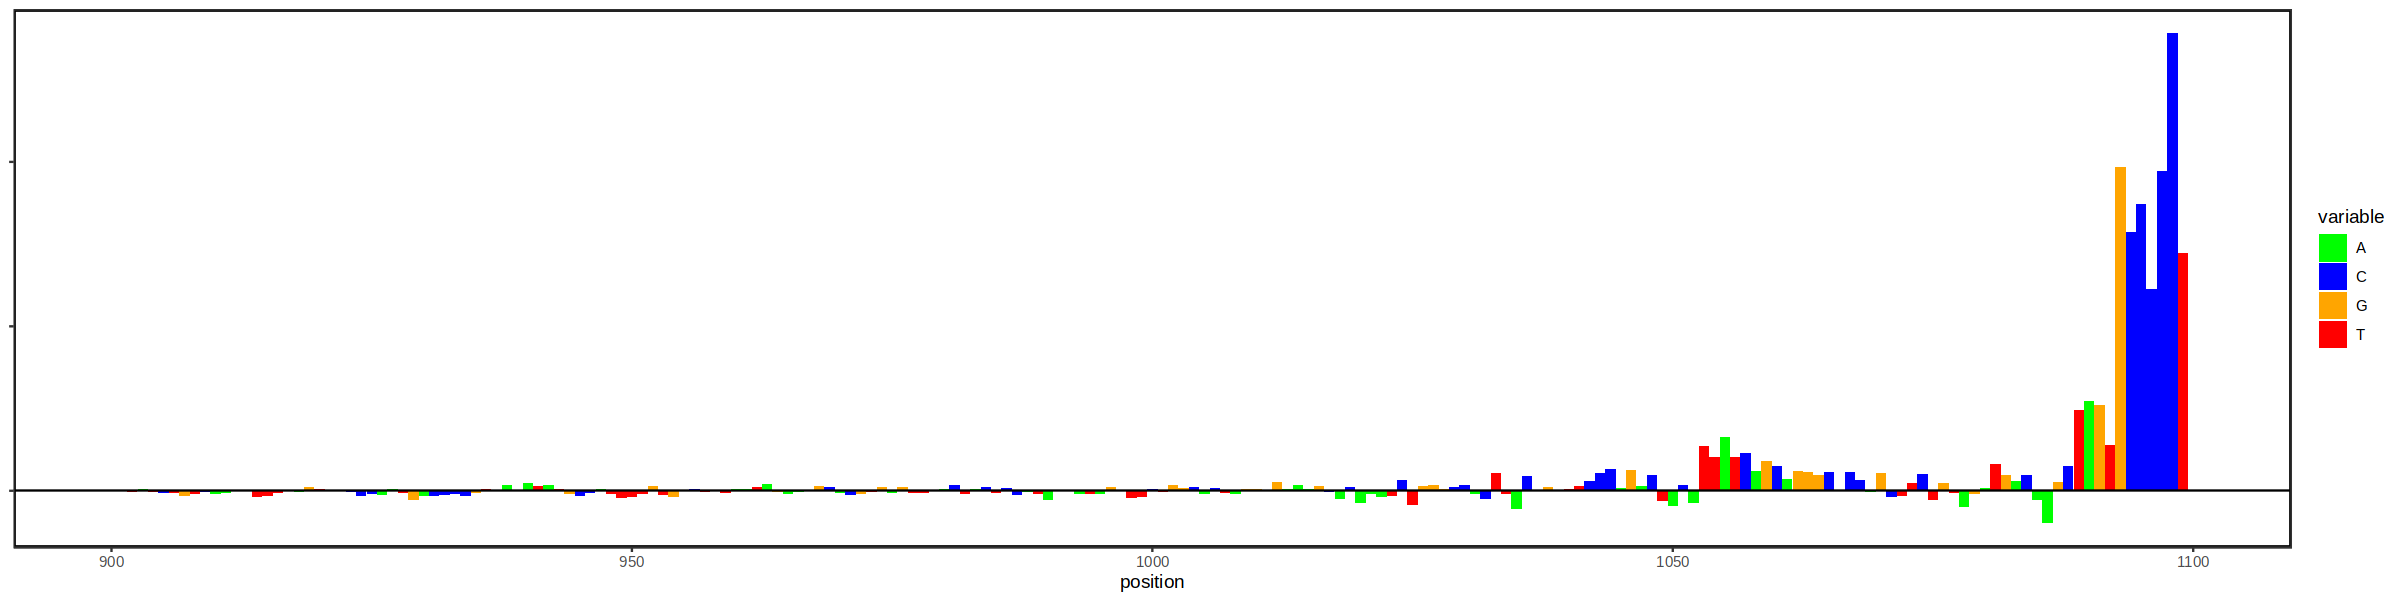

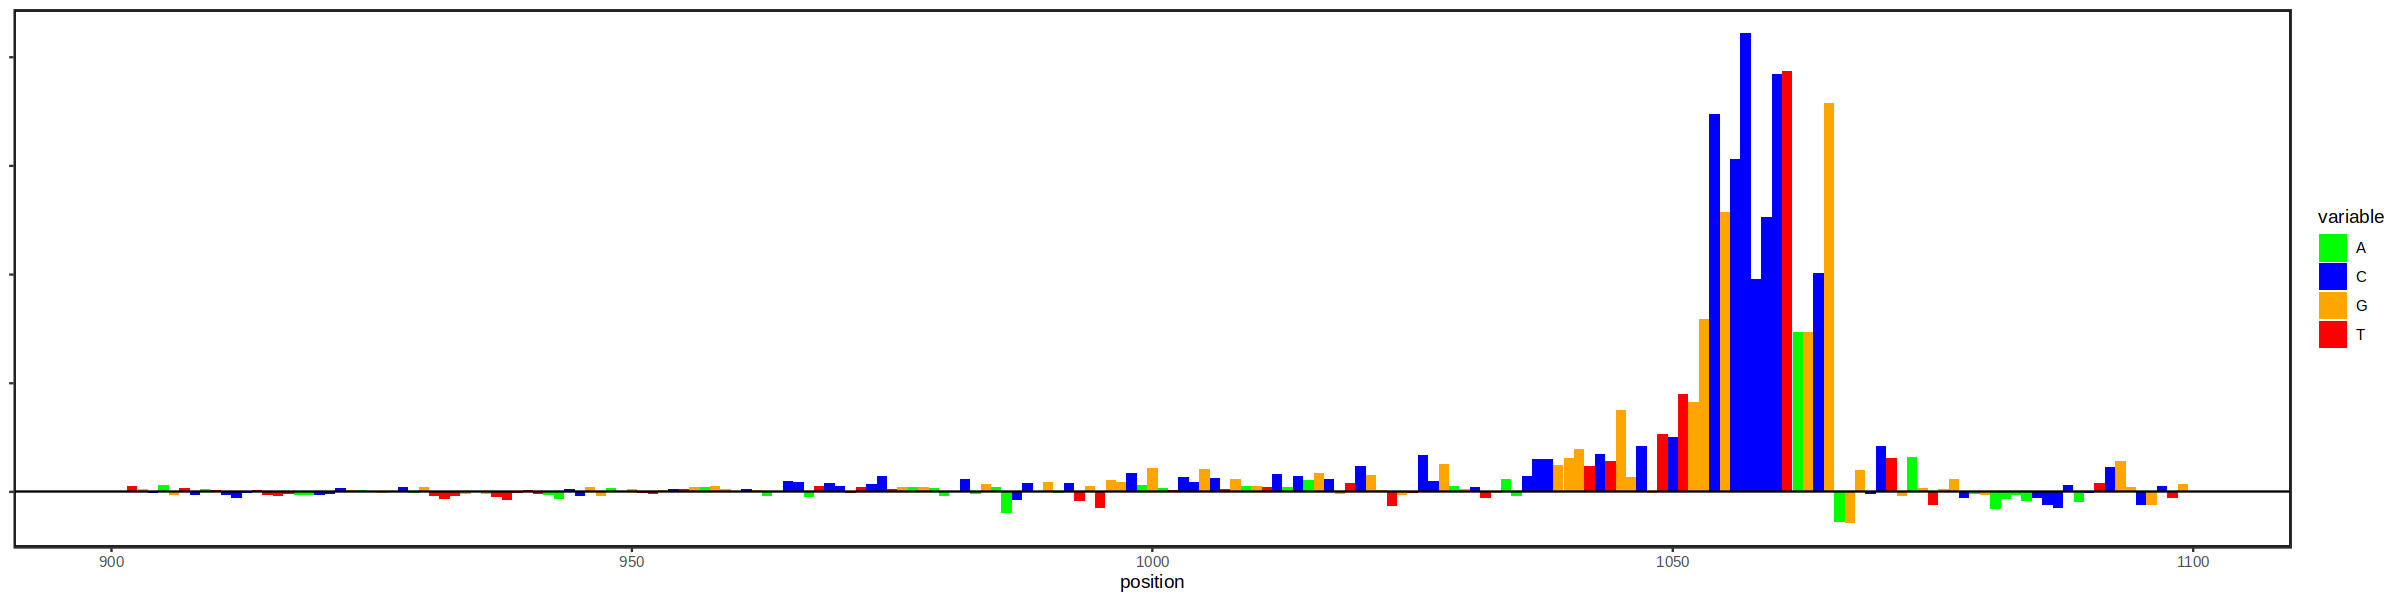

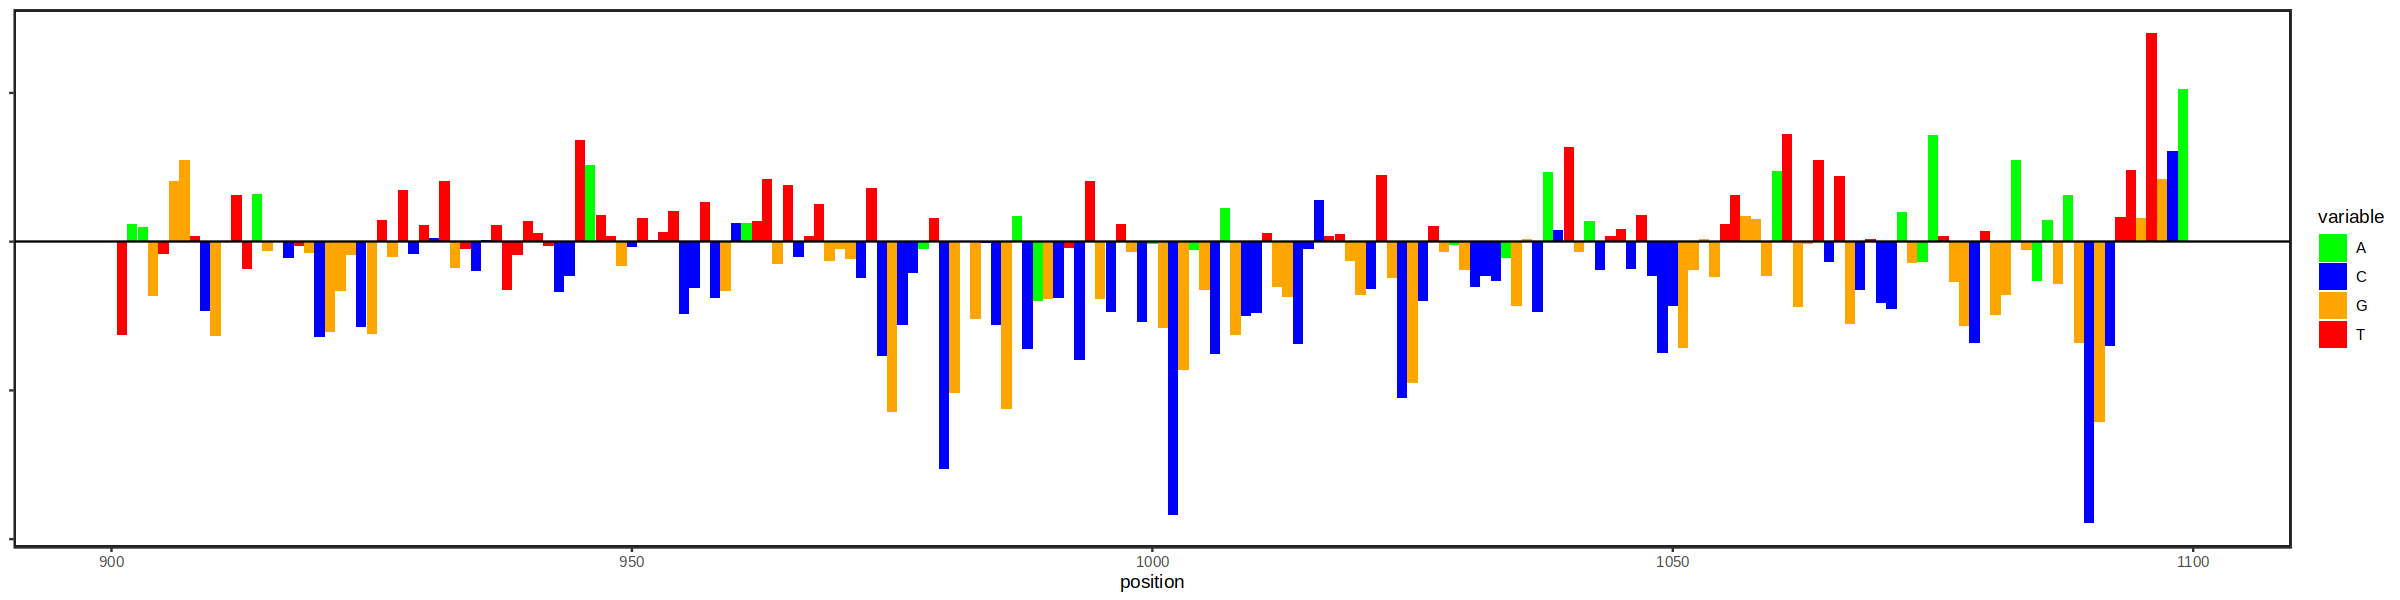

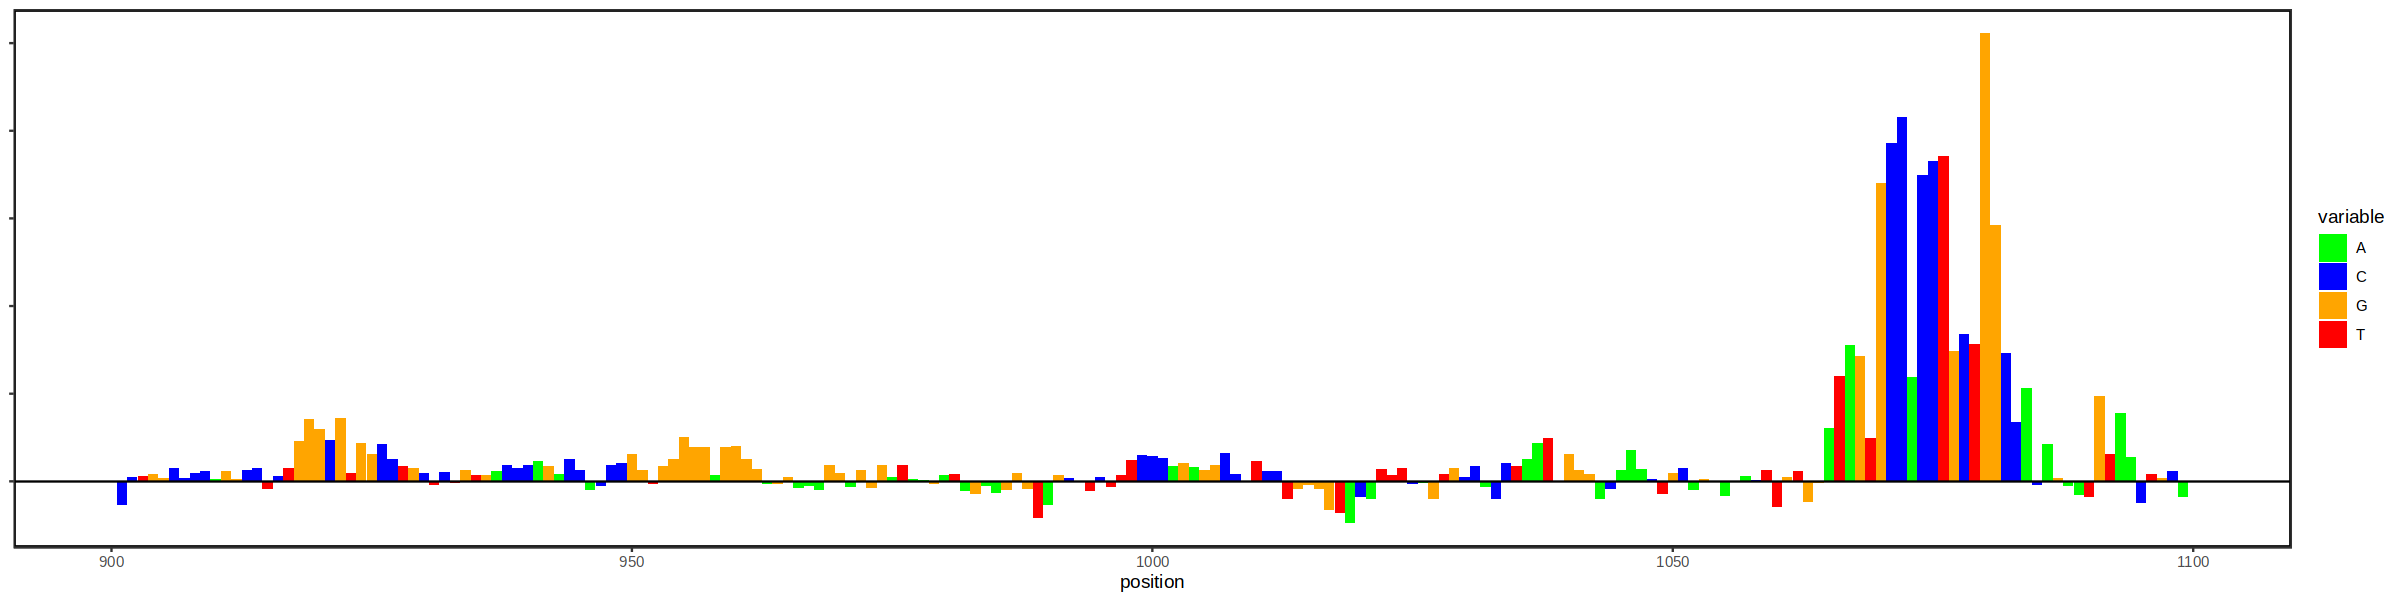

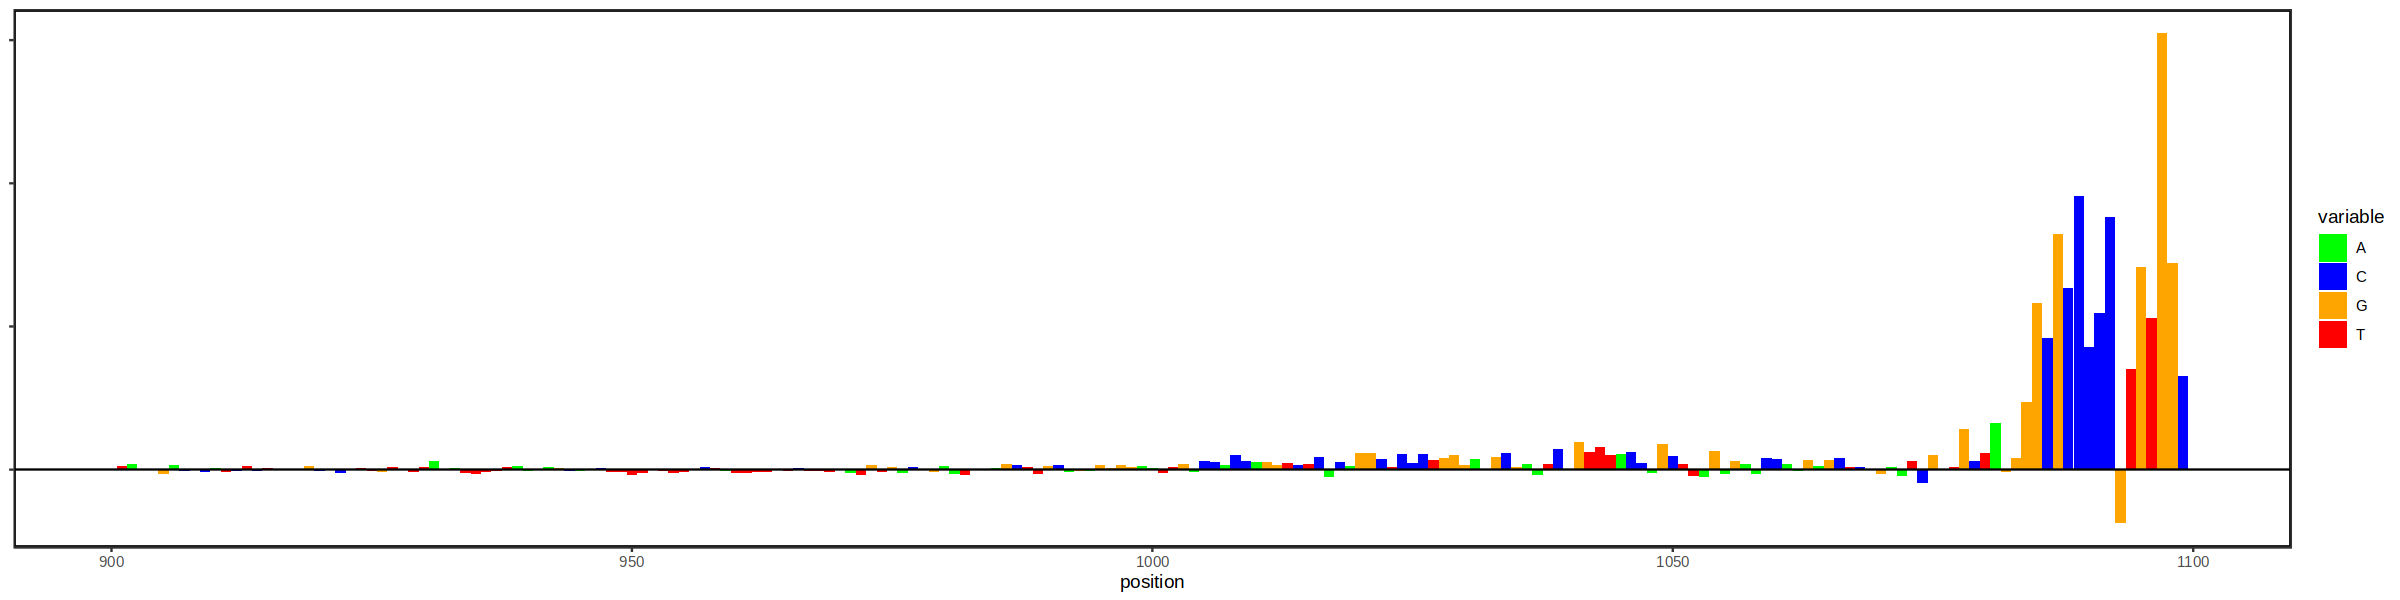

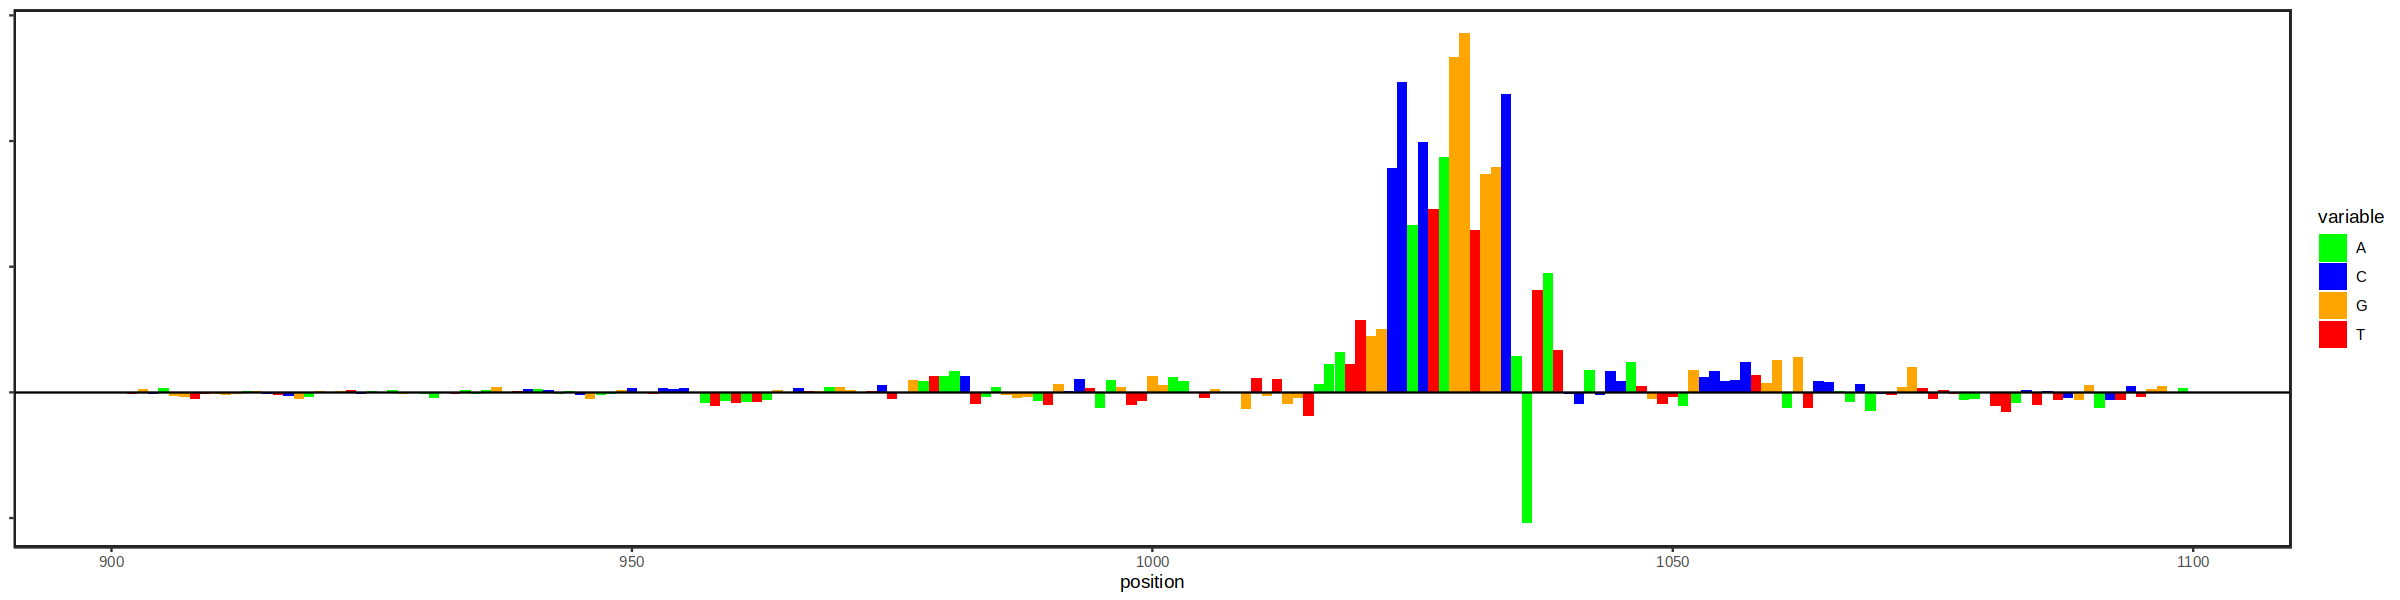

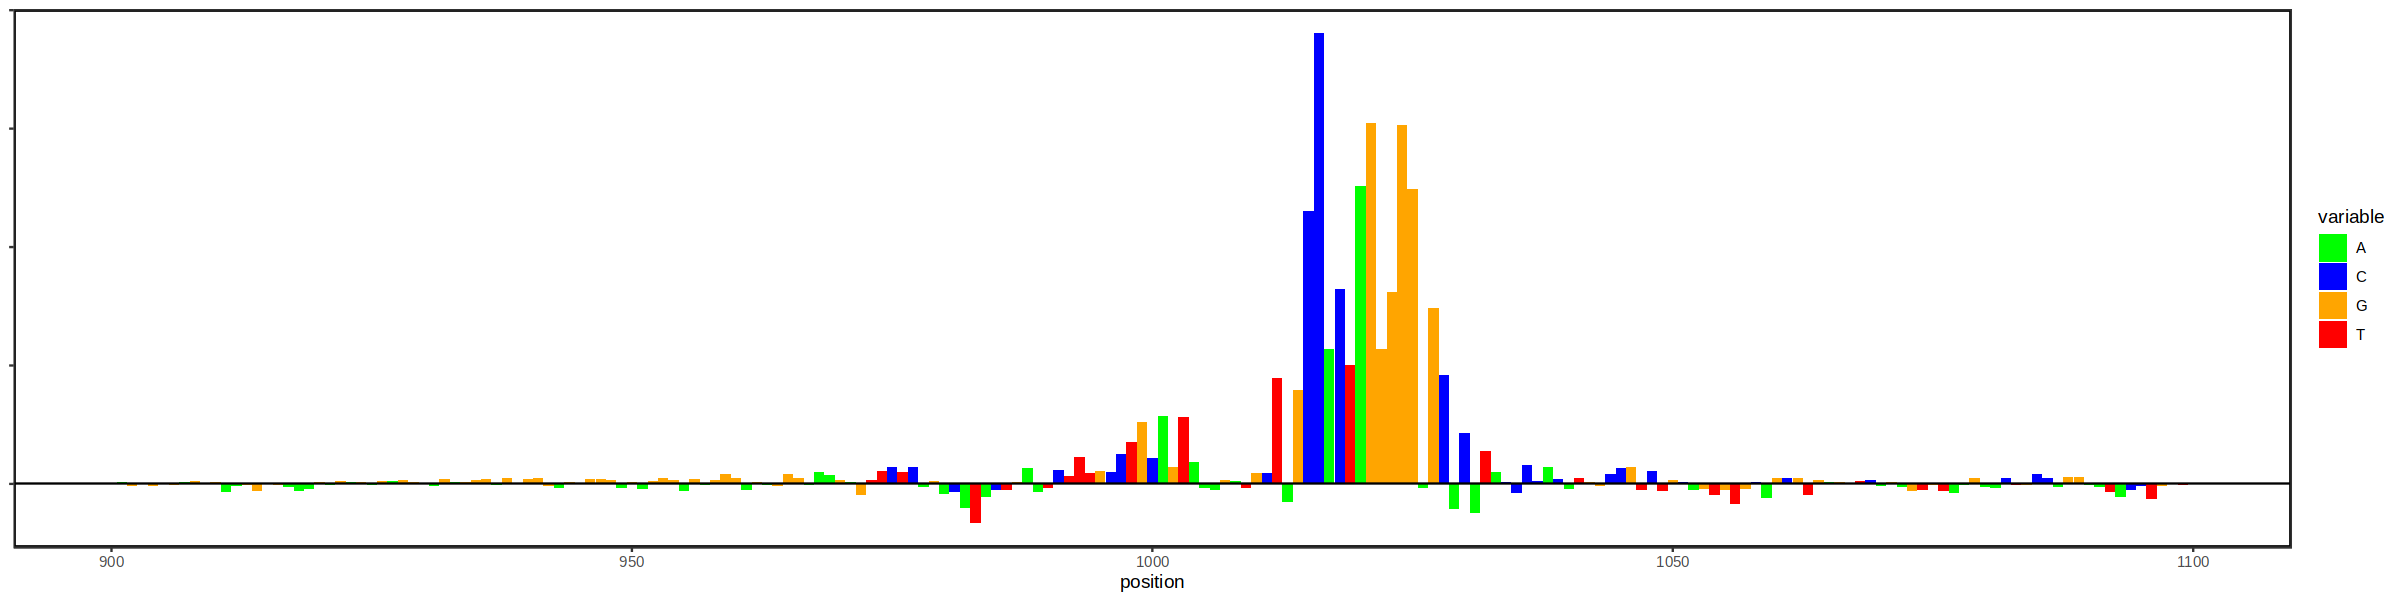

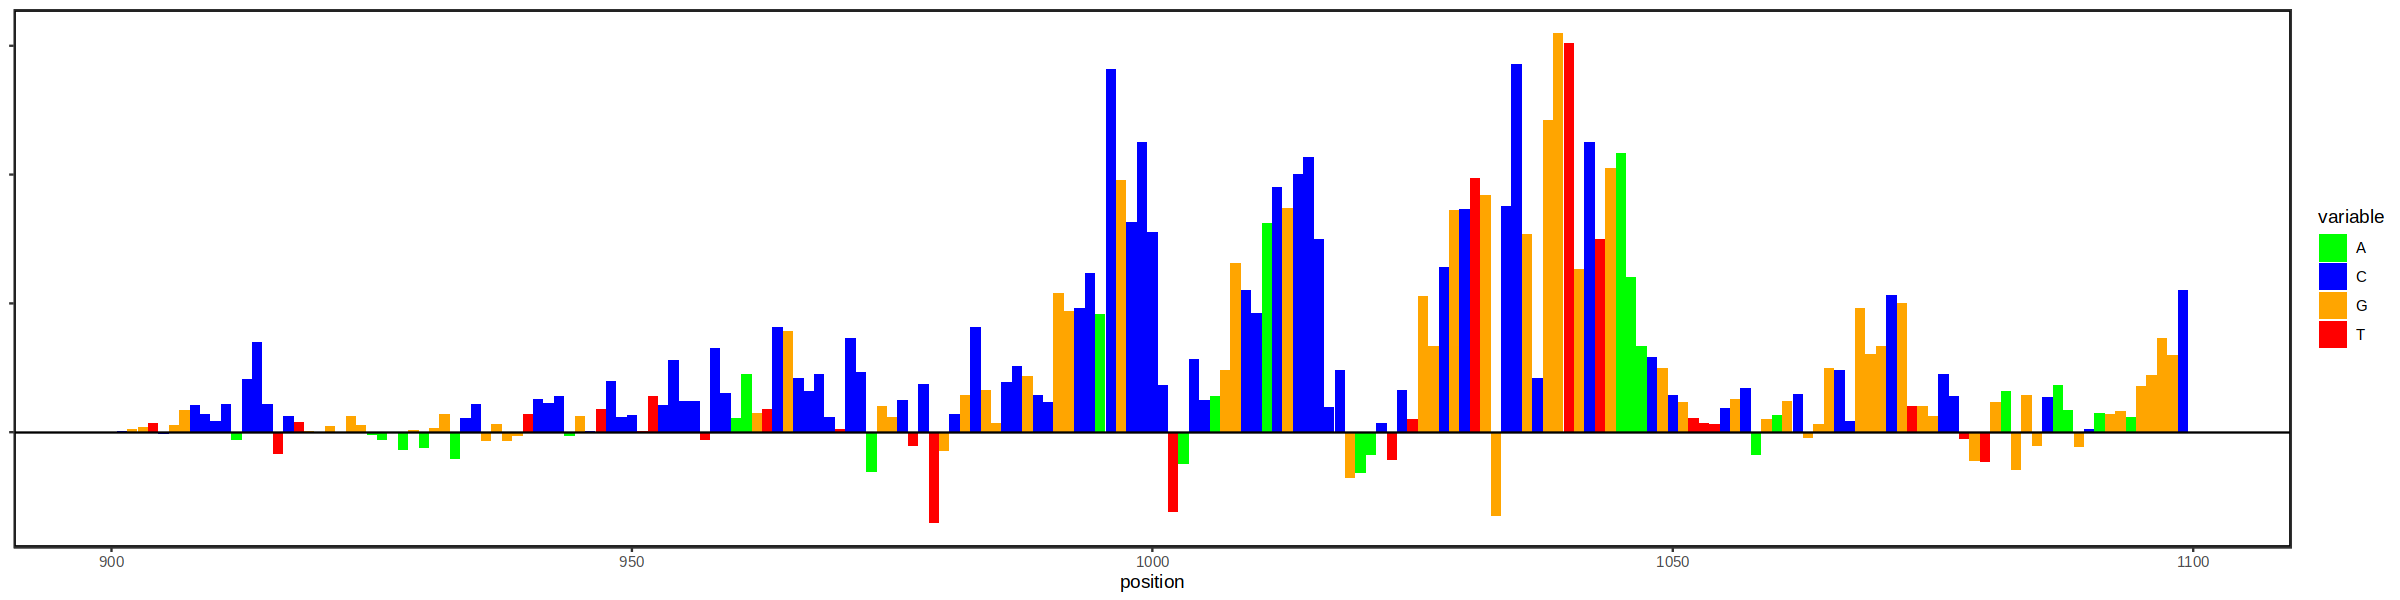

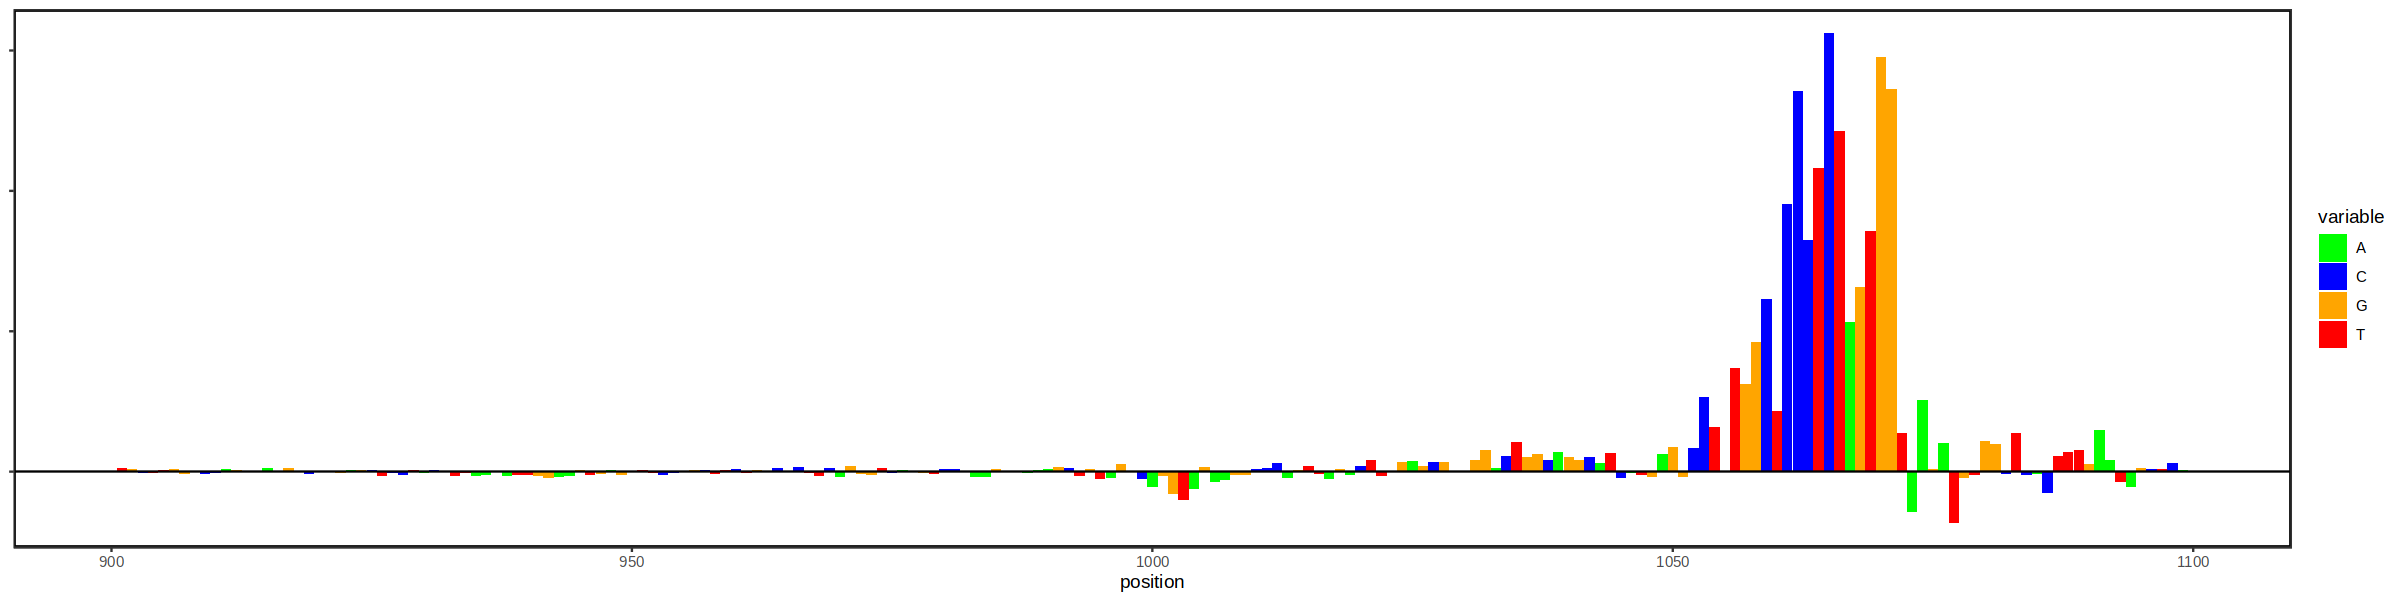

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]

[[11]]


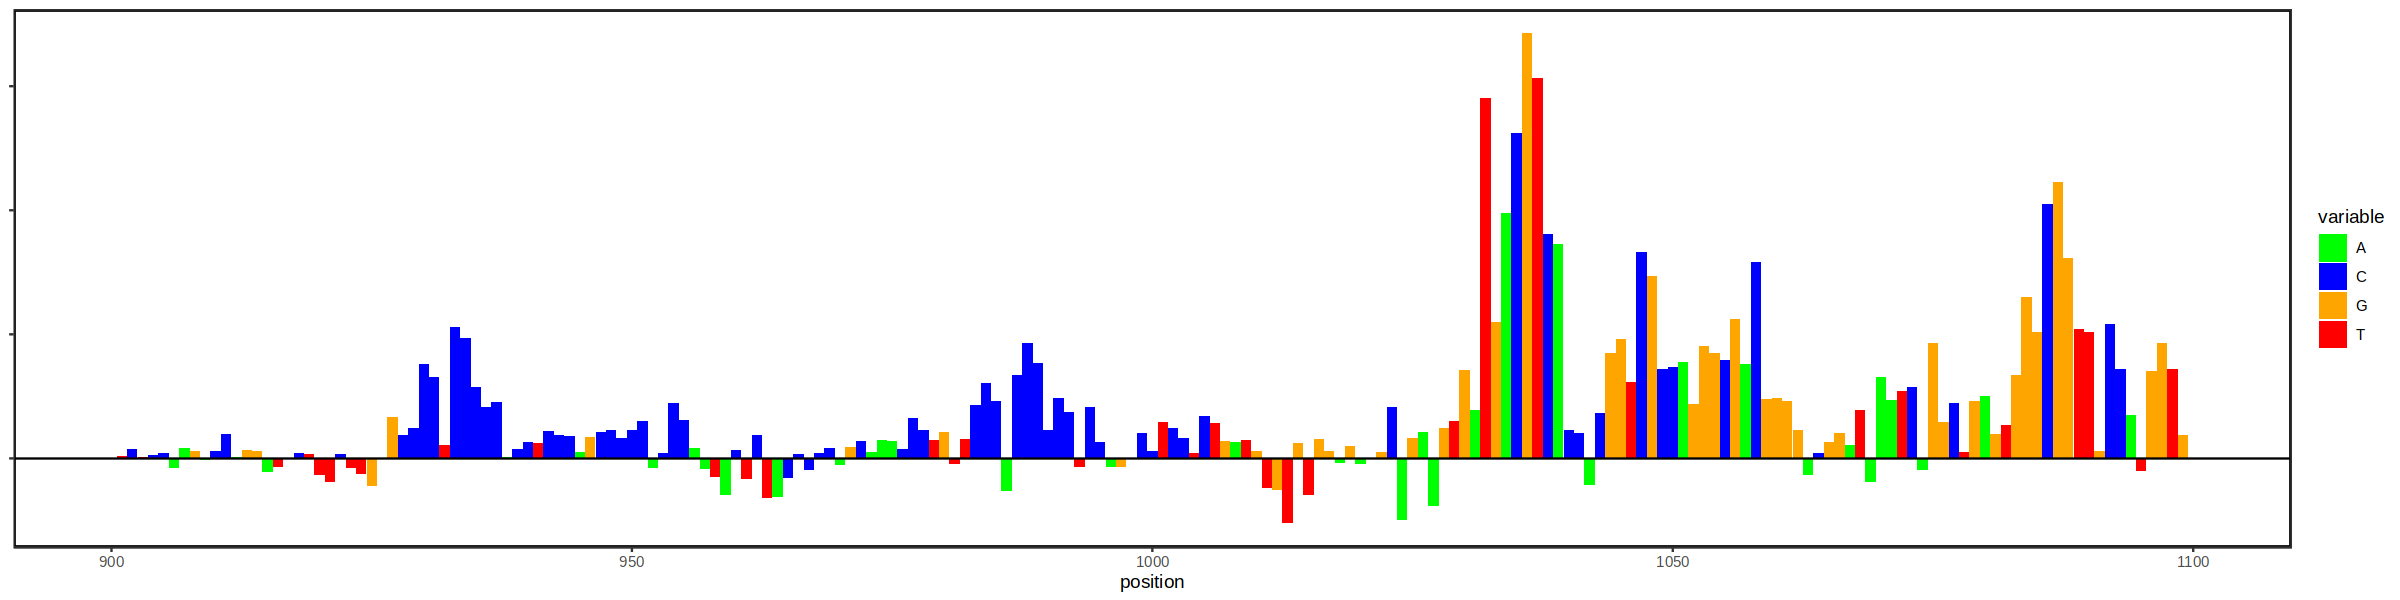

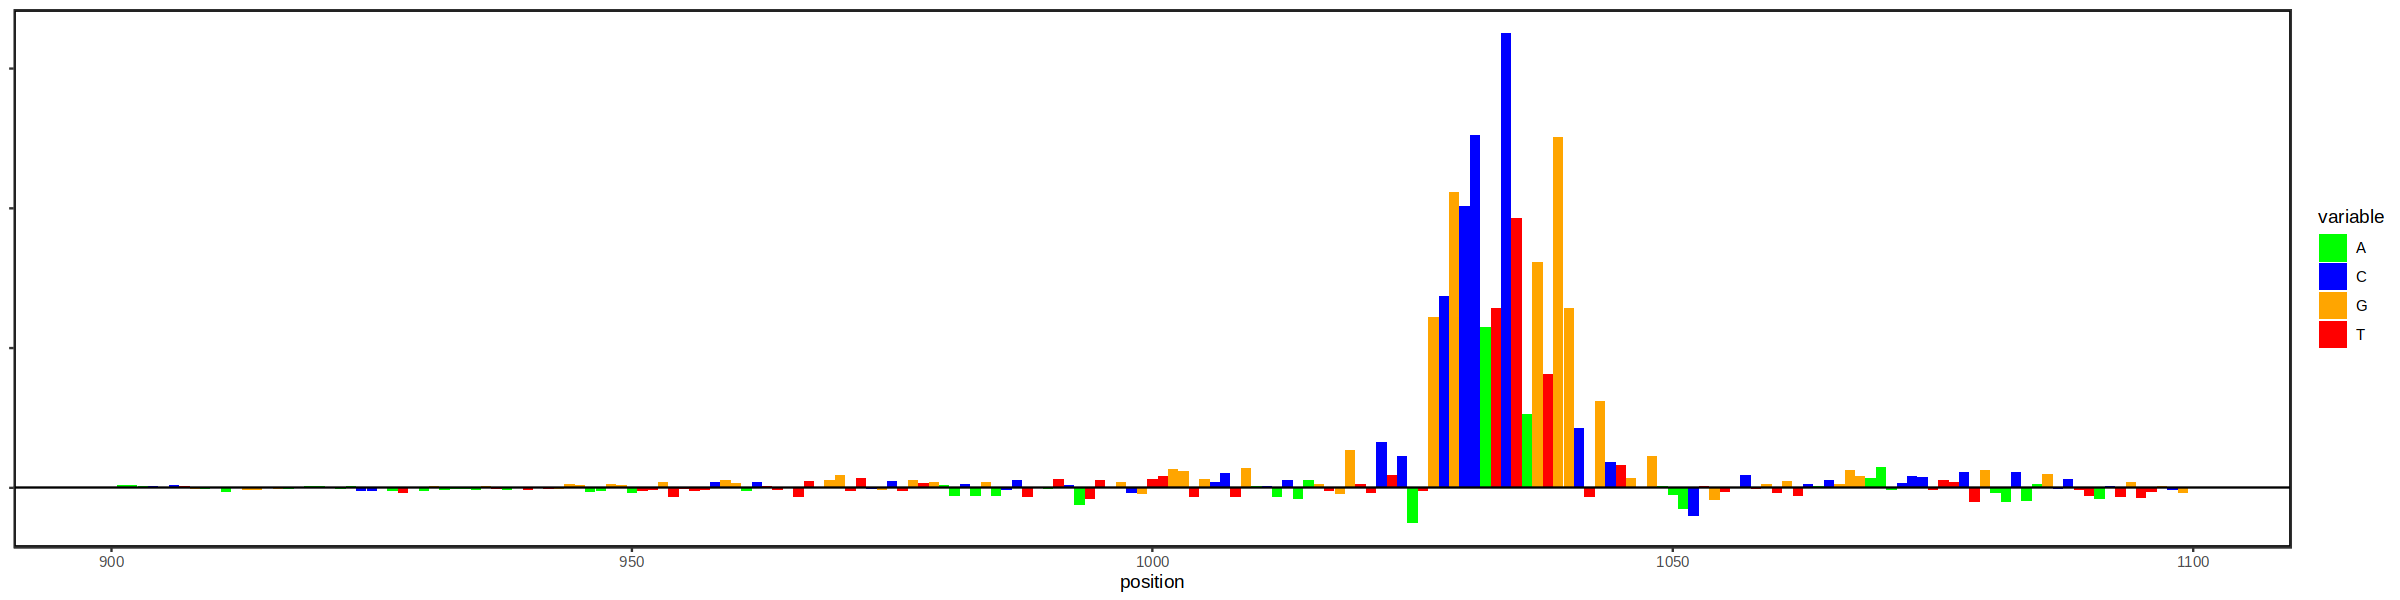

In [121]:
lapply(2000:2010, function(x){
row = boom[x,]$row

    test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]

    
genome = data.table(A = test[1:2114],
           C = test[2115:4228],
           G =  test[4229:6342],
           T =  test[6343:8456]
           ) %>%
    .[, position := .I] %>%
    melt(., id.vars = 'position') %>% 
    .[abs(value) > 0]

options(repr.plot.width = 20, repr.plot.height = 5)
 genome = genome[position > 900 & position < 1100]
ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_blank(),
         axis.title.y = element_blank())
})

In [114]:
boom = mclapply(1:30000, function(x){
    test = mydata[(2114 * (x*4) + 1 ): (2114 * (x * 4) + 2114*4)]
        
    genome = data.table(A = test[1:2114],
               C = test[2115:4228],
               G =  test[4229:6342],
               T =  test[6343:8456]
               )
    tmp = data.table(row = x,
                     max = sum(genome$C))
                     
    return(tmp)
}, mc.cores = 24) %>% rbindlist() %>%
    .[order(-max)]
    
    

In [116]:
boom[4,]$row

[1] 24846

In [118]:
bed <- fread(sprintf("%s/chrombpnet_model/auxiliary/interpret_subsample/chrombpnet_nobias.interpreted_regions.bed", outdir))
bed[boom[4,]$row,]

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
chr4,133092543,133094657,.,.,.,.,.,.,1057


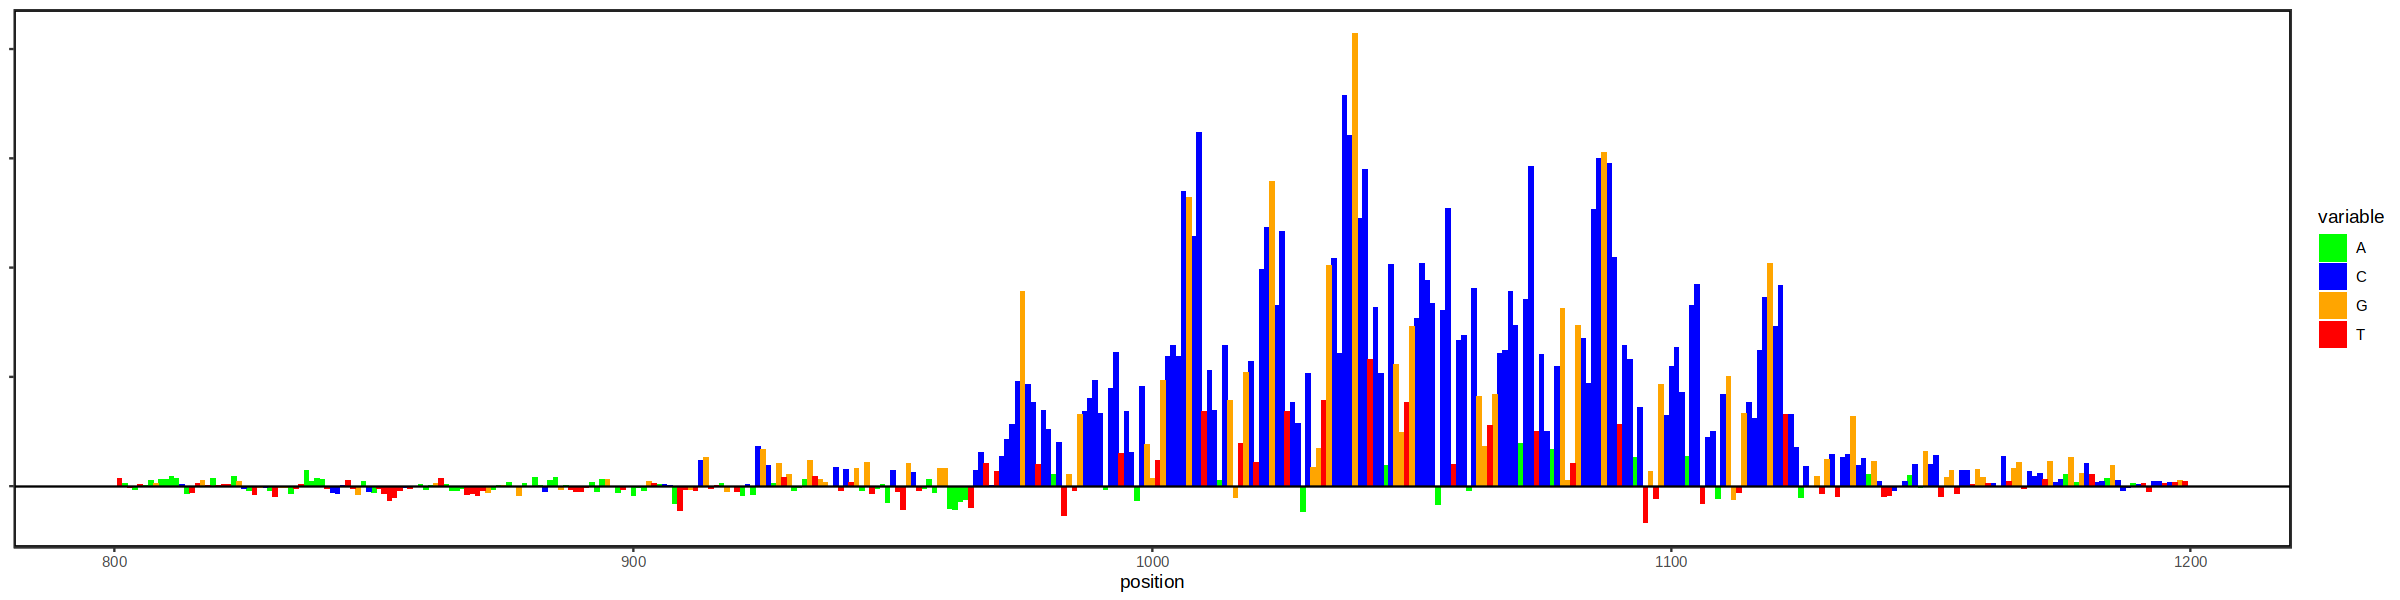

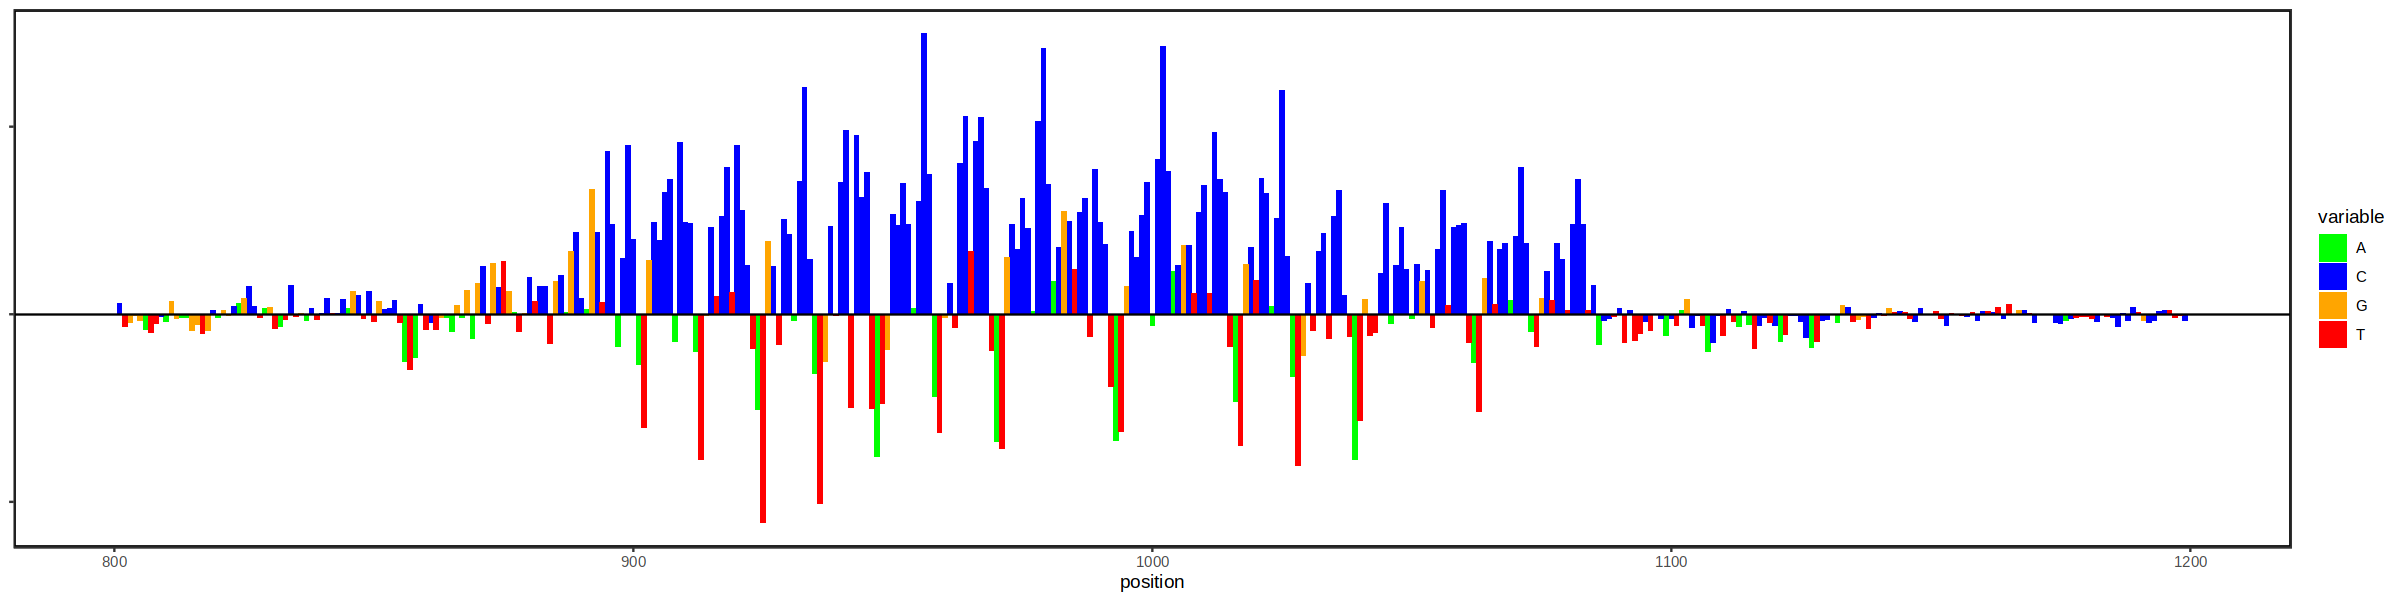

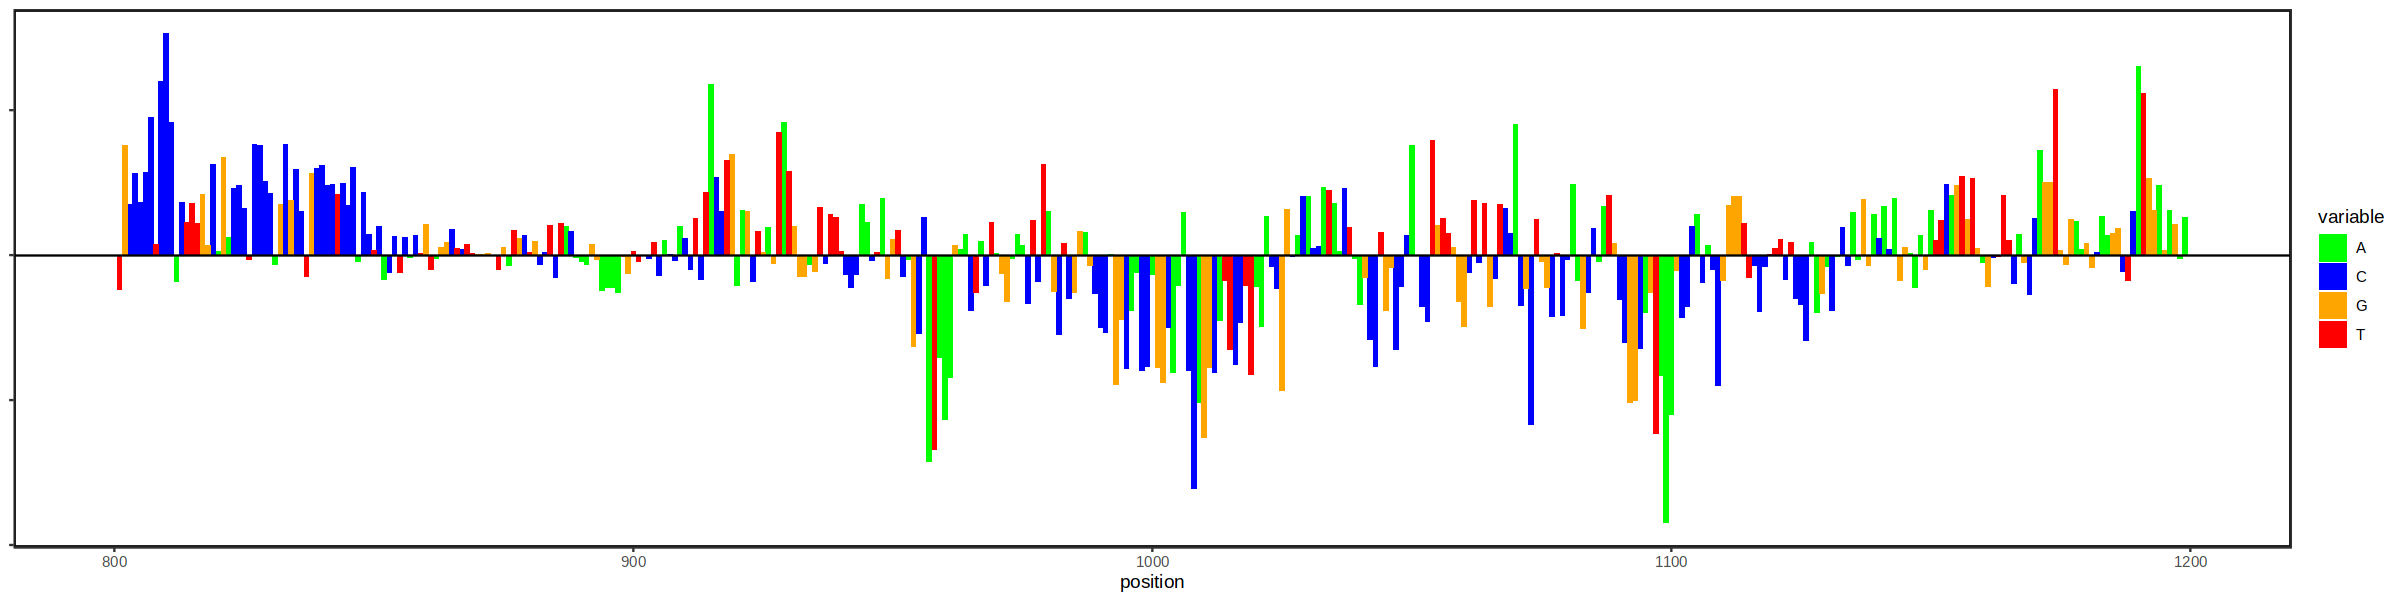

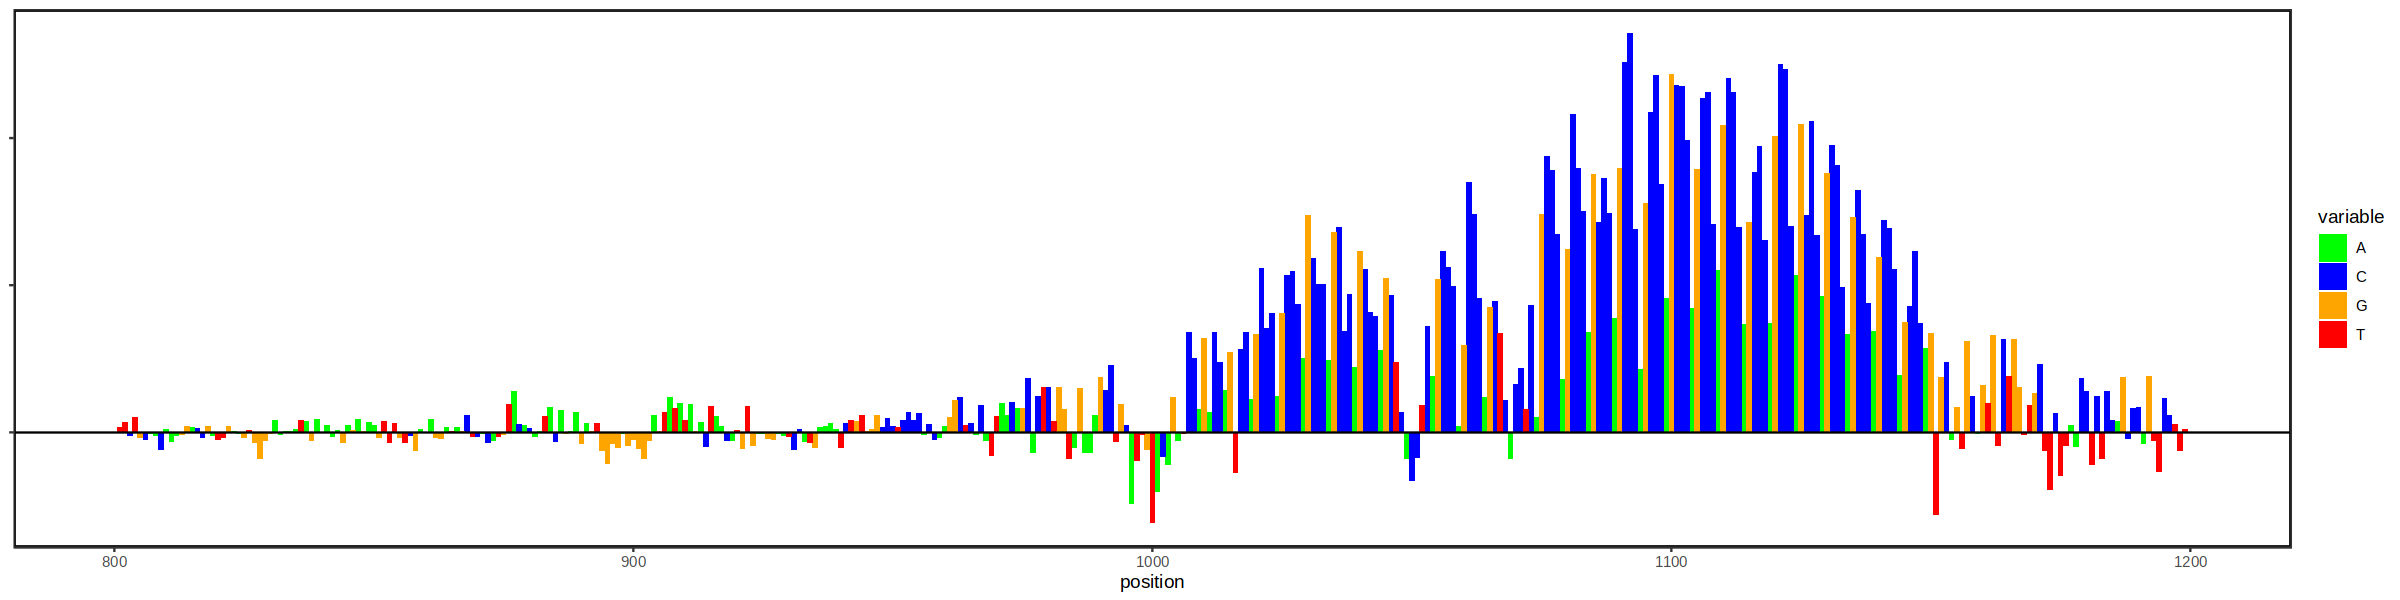

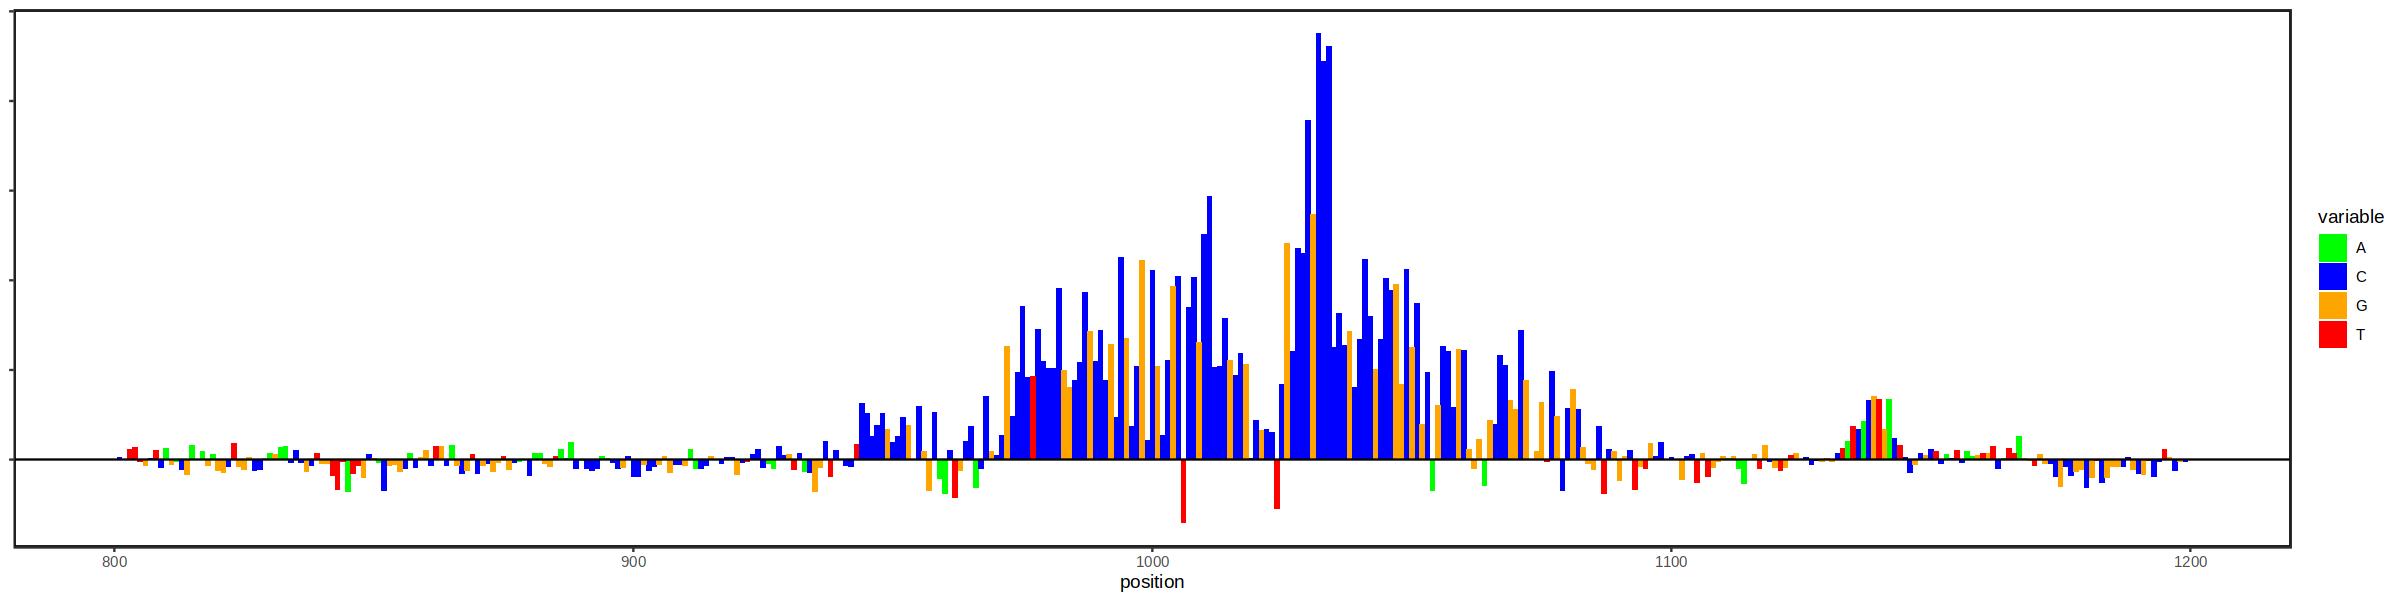

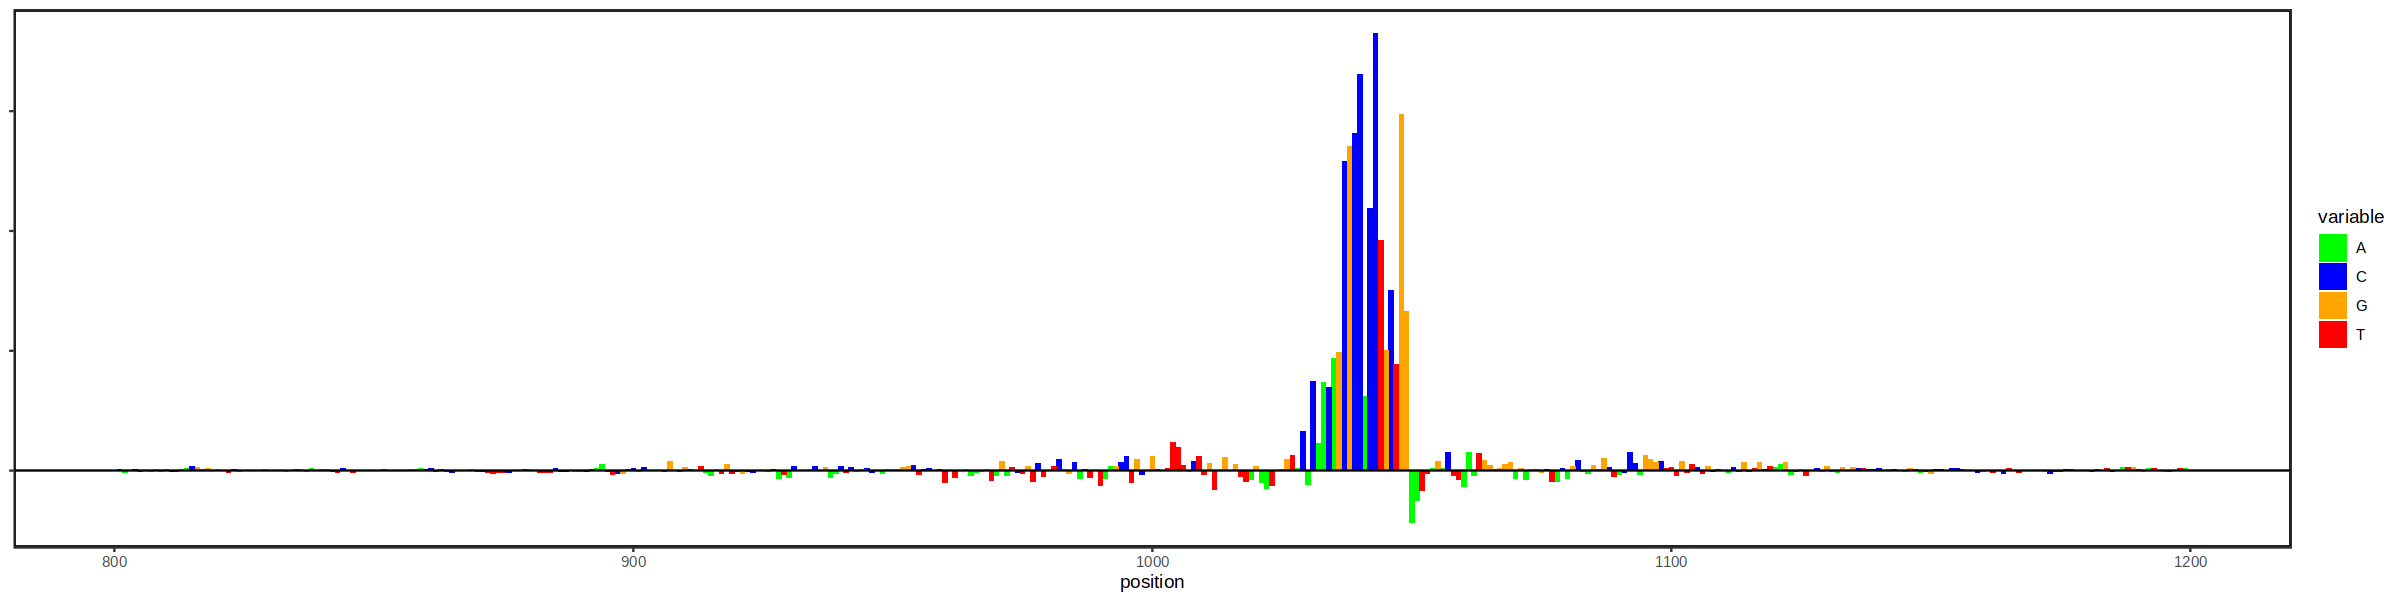

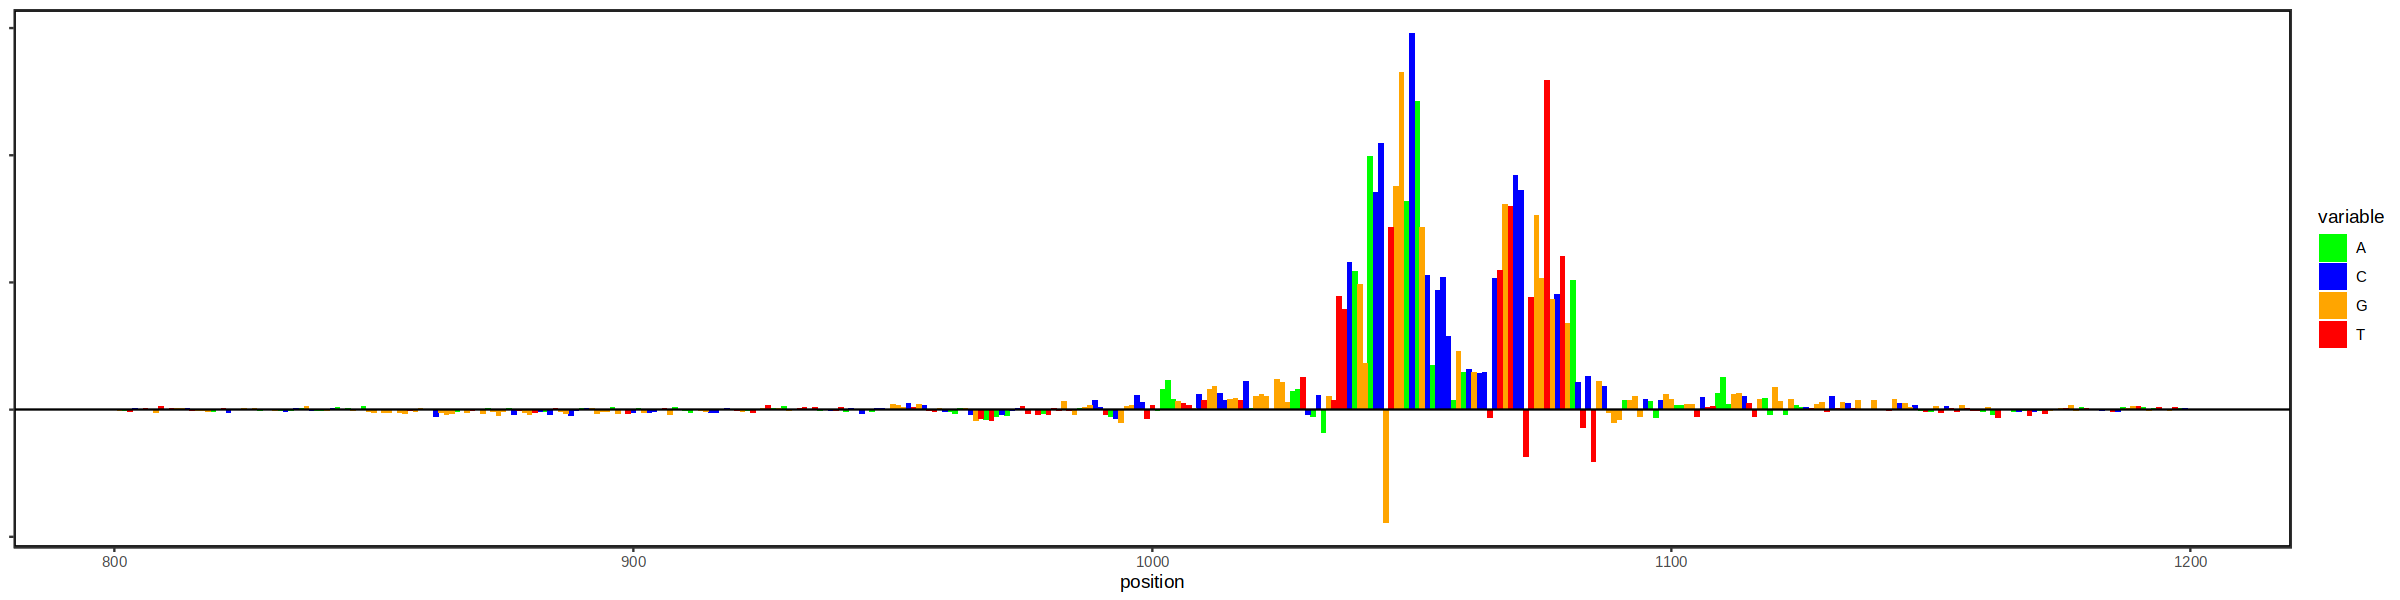

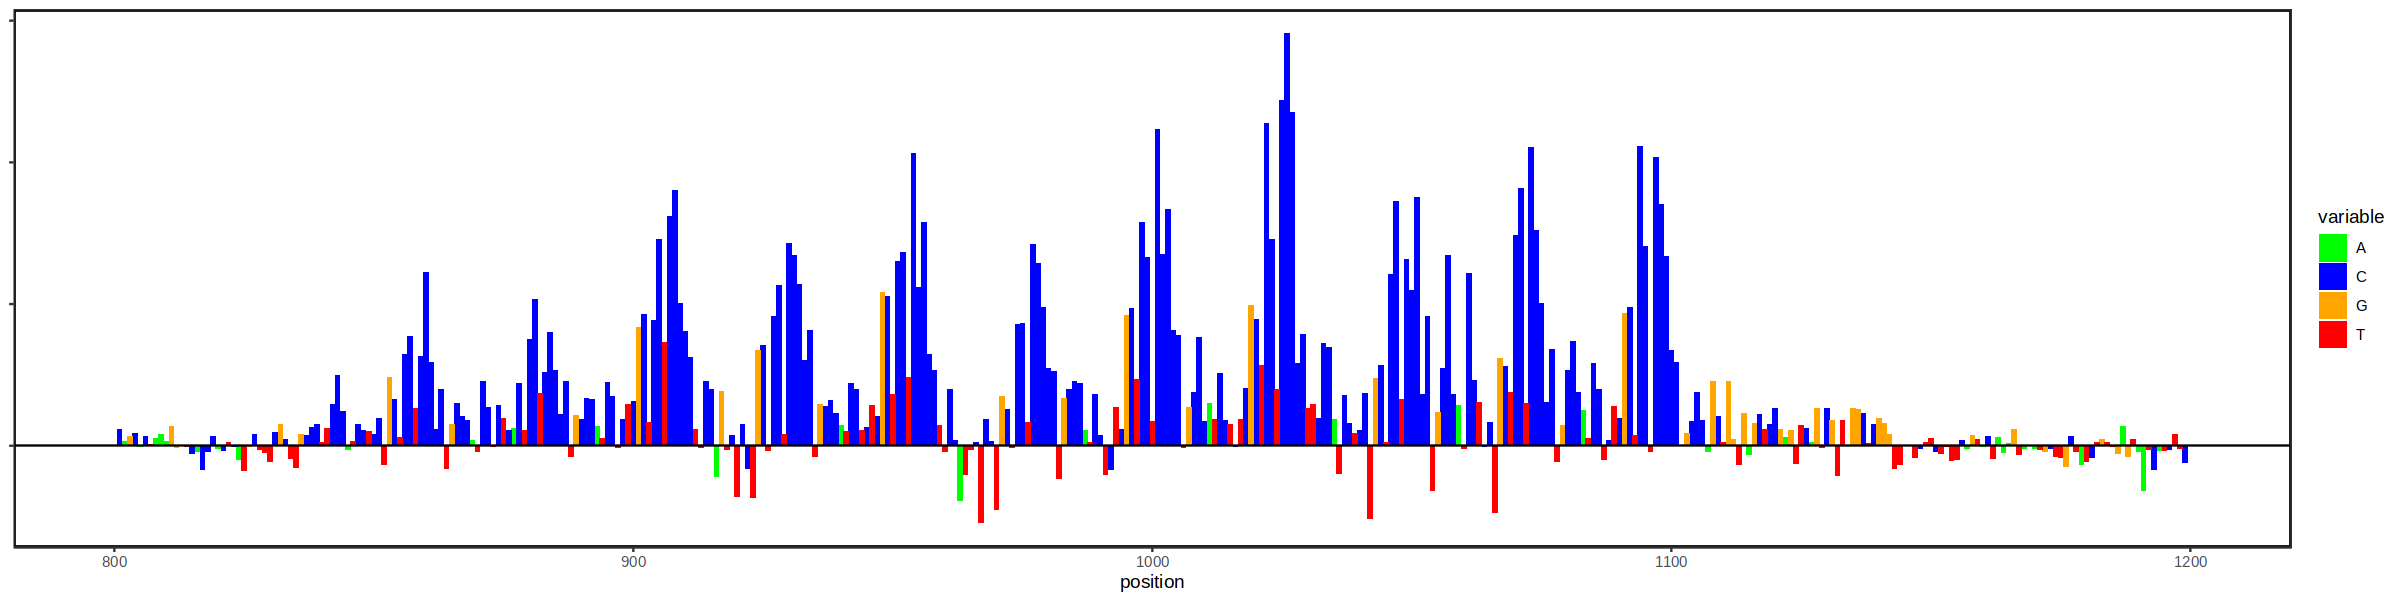

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]


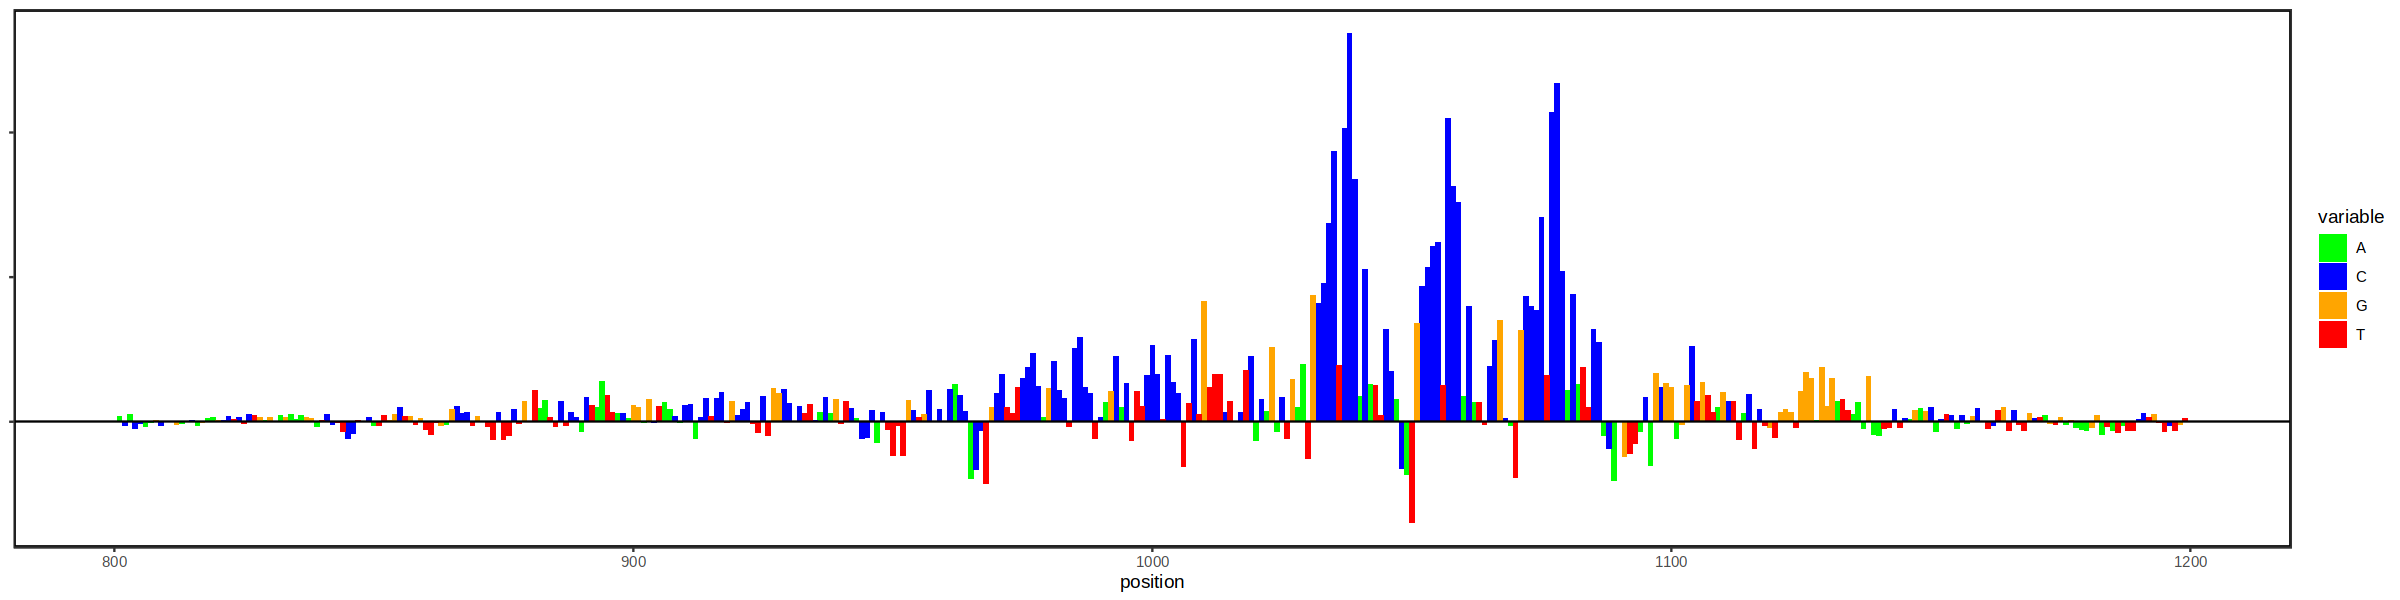

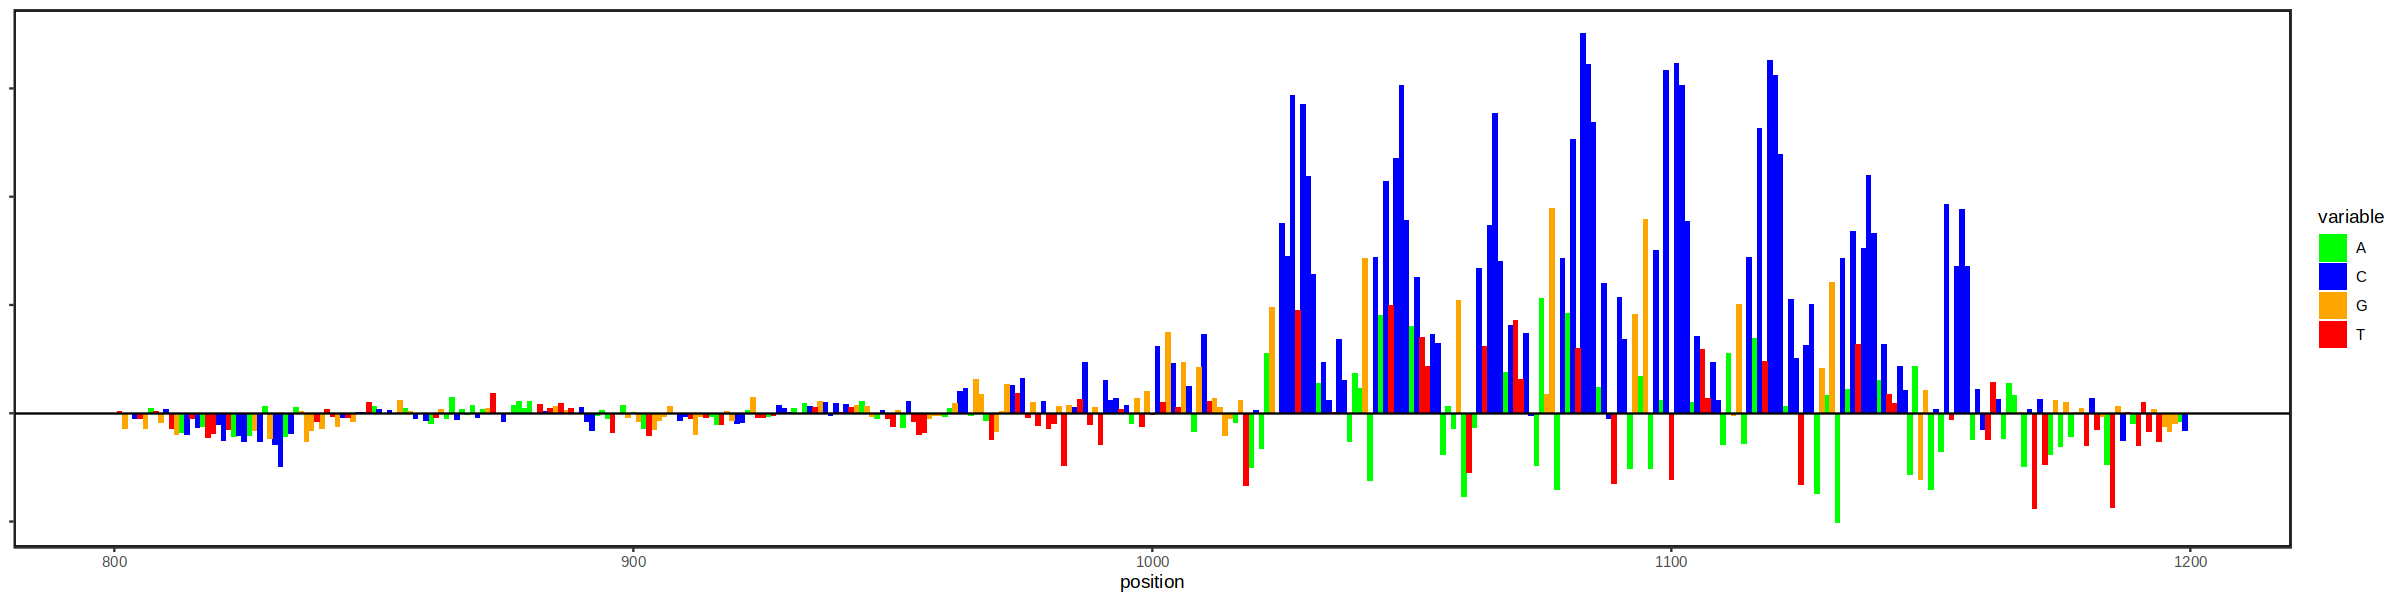

In [ ]:
lapply(1:10, function(x){
row = boom[x,]$row

    test = mydata[(2114 * (row*4) + 1 ): (2114 * (row * 4) + 2114*4)]

    
genome = data.table(A = test[1:2114],
           C = test[2115:4228],
           G =  test[4229:6342],
           T =  test[6343:8456]
           ) %>%
    .[, position := .I] %>%
    melt(., id.vars = 'position') %>% 
    .[abs(value) > 0]

options(repr.plot.width = 20, repr.plot.height = 5)
 genome = genome[position > 800 & position < 1200]
ggplot(genome, aes(position, value)) + 
    geom_bar(stat = 'identity', aes(fill = variable)) + 
    scale_fill_manual(values = c(A = 'green', G = 'orange', T = 'red', C = 'blue')) + 
    geom_hline(yintercept = 0) + 
    theme_bw() + 
    theme(panel.grid = element_blank(), 
          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
          axis.text.y = element_blank(),
         axis.title.y = element_blank())
})

# Systematic for more cell types

In [132]:
unique(meta$celltype.mapped)

[1] NA                               "Caudal_epiblast"               
 [3] "ExE_endoderm"                   "Gut"                           
 [5] "Mesenchyme"                     "Primitive_Streak"              
 [7] "Epiblast"                       "ExE_ectoderm"                  
 [9] "Surface_ectoderm"               "Anterior_Primitive_Streak"     
[11] "Nascent_mesoderm"               "Forebrain_Midbrain_Hindbrain"  
[13] "Rostral_neurectoderm"           "Haematoendothelial_progenitors"
[15] "Somitic_mesoderm"               "Parietal_endoderm"             
[17] "ExE_mesoderm"                   "Intermediate_mesoderm"         
[19] "Def._endoderm"                  "Visceral_endoderm"             
[21] "Notochord"                      "Mixed_mesoderm"                
[23] "Paraxial_mesoderm"              "Blood_progenitors_1"           
[25] "Spinal_cord"                    "Blood_progenitors_2"           
[27] "Pharyngeal_mesoderm"            "PGC"                           
[29] "Caudal_Mesoderm"                "Endothelium"                   
[31] "Caudal_neurectoderm"            "Allantois"                     
[33] "Neural_crest"                   "NMP"                           
[35] "Cardiomyocytes"                 "Erythroid1"                    
[37] "Erythroid2"                     "Erythroid3"

In [143]:
unique(meta$sample)[!unique(meta$sample) %in% c('E8.5_CRISPR_T_KO','E8.5_CRISPR_T_WT')]

[1] "E7.5_rep1"  "E7.5_rep2"  "E7.75_rep1" "E8.0_rep1"  "E8.0_rep2" 
[6] "E8.5_rep1"  "E8.5_rep2"  "E8.75_rep1" "E8.75_rep2"

In [155]:
x = 'E7.5_rep1'
i = 'Gut'

In [159]:
!file.exists(sprintf('%s/%s_%s.tsv.gz', outdir, i, x))#{print('yes')}

[1] FALSE

In [163]:
table(meta$sample)


 E7.5_rep1  E7.5_rep2 E7.75_rep1  E8.0_rep1  E8.0_rep2  E8.5_rep1  E8.5_rep2 
      8977      13321       5120       7656       6382      11319      11447 
E8.75_rep1 E8.75_rep2 
      4076       5619 

In [168]:
chrs = c('chr1','chr10','chr11','chr12','chr13','chr14','chr15','chr16','chr17','chr18','chr19','chr2','chr3','chr4','chr5','chr6','chr7','chr8','chr9')
# exclude samples
samples_incl = unique(meta$sample)[!unique(meta$sample) %in% c('E8.5_CRISPR_T_KO','E8.5_CRISPR_T_WT')]
meta = meta[sample %in% samples_incl]

# Accidentally doing it for all cell types --> run ChromBPNet only on those of interest
celltypes = c(
'Gut','Mesenchyme','Primitive_Streak','Nascent_mesoderm',
'Forebrain_Midbrain_Hindbrain','Somitic_mesoderm','Spinal_cord',
'Endothelium','Allantois','Cardiomyocytes','Erythroid1'
)


# Export fragments of celltype cells in subset of samples
mclapply(samples_incl, function(x){
    # List cells per sample
    message(x)
    # filter right samples
    tmp_meta = meta[sample == x]  
    # Keep relevant cell types
    celltypes = tmp_meta %>%
        .[, .N, by = 'celltype.mapped'] %>% 
        unique(by = 'celltype.mapped') %>%
        .[N > 20] %>% 
        .$celltype.mapped
    
    # Load fragment file
    file = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/original/%s/atac_fragments.tsv.gz', x)
    fragment = suppressWarnings(fread(file,
                                        tmpdir = '/rds/project/rds-SDzz0CATGms/users/bt392/software/tmp'))
    message('before filtering:')
    message(nrow(fragment))
    
    mclapply(celltypes, function(i){
        message(i)
        # Only run if file doesn't exist yet
        if(!file.exists(sprintf('%s/%s_%s.tsv.gz', outdir, i, x))){
            # determine cells
            tmp_cell = tmp_meta[celltype.mapped == i, rn] %>% 
                str_split('#') %>%  # get cell names without sample in front of it
                map_chr(2) 
            
            # Filter right cells & chrs from fragment file
            fragment = fragment %>% 
                setnames(c('chr', 'start', 'end', 'cell', 'reads')) %>%
                # .[chr == 'chr1'] %>%
                .[cell %in% tmp_cell] %>% 
                .[chr %in% chrs]

            message('after filtering:')
            message(nrow(fragment))

            fwrite(fragment, sprintf('%s/%s_%s.tsv.gz', outdir, i, x), sep = '\t')
        }
    }, mc.cores = 1)
}, mc.cores = 1)

E7.5_rep1

before filtering:

273572070

NA

after filtering:

0

Caudal_epiblast

after filtering:

11104841

ExE_endoderm

after filtering:

36125822

Gut

Mesenchyme

Primitive_Streak

after filtering:

5892066

Epiblast

after filtering:

16453436

ExE_ectoderm

after filtering:

25435630

Surface_ectoderm

after filtering:

6775760

Anterior_Primitive_Streak

after filtering:

1948642

Nascent_mesoderm

after filtering:

16476715

Forebrain_Midbrain_Hindbrain

after filtering:

694829

Rostral_neurectoderm

after filtering:

22153453

Haematoendothelial_progenitors

after filtering:

4760786

Somitic_mesoderm

after filtering:

5681887

Parietal_endoderm

after filtering:

3131447

ExE_mesoderm

after filtering:

1106708

Intermediate_mesoderm

after filtering:

2592438

Def._endoderm

after filtering:

4520390

Visceral_endoderm

after filtering:

3782255

Notochord

after filtering:

1387013

Mixed_mesoderm

after filtering:

3489663

Paraxial_mesoderm

after filtering:

2916563

[[1]]
[[1]][[1]]
NULL

[[1]][[2]]
NULL

[[1]][[3]]
NULL

[[1]][[4]]
NULL

[[1]][[5]]
NULL

[[1]][[6]]
NULL

[[1]][[7]]
NULL

[[1]][[8]]
NULL

[[1]][[9]]
NULL

[[1]][[10]]
NULL

[[1]][[11]]
NULL

[[1]][[12]]
NULL

[[1]][[13]]
NULL

[[1]][[14]]
NULL

[[1]][[15]]
NULL

[[1]][[16]]
NULL

[[1]][[17]]
NULL

[[1]][[18]]
NULL

[[1]][[19]]
NULL

[[1]][[20]]
NULL

[[1]][[21]]
NULL

[[1]][[22]]
NULL

[[1]][[23]]
NULL

[[1]][[24]]
NULL

[[1]][[25]]
NULL

[[1]][[26]]
NULL


[[2]]
[[2]][[1]]
NULL

[[2]][[2]]
NULL

[[2]][[3]]
NULL

[[2]][[4]]
NULL

[[2]][[5]]
NULL

[[2]][[6]]
NULL

[[2]][[7]]
NULL

[[2]][[8]]
NULL

[[2]][[9]]
NULL

[[2]][[10]]
NULL

[[2]][[11]]
NULL

[[2]][[12]]
NULL

[[2]][[13]]
NULL

[[2]][[14]]
NULL

[[2]][[15]]
NULL

[[2]][[16]]
NULL

[[2]][[17]]
NULL

[[2]][[18]]
NULL

[[2]][[19]]
NULL

[[2]][[20]]
NULL

[[2]][[21]]
NULL

[[2]][[22]]
NULL

[[2]][[23]]
NULL

[[2]][[24]]
NULL

[[2]][[25]]
NULL

[[2]][[26]]
NULL


[[3]]
[[3]][[1]]
NULL

[[3]][[2]]
NULL

[[3]][[3]]
NULL

[[3]][[4]]
NULL

[[3]][[5]]
NULL

[[3]][[6]]
NULL

[[3]][[7]]
NULL

[[3]][[8]]
NULL

[[3]][[9]]
NULL

[[3]][[10]]
NULL

[[3]][[11]]
NULL

[[3]][[12]]
NULL


[[4]]
[[4]][[1]]
NULL

[[4]][[2]]
NULL

[[4]][[3]]
NULL

[[4]][[4]]
NULL

[[4]][[5]]
NULL

[[4]][[6]]
NULL

[[4]][[7]]
NULL

[[4]][[8]]
NULL

[[4]][[9]]
NULL

[[4]][[10]]
NULL

[[4]][[11]]
NULL

[[4]][[12]]
NULL

[[4]][[13]]
NULL

[[4]][[14]]
NULL

[[4]][[15]]
NULL

[[4]][[16]]
NULL

[[4]][[17]]
NULL

[[4]][[18]]
NULL

[[4]][[19]]
NULL

[[4]][[20]]
NULL

[[4]][[21]]
NULL

[[4]][[22]]
NULL

[[4]][[23]]
NULL

[[4]][[24]]
NULL

[[4]][[25]]
NULL

[[4]][[26]]
NULL

[[4]][[27]]
NULL


[[5]]
[[5]][[1]]
NULL

[[5]][[2]]
NULL

[[5]][[3]]
NULL

[[5]][[4]]
NULL

[[5]][[5]]
NULL

[[5]][[6]]
NULL

[[5]][[7]]
NULL

[[5]][[8]]
NULL

[[5]][[9]]
NULL

[[5]][[10]]
NULL

[[5]][[11]]
NULL

[[5]][[12]]
NULL

[[5]][[13]]
NULL

[[5]][[14]]
NULL

[[5]][[15]]
NULL

[[5]][[16]]
NULL

[[5]][[17]]
NULL

[[5]][[18]]
NULL

[[5]][[19]]
NULL

[[5]][[20]]
NULL

[[5]][[21]]
NULL

[[5]][[22]]
NULL

[[5]][[23]]
NULL

[[5]][[24]]
NULL

[[5]][[25]]
NULL

[[5]][[26]]
NULL


[[6]]
[[6]][[1]]
NULL

[[6]][[2]]
NULL

[[6]][[3]]
NULL

[[6]][[4]]
NULL

[[6]][[5]]
NULL

[[6]][[6]]
NULL

[[6]][[7]]
NULL

[[6]][[8]]
NULL

[[6]][[9]]
NULL

[[6]][[10]]
NULL

[[6]][[11]]
NULL

[[6]][[12]]
NULL

[[6]][[13]]
NULL

[[6]][[14]]
NULL

[[6]][[15]]
NULL

[[6]][[16]]
NULL

[[6]][[17]]
NULL

[[6]][[18]]
NULL

[[6]][[19]]
NULL

[[6]][[20]]
NULL

[[6]][[21]]
NULL

[[6]][[22]]
NULL

[[6]][[23]]
NULL

[[6]][[24]]
NULL

[[6]][[25]]
NULL

[[6]][[26]]
NULL


[[7]]
[[7]][[1]]
NULL

[[7]][[2]]
NULL

[[7]][[3]]
NULL

[[7]][[4]]
NULL

[[7]][[5]]
NULL

[[7]][[6]]
NULL

[[7]][[7]]
NULL

[[7]][[8]]
NULL

[[7]][[9]]
NULL

[[7]][[10]]
NULL

[[7]][[11]]
NULL

[[7]][[12]]
NULL

[[7]][[13]]
NULL

[[7]][[14]]
NULL

[[7]][[15]]
NULL

[[7]][[16]]
NULL

[[7]][[17]]
NULL

[[7]][[18]]
NULL

[[7]][[19]]
NULL

[[7]][[20]]
NULL

[[7]][[21]]
NULL

[[7]][[22]]
NULL

[[7]][[23]]
NULL

[[7]][[24]]
NULL

[[7]][[25]]
NULL

[[7]][[26]]
NULL

[[7]][[27]]
NULL


[[8]]
[[8]][[1]]
NULL

[[8]][[2]]
NULL

[[8]][[3]]
NULL

[[8]][[4]]
NULL

[[8]][[5]]
NULL

[[8]][[6]]
NULL

[[8]][[7]]
NULL

[[8]][[8]]
NULL

[[8]][[9]]
NULL

[[8]][[10]]
NULL

[[8]][[11]]
NULL

[[8]][[12]]
NULL

[[8]][[13]]
NULL

[[8]][[14]]
NULL

[[8]][[15]]
NULL

[[8]][[16]]
NULL

[[8]][[17]]
NULL

[[8]][[18]]
NULL

[[8]][[19]]
NULL

[[8]][[20]]
NULL


[[9]]
[[9]][[1]]
NULL

[[9]][[2]]
NULL

[[9]][[3]]
NULL

[[9]][[4]]
NULL

[[9]][[5]]
NULL

[[9]][[6]]
NULL

[[9]][[7]]
NULL

[[9]][[8]]
NULL

[[9]][[9]]
NULL

[[9]][[10]]
NULL

[[9]][[11]]
NULL

[[9]][[12]]
NULL

[[9]][[13]]
NULL

[[9]][[14]]
NULL

[[9]][[15]]
NULL

[[9]][[16]]
NULL

[[9]][[17]]
NULL

[[9]][[18]]
NULL

[[9]][[19]]
NULL

[[9]][[20]]
NULL

[[9]][[21]]
NULL

In [8]:
celltypes = c(
    'Gut','Mesenchyme','Primitive_Streak','Nascent_mesoderm',
    'Forebrain_Midbrain_Hindbrain','Somitic_mesoderm','Spinal_cord',
    'Endothelium','Allantois','Cardiomyocytes','Erythroid1'
    )

# Primitive Streak accidentally also includes the anterior primitive streak!!!!
# bad code bad! should not just grep but check that the full string is at the start of the file name
# rather than just the string being present in the file name


lapply(celltypes, function(i){    
    message(i)
    
    # List files per cell type
    files = list.files(outdir, pattern = i)
    # overwrite combined fragment file if it exists
    if(length(grep('fragment', files))>0){
        files = files[-grep('fragment', files)] 
    }
    message(files)
    # Load in the separate fragment files per cell type
    tmp = mclapply(files, function(x){
        tmp_frag = fread(sprintf('%s/%s', outdir, x), sep = '\t',
                                        tmpdir = '/rds/project/rds-SDzz0CATGms/users/bt392/software/tmp')
        return(tmp_frag)
    }, mc.cores = 8) %>% rbindlist() %>% 
    .[order(chr, start)] %>% 
    .[,reads := 1]

    fwrite(tmp, sprintf('%s/%s_fragments.tsv.gz', outdir, i), col.names = F, sep = '\t')
})

Gut

Gut_E7.5_rep1.tsv.gzGut_E7.5_rep2.tsv.gzGut_E8.0_rep1.tsv.gzGut_E8.0_rep2.tsv.gzGut_E8.5_rep1.tsv.gzGut_E8.5_rep2.tsv.gzGut_E8.75_rep1.tsv.gzGut_E8.75_rep2.tsv.gz

Mesenchyme

Mesenchyme_E7.5_rep1.tsv.gzMesenchyme_E7.5_rep2.tsv.gzMesenchyme_E8.0_rep1.tsv.gzMesenchyme_E8.0_rep2.tsv.gzMesenchyme_E8.5_rep1.tsv.gzMesenchyme_E8.5_rep2.tsv.gzMesenchyme_E8.75_rep1.tsv.gzMesenchyme_E8.75_rep2.tsv.gz

Primitive_Streak

Anterior_Primitive_Streak_E7.5_rep1.tsv.gzAnterior_Primitive_Streak_E7.5_rep2.tsv.gzAnterior_Primitive_Streak_E7.75_rep1.tsv.gzPrimitive_Streak_E7.5_rep1.tsv.gzPrimitive_Streak_E7.5_rep2.tsv.gzPrimitive_Streak_E7.75_rep1.tsv.gz

Nascent_mesoderm

Nascent_mesoderm_E7.5_rep1.tsv.gzNascent_mesoderm_E7.5_rep2.tsv.gzNascent_mesoderm_E7.75_rep1.tsv.gz

Forebrain_Midbrain_Hindbrain

Forebrain_Midbrain_Hindbrain_E7.5_rep1.tsv.gzForebrain_Midbrain_Hindbrain_E7.5_rep2.tsv.gzForebrain_Midbrain_Hindbrain_E8.0_rep1.tsv.gzForebrain_Midbrain_Hindbrain_E8.0_rep2.tsv.gzForebrain_Midbrain_Hin

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

[[5]]
NULL

[[6]]
NULL

[[7]]
NULL

[[8]]
NULL

[[9]]
NULL

[[10]]
NULL

[[11]]
NULL

In [11]:
peaks = as.data.table(ArchRProject@peakSet) %>%
    .[, middle := start + (end - start) / 2] %>%
    .[,`:=`(start = middle - 1057, 
            end = middle + 1057,
            column4 = '.',
            column5 = '.',
            column6 = '.',
            column7 = '.',
            column8 = '.',
            column9 = '.',
            column10 = 1057)] %>% 
    .[,.(seqnames, 
         start, 
         end, 
         column4,
         column5,
         column6,
         column7,
         column8,
         column9,
         column10)] %>%
    .[seqnames != 'chrX']

nrow(peaks)
head(peaks)

[1] 188963

seqnames,start,end,column4,column5,column6,column7,column8,column9,column10
<fct>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
chr1,3034845,3036959,.,.,.,.,.,.,1057
chr1,3061896,3064010,.,.,.,.,.,.,1057
chr1,3071556,3073670,.,.,.,.,.,.,1057
chr1,3190739,3192853,.,.,.,.,.,.,1057
chr1,3339818,3341932,.,.,.,.,.,.,1057
chr1,3443186,3445300,.,.,.,.,.,.,1057


In [12]:
peaks.gr = GenomicRanges::makeGRangesFromDataFrame(peaks, keep.extra.columns = T)
overlaps = GenomicRanges::findOverlaps(peaks.gr, ArchRProject@genomeAnnotation$blacklist)

peaks.gr = peaks.gr[-queryHits(overlaps)]

In [13]:
peaks = as.data.table(peaks.gr)[,`:=`(width=NULL, strand=NULL)]
fwrite(peaks, sprintf('%s/all_peaks.bed', outdir), col.names = F, sep = '\t')

In [14]:
nrow(peaks)
tail(peaks)

[1] 188614

seqnames,start,end,column4,column5,column6,column7,column8,column9,column10
<fct>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
chr19,61268299,61270413,.,.,.,.,.,.,1057
chr19,61284163,61286277,.,.,.,.,.,.,1057
chr19,61312470,61314584,.,.,.,.,.,.,1057
chr19,61313575,61315689,.,.,.,.,.,.,1057
chr19,61314638,61316752,.,.,.,.,.,.,1057
chr19,61319988,61322102,.,.,.,.,.,.,1057


In [15]:
chromSizes = as.data.table(ArchRProject@genomeAnnotation$chromSizes) %>%
    .[,.(seqnames, end)]
fwrite(chromSizes, sprintf('%s/mm10.chrom.sizes', outdir), col.names = F, sep = '\t')

In [16]:
fwrite(as.data.table(ArchRProject@genomeAnnotation$blacklist) %>%
           .[,.(seqnames, start, end)],
       sprintf('%s/blacklist.bed.gz', outdir), col.names = F, sep = '\t')

In [1]:
# Run the output of the following code from the CLI in the right folder with the conda chrombpnet2 environment active
celltypes = c(
    'Gut','Mesenchyme','Primitive_Streak','Nascent_mesoderm',
    'Forebrain_Midbrain_Hindbrain','Somitic_mesoderm','Spinal_cord',
    'Endothelium','Allantois','Cardiomyocytes','Erythroid1'
    )


writeLines(paste0(
sapply(celltypes, function(celltype){
    print(sprintf('sbatch run_chrombpnet_args.sh %s', 
                   celltype))
})),
           "test.sh")

[1] "sbatch run_chrombpnet_args.sh Gut"
[1] "sbatch run_chrombpnet_args.sh Mesenchyme"
[1] "sbatch run_chrombpnet_args.sh Primitive_Streak"
[1] "sbatch run_chrombpnet_args.sh Nascent_mesoderm"
[1] "sbatch run_chrombpnet_args.sh Forebrain_Midbrain_Hindbrain"
[1] "sbatch run_chrombpnet_args.sh Somitic_mesoderm"
[1] "sbatch run_chrombpnet_args.sh Spinal_cord"
[1] "sbatch run_chrombpnet_args.sh Endothelium"
[1] "sbatch run_chrombpnet_args.sh Allantois"
[1] "sbatch run_chrombpnet_args.sh Cardiomyocytes"
[1] "sbatch run_chrombpnet_args.sh Erythroid1"


In [32]:
system("$(conda shell.bash hook)")
system("conda activate chrombpnet2")
system("bash get_background_peaks_args.sh > all_background_peak_calling.txt")

Warning message in system("bash get_background_peaks_args.sh > all_background_peak_calling.txt"):
“error in running command”


In [23]:
# Get all other files for whole dataset first, i.e. peaks & non-peaks

# then run chrombpnet again on endothelium and allantois using ALL peaks rather than cell type specific
celltypes = c("Allantois", "Endothelium")
mclapply(celltypes, function(celltype){
    system(sprintf('
        eval "$(conda shell.bash hook)"
        conda activate chrombpnet2
        sbatch run_chrombpnet_args.sh %s', 
                   celltype))
},mc.cores = 2)
# test performance
# If performance did not change -->
    # run other cell types of interest with whole peak set
# If performance got worse -->
    # run other cell types with peaks only of their cell type
    # This would require some coding to send command line commands for starting jobs using Chrombpnet conda environment
    # As well as passing CLI arguments to change the cell type every time.
    # Plus a loop to see if the non-peak detection finished before sending starting chrombpnet
    # again starting with CLI indicating which cell type to test

[[1]]
[1] 0

[[2]]
[1] 0